# Projektarbeit Data Analytics "Candidate Journey Analytics"
Jana Apelt, Juli 2026

## 0. Setup

In [1]:
# 0. SETUP Candidate Journey Analytics
# ==========================================================

# ----------------------------------------------------------
# 0.1 Bibliotheken importieren
# ----------------------------------------------------------

# Datenverarbeitung
import pandas as pd
import numpy as np

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Statistik
import scipy.stats as stats
import statsmodels.api as sm
import pingouin as pg

# Datumsfunktionen
from datetime import datetime, timedelta

# Arbeiten mit Ordnern und Dateipfaden
from pathlib import Path


# ----------------------------------------------------------
# 0.2 Pandas-Darstellung konfigurieren
# ----------------------------------------------------------

# Alle Spalten anzeigen
pd.set_option("display.max_columns", None)

# Mehr Zeilen anzeigen
pd.set_option("display.max_rows", 100)

# Tabellenbreite automatisch anpassen
pd.set_option("display.width", None)

# Zahlen schöner formatieren
pd.options.display.float_format = "{:.2f}".format


# ----------------------------------------------------------
# 0.3 Visualisierungs-Einstellungen
# ----------------------------------------------------------

# Standardgröße für Matplotlib-Grafiken
plt.rcParams["figure.figsize"] = (10, 6)

# Rasterlinien aktivieren
plt.rcParams["axes.grid"] = True


# ----------------------------------------------------------
# 0.4 Reproduzierbarkeit
# ----------------------------------------------------------

# Sorgt dafür, dass Zufallszahlen bei jedem Lauf
# identisch erzeugt werden.
np.random.seed(42)


# ----------------------------------------------------------
# 0.5 Projektordner definieren
# ----------------------------------------------------------

# Aktuelles Projektverzeichnis
PROJECT_DIR = Path(".")

# Unterordner

DATA_DIR = PROJECT_DIR / "Dateien"
REPORT_DIR = PROJECT_DIR / "Berichte"
GRAPHICS_DIR = PROJECT_DIR / "Grafiken"

# Falls Ordner noch nicht existieren:
REPORT_DIR.mkdir(exist_ok=True)
GRAPHICS_DIR.mkdir(exist_ok=True)


# ----------------------------------------------------------
# 0.6 CSV-Dateien laden
# ----------------------------------------------------------

dim_candidate = pd.read_csv(
    DATA_DIR / "dim_candidate.csv"
)

dim_job = pd.read_csv(
    DATA_DIR / "dim_job.csv"
)

dim_location = pd.read_csv(
    DATA_DIR / "dim_location.csv"
)

dim_date = pd.read_csv(
    DATA_DIR / "dim_date.csv"
)

dim_recruiting_channel = pd.read_csv(
    DATA_DIR / "dim_recruiting_channel.csv"
)

fact_candidate_events = pd.read_csv(
    DATA_DIR / "fact_candidate_events.csv"
)

# ----------------------------------------------------------
# 0.7 Daten erfolgreich geladen?
# ----------------------------------------------------------

print("=== Daten erfolgreich geladen ===")
print()

print("dim_candidate:", dim_candidate.shape)
print("dim_job:", dim_job.shape)
print("dim_location:", dim_location.shape)
print("dim_date:", dim_date.shape)
print("dim_recruiting_channel:", dim_recruiting_channel.shape)
print("fact_candidate_events:", fact_candidate_events.shape)

print()
print("Setup erfolgreich abgeschlossen.")

=== Daten erfolgreich geladen ===

dim_candidate: (6200, 4)
dim_job: (150, 5)
dim_location: (5, 4)
dim_date: (481, 8)
dim_recruiting_channel: (5, 2)
fact_candidate_events: (25294, 9)

Setup erfolgreich abgeschlossen.


## 1. Projektbeschreibung

**Business Case**

Recruiting-Prozesse binden erhebliche personelle und zeitliche Ressourcen. Gleichzeitig führen lange Durchlaufzeiten, unnötige Prozessschritte oder Verzögerungen zwischen einzelnen Phasen häufig dazu, dass Kandidaten den Prozess freiwillig verlassen oder sich gegen eine Zusammenarbeit entscheiden. Dadurch entstehen zusätzliche Aufwände für Recruiter und Fachbereiche, offene Stellen bleiben länger unbesetzt und bereits investierte Prozesskosten erhöhen sich.

**Ziel des Projekts ist es, datenbasiert aufzuzeigen, wie Prozessoptimierungen im Recruiting gleichzeitig die Candidate Experience verbessern, interne Aufwände reduzieren und dadurch zu niedrigeren Recruiting-Kosten führen können.**

Besonderes Augenmerk liegt auf Prozesslaufzeiten und Wartezeiten zwischen einzelnen Recruiting-Schritten. Es wird untersucht, ob bestimmte Standorte, Fachbereiche oder Prozessvarianten signifikant längere Durchlaufzeiten aufweisen und ob diese Verzögerungen mit erhöhten Candidate-Dropout-Raten verbunden sind. Darüber hinaus wird betrachtet, welche Auswirkungen Verzögerungen zwischen Angebotsannahme, Vertragsversand und tatsächlichem Arbeitsbeginn auf den weiteren Prozessverlauf haben.

Das Ziel besteht nicht darin, einzelne Entscheidungen von Kandidaten oder Unternehmen zu bewerten, sondern Muster und Optimierungspotenziale innerhalb des Recruiting-Prozesses sichtbar zu machen. Die gewonnenen Erkenntnisse sollen Unternehmen dabei unterstützen, Recruiting-Prozesse effizienter zu gestalten, Prozesskosten zu reduzieren, Besetzungszeiten zu verkürzen und gleichzeitig die Candidate Experience zu verbessern. Eine höhere Transparenz über kritische Prozessphasen kann dazu beitragen, sowohl die Erfolgsquote von Einstellungen als auch die Zufriedenheit der Kandidaten nachhaltig zu erhöhen.

## 2. Generierung von synthetischen Daten (mit KI ChatGPT)
Annahme: in der Realität erhalten wir "saubere" Daten aus einem Data Warehouse in einem Star-Schema mit Dimensionstabellen und einer Faktentabelle nach der festgelegten Prozesslogik. 


In [2]:
# Datengenerator für Dimensionstabellen und Faktentabelle
# ============================================================


# ------------------------------------------------------------
# 1. Grundeinstellungen
# ------------------------------------------------------------

# Zielzahlen gemäß finaler Businesslogik
n_applications = 7500
n_candidates = 6200
n_jobs = 150

n_reviewed = 7350
n_interview_invited = 1350
n_pre_interview_dropout = 128
n_interview_completed = 1222
n_rejected_by_company = 1050
n_offer_made = 172
n_offer_declined = 52
n_offer_accepted = 120
n_contract_dropout = 10
n_contract_signed = 110

# Ausgabeordner für die CSV-Dateien.
# nutzt Projektordner "Dateien".
output_dir = Path("Dateien")

# mkdir erstellt den Ordner, falls er noch nicht existiert.
# exist_ok=True verhindert eine Fehlermeldung, falls er schon existiert.
output_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 2. Dimension: Candidate
# ------------------------------------------------------------

candidate_ids = [
    f"C{str(i).zfill(5)}"
    for i in range(1, n_candidates + 1)
]

dim_candidate = pd.DataFrame({
    "candidate_id": candidate_ids,

    # np.random.choice zieht zufällige Werte aus einer Liste.
    # p= legt die Wahrscheinlichkeiten fest.
    "candidate_level": np.random.choice(
        ["Junior", "Mid", "Senior"],
        size=n_candidates,
        p=[0.30, 0.45, 0.25]
    ),

    "candidate_segment": np.random.choice(
        ["Active Applicant", "Passive Candidate", "Referral"],
        size=n_candidates,
        p=[0.60, 0.25, 0.15]
    ),

    # Kündigungsfrist als späterer möglicher Einflussfaktor
    "notice_period_days": np.random.choice(
        [0, 14, 30, 60, 90],
        size=n_candidates,
        p=[0.10, 0.15, 0.40, 0.25, 0.10]
    )
})

# ------------------------------------------------------------
# 3. Dimension: Recruiting Channel
# ------------------------------------------------------------

dim_recruiting_channel = pd.DataFrame({
    "channel_id": ["CH01", "CH02", "CH03", "CH04", "CH05"],
    "channel_name": [
        "LinkedIn",
        "Job Board",
        "Referral",
        "Career Page",
        "Recruiting Agency"
    ]
})

# ------------------------------------------------------------
# 4. Dimension: Location
# ------------------------------------------------------------

dim_location = pd.DataFrame({
    "location_id": ["LOC01", "LOC02", "LOC03", "LOC04", "LOC05"],
    "city": ["Hamburg", "Berlin", "München", "Köln", "Frankfurt"],
    "country": ["Germany"] * 5,
    "region": ["North", "East", "South", "West", "Central"]
})

# ------------------------------------------------------------
# 5. Dimension: Job
# ------------------------------------------------------------

job_ids = [
    f"J{str(i).zfill(4)}"
    for i in range(1, n_jobs + 1)
]

dim_job = pd.DataFrame({
    "job_id": job_ids,

    "department": np.random.choice(
        ["Data", "IT", "Operations", "Sales", "Marketing", "Finance", "HR"],
        size=n_jobs,
        p=[0.18, 0.22, 0.20, 0.12, 0.10, 0.10, 0.08]
    ),

    "remote_option": np.random.choice(
        ["Onsite", "Hybrid", "Remote"],
        size=n_jobs,
        p=[0.30, 0.45, 0.25]
    ),

    "location_id": np.random.choice(
        dim_location["location_id"],
        size=n_jobs,
        p=[0.22, 0.22, 0.20, 0.18, 0.18]
    ),

    "seniority_required": np.random.choice(
        ["Junior", "Mid", "Senior"],
        size=n_jobs,
        p=[0.25, 0.50, 0.25]
    )
})

# ------------------------------------------------------------
# 6. Bewerbungstabelle als Hilfstabelle
# ------------------------------------------------------------

applications = pd.DataFrame({
    "application_id": [
        f"A{str(i).zfill(5)}"
        for i in range(1, n_applications + 1)
    ],

    # Kandidaten können mehrfach vorkommen, weil es weniger Kandidaten
    # als Bewerbungen gibt.
    "candidate_id": np.random.choice(
        candidate_ids,
        size=n_applications
    ),

    "job_id": np.random.choice(
        job_ids,
        size=n_applications
    ),

    "channel_id": np.random.choice(
        dim_recruiting_channel["channel_id"],
        size=n_applications,
        p=[0.35, 0.25, 0.15, 0.15, 0.10]
    )
})

# merge entspricht einem Join in SQL.
# Dadurch bekommt jede Bewerbung zusätzliche Kandidaten- und Jobmerkmale.
applications = applications.merge(
    dim_candidate,
    on="candidate_id",
    how="left"
)

applications = applications.merge(
    dim_job[
        [
            "job_id",
            "department",
            "remote_option",
            "location_id",
            "seniority_required"
        ]
    ],
    on="job_id",
    how="left"
)

# ------------------------------------------------------------
# 7. Prozessgruppen exakt zuweisen
# ------------------------------------------------------------

all_apps = applications["application_id"].to_numpy()

reviewed_apps = np.random.choice(
    all_apps,
    size=n_reviewed,
    replace=False
)

interview_invited_apps = np.random.choice(
    reviewed_apps,
    size=n_interview_invited,
    replace=False
)

pre_interview_dropout_apps = np.random.choice(
    interview_invited_apps,
    size=n_pre_interview_dropout,
    replace=False
)

interview_completed_apps = np.setdiff1d(
    interview_invited_apps,
    pre_interview_dropout_apps
)

offer_made_apps = np.random.choice(
    interview_completed_apps,
    size=n_offer_made,
    replace=False
)

rejected_by_company_apps = np.setdiff1d(
    interview_completed_apps,
    offer_made_apps
)

offer_declined_apps = np.random.choice(
    offer_made_apps,
    size=n_offer_declined,
    replace=False
)

offer_accepted_apps = np.setdiff1d(
    offer_made_apps,
    offer_declined_apps
)

contract_dropout_apps = np.random.choice(
    offer_accepted_apps,
    size=n_contract_dropout,
    replace=False
)

contract_signed_apps = np.setdiff1d(
    offer_accepted_apps,
    contract_dropout_apps
)

# ------------------------------------------------------------
# 8. Faktentabelle als Eventlog erzeugen
# ------------------------------------------------------------

event_rows = []
start_date = pd.to_datetime("2025-01-01")

def add_event(application_id, candidate_id, job_id, channel_id,
              step_number, event_type, event_date):
    """
    Fügt ein Event zur Eventliste hinzu.
    Eine Zeile entspricht später einem Ereignis in der Faktentabelle.
    """
    event_rows.append([
        application_id,
        candidate_id,
        job_id,
        channel_id,
        step_number,
        event_type,
        event_date
    ])

for _, row in applications.iterrows():

    application_id = row["application_id"]
    candidate_id = row["candidate_id"]
    job_id = row["job_id"]
    channel_id = row["channel_id"]
    location_id = row["location_id"]
    notice_period = row["notice_period_days"]

    current_date = start_date + timedelta(
        days=int(np.random.randint(0, 365))
    )

    step_number = 1

    # Frankfurt wird bewusst langsamer modelliert,
    # damit wir später Standortunterschiede analysieren können.
    delay_factor = 1.8 if location_id == "LOC05" else 1.0

    def wait_days(min_days, max_days):
        """
        Erzeugt eine zufällige Wartezeit.
        randint(min_days, max_days) liefert Werte von min_days bis max_days - 1.
        Der delay_factor verlängert die Zeiten für Frankfurt.
        """
        return int(np.random.randint(min_days, max_days) * delay_factor)

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Application Received", current_date
    )

    if application_id not in reviewed_apps:
        continue

    current_date += timedelta(days=wait_days(1, 6))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Application Reviewed", current_date
    )

    if application_id not in interview_invited_apps:
        current_date += timedelta(days=wait_days(1, 5))
        step_number += 1

        add_event(
            application_id, candidate_id, job_id, channel_id,
            step_number, "Application Rejected", current_date
        )
        continue

    current_date += timedelta(days=wait_days(2, 10))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Interview Invited", current_date
    )

    if application_id in pre_interview_dropout_apps:
        current_date += timedelta(days=wait_days(1, 5))
        step_number += 1

        add_event(
            application_id, candidate_id, job_id, channel_id,
            step_number, "Candidate Dropout", current_date
        )
        continue

    current_date += timedelta(days=wait_days(3, 14))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Interview Completed", current_date
    )

    if application_id in rejected_by_company_apps:
        current_date += timedelta(days=wait_days(2, 8))
        step_number += 1

        add_event(
            application_id, candidate_id, job_id, channel_id,
            step_number, "Rejected by Company", current_date
        )
        continue

    current_date += timedelta(days=wait_days(2, 10))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Offer Made", current_date
    )

    current_date += timedelta(days=wait_days(1, 7))
    step_number += 1

    if application_id in offer_declined_apps:
        add_event(
            application_id, candidate_id, job_id, channel_id,
            step_number, "Offer Declined", current_date
        )
        continue

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Offer Accepted", current_date
    )

    current_date += timedelta(days=wait_days(3, 14))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Contract Sent", current_date
    )

    if application_id in contract_dropout_apps:
        current_date += timedelta(days=wait_days(1, 6))
        step_number += 1

        add_event(
            application_id, candidate_id, job_id, channel_id,
            step_number, "Contract Dropout", current_date
        )
        continue

    current_date += timedelta(days=wait_days(1, 7))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Contract Signed", current_date
    )

    current_date += timedelta(days=int(notice_period))
    step_number += 1

    add_event(
        application_id, candidate_id, job_id, channel_id,
        step_number, "Employment Started", current_date
    )

# ------------------------------------------------------------
# 9. Faktentabelle finalisieren
# ------------------------------------------------------------

fact_candidate_events = pd.DataFrame(
    event_rows,
    columns=[
        "application_id",
        "candidate_id",
        "job_id",
        "channel_id",
        "event_step_number",
        "event_type",
        "event_date"
    ]
)

fact_candidate_events = fact_candidate_events.sort_values(
    ["application_id", "event_step_number"]
)

fact_candidate_events["previous_event_date"] = (
    fact_candidate_events
    .groupby("application_id")["event_date"]
    .shift(1)
)

fact_candidate_events["waiting_days_since_last_event"] = (
    fact_candidate_events["event_date"]
    - fact_candidate_events["previous_event_date"]
).dt.days

fact_candidate_events["date_id"] = (
    fact_candidate_events["event_date"]
    .dt.strftime("%Y%m%d")
    .astype(int)
)

fact_candidate_events = fact_candidate_events.drop(
    columns=["previous_event_date"]
)

# ------------------------------------------------------------
# 10. Datumsdimension erstellen
# ------------------------------------------------------------

dates = pd.date_range(
    fact_candidate_events["event_date"].min(),
    fact_candidate_events["event_date"].max()
)

dim_date = pd.DataFrame({
    "date_id": dates.strftime("%Y%m%d").astype(int),
    "date": dates,
    "year": dates.year,
    "quarter": dates.quarter,
    "month": dates.month,
    "month_name": dates.month_name(),
    "calendar_week": dates.isocalendar().week.astype(int),
    "weekday": dates.day_name()
})

# ------------------------------------------------------------
# 11. CSV-Dateien speichern
# ------------------------------------------------------------

fact_candidate_events.to_csv(
    output_dir / "fact_candidate_events.csv",
    index=False,
    encoding="utf-8-sig"
)

dim_candidate.to_csv(
    output_dir / "dim_candidate.csv",
    index=False,
    encoding="utf-8-sig"
)

dim_job.to_csv(
    output_dir / "dim_job.csv",
    index=False,
    encoding="utf-8-sig"
)

dim_location.to_csv(
    output_dir / "dim_location.csv",
    index=False,
    encoding="utf-8-sig"
)

dim_recruiting_channel.to_csv(
    output_dir / "dim_recruiting_channel.csv",
    index=False,
    encoding="utf-8-sig"
)

dim_date.to_csv(
    output_dir / "dim_date.csv",
    index=False,
    encoding="utf-8-sig"
)

# ------------------------------------------------------------
# 12. Kontrollausgabe
# ------------------------------------------------------------

print("CSV-Dateien wurden erfolgreich erstellt.")
print(f"Speicherort: {output_dir.resolve()}")

print("\nEventtypen:")
display(fact_candidate_events["event_type"].value_counts())

CSV-Dateien wurden erfolgreich erstellt.
Speicherort: C:\JanaDaten\AlfaTraining\5. Data Analytics\Abschlussprojekt\Dateien

Eventtypen:


event_type
Application Received    7500
Application Reviewed    7350
Application Rejected    6000
Interview Invited       1350
Interview Completed     1222
Rejected by Company     1050
Offer Made               172
Candidate Dropout        128
Offer Accepted           120
Contract Sent            120
Contract Signed          110
Employment Started       110
Offer Declined            52
Contract Dropout          10
Name: count, dtype: int64

## 3. Datenverständnis

### 3.1 Daten einlesen

In [3]:
# Einlesen der Daten

import pandas as pd
from pathlib import Path

pfad = Path("Dateien")

fact_candidate_events = pd.read_csv(
    pfad / "fact_candidate_events.csv"
)

dim_candidate = pd.read_csv(
    pfad / "dim_candidate.csv"
)

dim_job = pd.read_csv(
    pfad / "dim_job.csv"
)

dim_location = pd.read_csv(
    pfad / "dim_location.csv"
)

dim_recruiting_channel = pd.read_csv(
    pfad / "dim_recruiting_channel.csv"
)

dim_date = pd.read_csv(
    pfad / "dim_date.csv"
)

### 3.2 Erstes Kennenlernen der Daten - Überblick verschaffen

In [4]:
# Sichten der Faktentabelle für die grundlegende Struktur 
fact_candidate_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 25294 entries, 0 to 25293
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   application_id                 25294 non-null  str    
 1   candidate_id                   25294 non-null  str    
 2   job_id                         25294 non-null  str    
 3   channel_id                     25294 non-null  str    
 4   event_step_number              25294 non-null  int64  
 5   event_type                     25294 non-null  str    
 6   event_date                     25294 non-null  str    
 7   waiting_days_since_last_event  17794 non-null  float64
 8   date_id                        25294 non-null  int64  
dtypes: float64(1), int64(2), str(6)
memory usage: 3.0 MB


**Erkenntnisse:**

| Merkmal | Ergebnis |
|----------|----------|
| Anzahl Zeilen | 25294 |
| Anzahl Spalten | 9 |
| Datentypen | String, Integer, Float |
| NULL-Werte | Eine Spalte mit NULL-Werten |

Die Faktentabelle enthält 25.294 Ereignisse, die den Verlauf der Bewerbungen abbilden.

Die einzige Spalte mit fehlenden Werten ist waiting_days_since_last_event. Dies ist fachlich plausibel, da das erste Ereignis einer Bewerbung kein vorheriges Ereignis besitzt und somit keine Wartezeit berechnet werden kann.

In [5]:
# Welche Daten sind überhaupt in der Tabelle drin?
fact_candidate_events.head(10)

,application_id,candidate_id,job_id,channel_id,event_step_number,event_type,event_date,waiting_days_since_last_event,date_id
0,A00001,C00111,J0144,CH04,1,Application Received,2025-02-21,NaN,20250221
1,A00001,C00111,J0144,CH04,2,Application Reviewed,2025-02-26,5.00,20250226
2,A00001,C00111,J0144,CH04,3,Application Rejected,2025-03-01,3.00,20250301
3,A00002,C05188,J0101,CH01,1,Application Received,2025-02-11,NaN,20250211
4,A00002,C05188,J0101,CH01,2,Application Reviewed,2025-02-15,4.00,20250215
5,A00002,C05188,J0101,CH01,3,Application Rejected,2025-02-19,4.00,20250219
6,A00003,C01719,J0011,CH02,1,Application Received,2025-12-05,NaN,20251205
7,A00003,C01719,J0011,CH02,2,Application Reviewed,2025-12-06,1.00,20251206
8,A00003,C01719,J0011,CH02,3,Application Rejected,2025-12-07,1.00,20251207
9,A00004,C04292,J0139,CH02,1,Application Received,2025-03-25,NaN,20250325


In [6]:
# Erster Blick in die Statistik, ob man aus den numerischen 
# Spalten schon etwas erkennen könnte: 

fact_candidate_events.describe()

,event_step_number,waiting_days_since_last_event,date_id
count,25294.00,17794.00,25294.00
mean,2.36,4.09,20250852.02
std,1.31,4.14,1317.67
min,1.00,0.00,20250101.00
25%,1.00,2.00,20250408.00
50%,2.00,3.00,20250707.00
75%,3.00,5.00,20251007.00
max,9.00,90.00,20260426.00


**Erkenntnis:** 
Im Durchschnitt warten Kandidaten 4,09 Tage auf eine Reaktion bzw. den nächsten Schritt. Der Median liegt bei 3 Tagen, d.h. 50% warten weniger, 50% mehr als drei Tage. Das Mininum liegt bei 0 Tagen (also Reaktion noch am selben Tag), das Maximum bei 90 Tagen.

### 3.3 Sind die Daten plausibel?

In [7]:
# Wie viele Bewerbungen?
fact_candidate_events["application_id"].nunique()

7500

In [8]:
# Wie viele Kandidaten?
fact_candidate_events["candidate_id"].nunique()

4364

Kandidaten < Bewerbungen, da sich ein Kandidat auf mehrere Jobs bewerben kann

In [9]:
# Welche Eventtypen gibt es:

fact_candidate_events["event_type"].value_counts()

event_type
Application Received    7500
Application Reviewed    7350
Application Rejected    6000
Interview Invited       1350
Interview Completed     1222
Rejected by Company     1050
Offer Made               172
Candidate Dropout        128
Offer Accepted           120
Contract Sent            120
Contract Signed          110
Employment Started       110
Offer Declined            52
Contract Dropout          10
Name: count, dtype: int64

Entspricht unser Funnel überhaupt den Annahmen?

In [10]:
# Wie viele Bewerbungen wurden abgelehnt?
fact_candidate_events[
    fact_candidate_events["event_type"] == "Application Rejected"
].shape[0]

6000

In [11]:
# Wie viele Candidate Dropouts nach der Intervieweinladung?
fact_candidate_events[
    fact_candidate_events["event_type"] == "Candidate Dropout"
].shape[0]

128

Auf den ersten Blick sehen die Daten plausibel aus & der Funnel entspricht meinen Annahmen (siehe oben).

### 3.4 Businessfragen

In [12]:
# Wie hoch ist die Interviewrate (Wie viele Kandidaten werden eingeladen)?
applications = (
    fact_candidate_events["event_type"]
    .value_counts()["Application Received"]
)

interviews = (
    fact_candidate_events["event_type"]
    .value_counts()["Interview Invited"]
)

interview_rate = interviews / applications

print(f"Interview Rate: {interview_rate:.2%}")

Interview Rate: 18.00%


In [13]:
# Wie viele eingeladene Kandidaten nehmen tatsächlich am Interview teil?

invited = (
    fact_candidate_events["event_type"]
    .value_counts()["Interview Invited"]
)

completed = (
    fact_candidate_events["event_type"]
    .value_counts()["Interview Completed"]
)

interview_completion_rate = completed / invited

print(f"Interview Completion Rate: {interview_completion_rate:.2%}")

Interview Completion Rate: 90.52%


In [14]:
# Wie viele Kandidaten verlassen den Prozess zwischen Einladung und Interview freiwillig?

invited = (
    fact_candidate_events["event_type"]
    .value_counts()["Interview Invited"]
)

completed = (
    fact_candidate_events["event_type"]
    .value_counts()["Interview Completed"]
)

pre_interview_dropout = invited - completed

pre_interview_dropout_rate = pre_interview_dropout / invited

print(f"Pre Interview Dropout Rate: {pre_interview_dropout_rate:.2%}")

Pre Interview Dropout Rate: 9.48%


In [15]:
# Wie viele Kandidaten lehnen ein Job-Angebot nach einem Interview ab?

offers = (
    fact_candidate_events["event_type"]
    .value_counts()["Offer Made"]
)

offer_declined = (
    fact_candidate_events["event_type"]
    .value_counts()["Offer Declined"]
)

offer_decline_rate = offer_declined / offers

print(f"Offers Made: {offers}")
print(f"Abgelehnte Job-Angebote: {offer_declined}")
print(f"Offer Decline Rate: {offer_decline_rate:.2%}")

Offers Made: 172
Abgelehnte Job-Angebote: 52
Offer Decline Rate: 30.23%



Die Interview Rate beträgt 18% und von allen eingeladenen Kandidaten nehmen 90,52% am Interview teil, also 9,48% sagen vorher ab. Von denen, die teilgenommen haben und die ein Jobangebot erhalten haben, lehnen 30,23% das Jobangebot ab.

## 4. Data Preparation

Ziel: Die Daten für Analysen und statistische Verfahren vorbereiten.

### 4.1 Analysepopulation definieren

Der Datensatz enthält ausschließlich abgeschlossene Recruiting-Prozesse. Laufende Bewerbungen wurden bewusst ausgeschlossen, da für diese noch kein finaler Prozessausgang vorliegt. Dadurch können Kennzahlen wie Funnel-Raten, Dropout-Raten, Angebotsannahmen und Prozessdurchlaufzeiten eindeutig und ohne Verzerrung analysiert werden.


### 4.2 Deskriptive Auswertung
Ziel: Die Daten kennenlernen.

In [16]:
# Deskriptive Statistik für Wartezeiten (waiting_days_since_last_event)

days = fact_candidate_events["waiting_days_since_last_event"].dropna()
# weil die erste Eventzeile jeder Bewerbung keinen Vorgänger hat

print(f"Anzahl Werte: {days.count()}")

print(f"Mittelwert: {days.mean():.2f}")
print(f"Median: {days.median():.2f}")

print(f"Minimum: {days.min()}")
print(f"Maximum: {days.max()}")

print(f"Standardabweichung: {days.std():.2f}")

print(f"1. Quartil (25%): {days.quantile(0.25):.2f}")
print(f"2. Quartil (50% / Median): {days.quantile(0.50):.2f}")
print(f"3. Quartil (75%): {days.quantile(0.75):.2f}")

print(f"Schiefe (Skewness): {days.skew():.2f}")
print(f"Kurtosis: {days.kurtosis():.2f}")

Anzahl Werte: 17794
Mittelwert: 4.09
Median: 3.00
Minimum: 0.0
Maximum: 90.0
Standardabweichung: 4.14
1. Quartil (25%): 2.00
2. Quartil (50% / Median): 3.00
3. Quartil (75%): 5.00
Schiefe (Skewness): 7.97
Kurtosis: 115.97


**Interpretation:** 

Im Durchschnitt warten Bewerber 4,09 Tage auf eine Reaktion (Durchschnitt), jedoch liegt Median bei 3,0 Tagen, also das 50% der Bewerber weniger als 3 Tage warten. Es deutet sich an, dass es einige wenige sehr lange (Maximum 90 Tage) Wartezeiten den Durchschnitt nach oben ziehen.  

Die Standardabweichung liegt nahezu auf Höhe des Mittelwertes. Dies deutet auf eine relativ hohe Streuung der Wartezeiten hin. Während viele Prozessschritte innerhalb weniger Tage abgeschlossen werden, existieren einzelne Fälle mit deutlich längeren Wartezeiten.

Eine Skewness von 7,97 ist extrem hoch. Die überwiegende Mehrheit der Prozessschritte weist kurze Wartezeiten auf, während wenige Einzelfälle außergewöhnlich lange dauern.

Die Kurtosis ist extrem hoch. Es existieren deutlich mehr Extremwerte als bei einer Normalverteilung zu erwarten wäre. Die Verteilung enthält einige wenige Prozesse mit sehr langen Wartezeiten, die sich deutlich von der Mehrheit unterscheiden.


Die Ergebnisse zeigen, dass die Mehrheit der Recruiting-Prozesse innerhalb weniger Tage voranschreitet. Gleichzeitig existieren einzelne Prozesse mit sehr langen Wartezeiten. Diese Extremwerte könnten ein erster Hinweis auf Optimierungspotenziale innerhalb bestimmter Prozessschritte oder Standorte sein und sollten im weiteren Verlauf der Analyse gezielt untersucht werden.

### 4.3 Verteilungen untersuchen

In [17]:
# Wartezeiten ohne NULL-Werte

days = fact_candidate_events["waiting_days_since_last_event"].dropna()

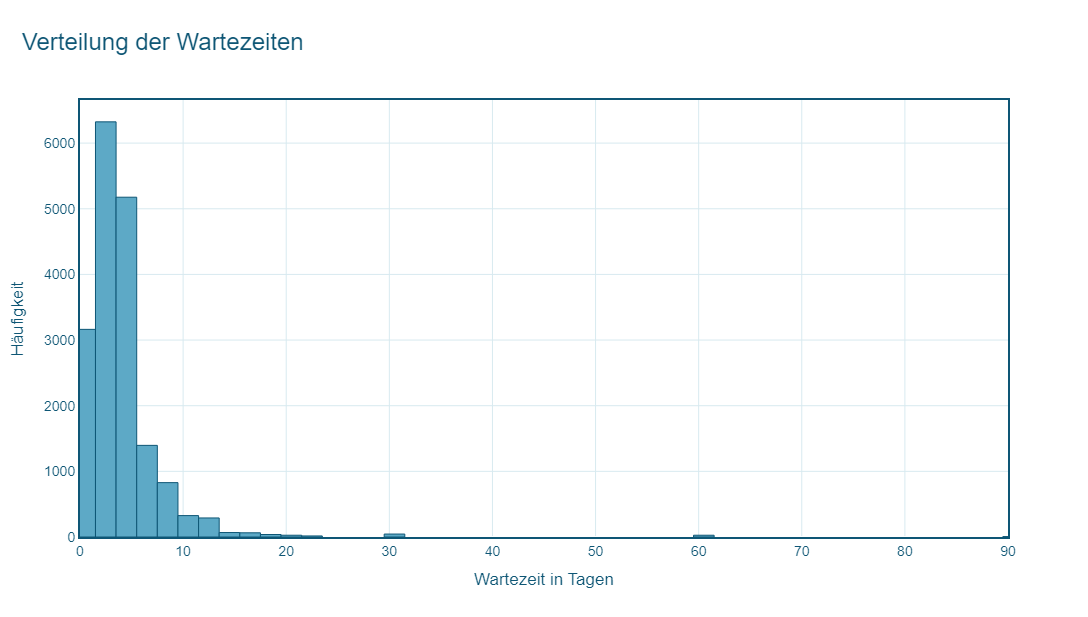

In [18]:
# Histogramm der Wartezeiten
# ==========================================================

# Histogramm erstellen
fig = px.histogram(
    x=days,
    nbins=60,                     # viele schmale Balken
    title="Verteilung der Wartezeiten"
)

# Farbschema
fig.update_traces(
    marker_color="#5DA9C6",
    marker_line_color="#0E5675",
    marker_line_width=1
)

# Layout
fig.update_layout(

    # Größe
    width=1200,
    height=600,

    # Hintergrund
    plot_bgcolor="white",
    paper_bgcolor="white",

    # Schrift
    font=dict(
        family="Arial",
        size=14,
        color="#0E5675"
    ),

    # Titel
    title=dict(
        text="Verteilung der Wartezeiten",
        x=0.02,
        font=dict(
            size=24,
            color="#0E5675"
        )
    ),

    # Achsen
    xaxis=dict(
        title="Wartezeit in Tagen",
        showgrid=True,
        gridcolor="#D8EAF0",
        linecolor="#0E5675"
    ),

    yaxis=dict(
        title="Häufigkeit",
        showgrid=True,
        gridcolor="#D8EAF0",
        linecolor="#0E5675"
    )
)
fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True
)
# Fokus auf den relevanten Bereich
fig.update_xaxes(range=[0, 90])

fig.show()

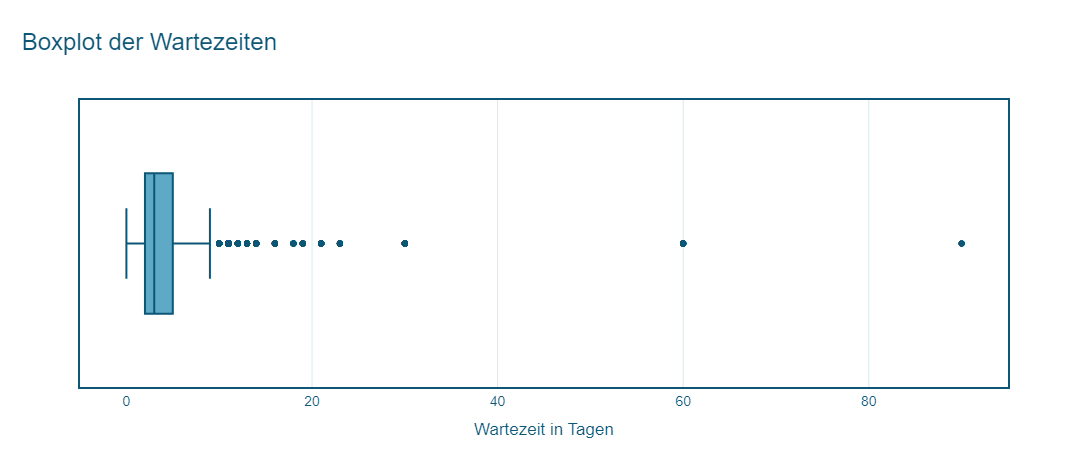

In [19]:
# Boxplot der Wartezeiten
# ==========================================================


# DataFrame für Plotly erzeugen
plot_df = pd.DataFrame({
    "Wartezeit": days
})

# Boxplot
fig = px.box(
    plot_df,
    x="Wartezeit",
    points="outliers",
    title="Boxplot der Wartezeiten"
)

# Farben
fig.update_traces(
    marker_color="#0E5675",
    line_color="#0E5675",
    fillcolor="#5DA9C6"
)

# Layout
fig.update_layout(
    width=1200,
    height=450,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#0E5675"
    ),

    title=dict(
        text="Boxplot der Wartezeiten",
        x=0.02,
        font=dict(
            size=24,
            color="#0E5675"
        )
    ),

    xaxis=dict(
        title="Wartezeit in Tagen",
        showgrid=True,
        gridcolor="#D8EAF0",
        linecolor="#0E5675"
    ),

    yaxis=dict(
        showticklabels=False,
        showgrid=False
    )
)
fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True
)
fig.show()

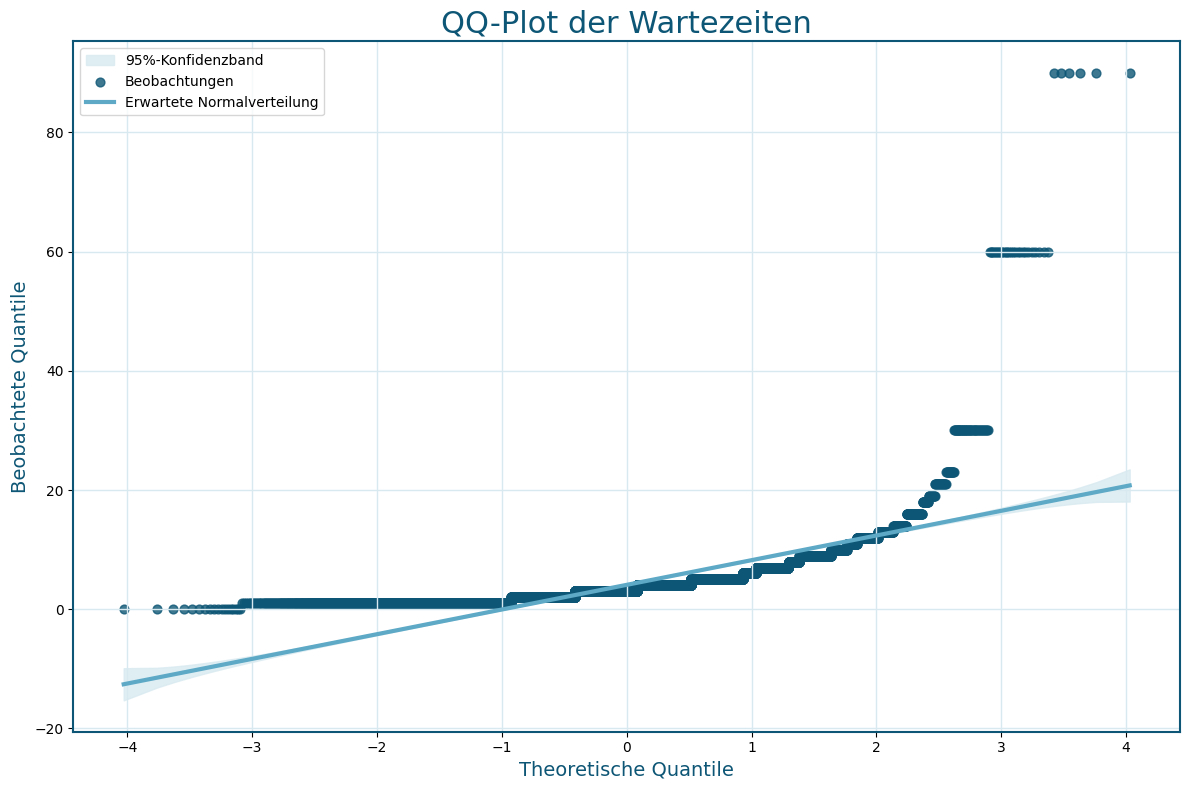

In [20]:
# QQ-Plot Wartezeiten mit 95%-Konfidenzband


# ----------------------------------------------------------
# Daten sortieren
# ----------------------------------------------------------

data = np.sort(days)
n = len(data)

# ----------------------------------------------------------
# Theoretische Quantile der Normalverteilung
# ----------------------------------------------------------

theoretical_quantiles = stats.norm.ppf(
    (np.arange(1, n + 1) - 0.5) / n
)

# ----------------------------------------------------------
# Mittelwert und Standardabweichung
# ----------------------------------------------------------

mean = np.mean(data)
std = np.std(data, ddof=1)

# Erwartete Quantile
expected = mean + std * theoretical_quantiles

# ----------------------------------------------------------
# 95%-Konfidenzband berechnen
# ----------------------------------------------------------

p = (np.arange(1, n + 1) - 0.5) / n

z = stats.norm.ppf(p)

pdf = stats.norm.pdf(z)

se = std * np.sqrt(
    p * (1 - p) / (n * (pdf ** 2))
)

lower = expected - 1.96 * se
upper = expected + 1.96 * se

# ----------------------------------------------------------
# Plot
# ----------------------------------------------------------

plt.figure(figsize=(12, 8))

# Konfidenzband
plt.fill_between(
    theoretical_quantiles,
    lower,
    upper,
    color="#D8EAF0",
    alpha=0.8,
    label="95%-Konfidenzband"
)

# Datenpunkte
plt.scatter(
    theoretical_quantiles,
    data,
    color="#0E5675",
    alpha=0.8,
    s=40,
    label="Beobachtungen"
)

# Referenzlinie
plt.plot(
    theoretical_quantiles,
    expected,
    color="#5DA9C6",
    linewidth=3,
    label="Erwartete Normalverteilung"
)

# ----------------------------------------------------------
# Styling
# ----------------------------------------------------------

plt.title(
    "QQ-Plot der Wartezeiten",
    fontsize=22,
    color="#0E5675"
)

plt.xlabel(
    "Theoretische Quantile",
    fontsize=14,
    color="#0E5675"
)

plt.ylabel(
    "Beobachtete Quantile",
    fontsize=14,
    color="#0E5675"
)

plt.grid(
    color="#D8EAF0",
    linewidth=1
)

ax = plt.gca()

for spine in ax.spines.values():
    spine.set_color("#0E5675")
    spine.set_linewidth(1.5)

plt.legend()

plt.tight_layout()
plt.show()


Die Verteilung der Wartezeiten wurde mittels Histogramm, Boxplot und QQ-Plot untersucht. Alle drei Darstellungen zeigen eine deutliche Rechtsschiefe sowie mehrere Extremwerte. Die Ergebnisse werden durch die Kennzahlen Skewness (7,97) und Kurtosis (115,97) bestätigt. Die Annahme einer Normalverteilung kann daher verworfen werden.

## 5. KPI-Framework und Funnelanalyse

Wie sieht mein Recruiting-Prozess insgesamt aus?

### 5.1 Prozess-KPIs

Die Kennzahl „Total Time to Hire“ wird als Zeitspanne zwischen Bewerbungseingang und finaler Vertragsunterzeichnung definiert. Die Zeit zwischen Vertragsunterzeichnung und tatsächlichem Arbeitsbeginn wird separat betrachtet, da sie nur eingeschränkt durch das Unternehmen beeinflusst werden kann und häufig von externen Faktoren wie Kündigungsfristen abhängt.


In [21]:
# Time to Hire:
# Bewerbungseingang → Vertragsunterzeichnung
# Application Received → Contract Signed

import pandas as pd

# 1. Start-Event auswählen: Bewerbung ist eingegangen
application_received = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Application Received"
    ][["application_id", "event_date"]]
    .rename(columns={"event_date": "application_received_date"})
)

# 2. End-Event auswählen: Vertrag wurde final unterschrieben
contract_signed = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Contract Signed"
    ][["application_id", "event_date"]]
    .rename(columns={"event_date": "contract_signed_date"})
)

# 3. Beide Events über die application_id zusammenführen
# how="inner" bedeutet:
# Es bleiben nur Bewerbungen übrig, die beide Events haben.
# Also nur Prozesse, die tatsächlich bis Contract Signed gekommen sind.
time_to_hire = application_received.merge(
    contract_signed,
    on="application_id",
    how="inner"
)

# 4. Datumsfelder sicherheitshalber in echte Datumswerte umwandeln
time_to_hire["application_received_date"] = pd.to_datetime(
    time_to_hire["application_received_date"]
)

time_to_hire["contract_signed_date"] = pd.to_datetime(
    time_to_hire["contract_signed_date"]
)

# 5. Differenz in Tagen berechnen
time_to_hire["time_to_hire_days"] = (
    time_to_hire["contract_signed_date"]
    - time_to_hire["application_received_date"]
).dt.days

# 6. Erste Kontrolle anzeigen
display(time_to_hire.head())

# 7. Deskriptive Kennzahlen berechnen
time_to_hire_days = time_to_hire["time_to_hire_days"]

print(f"Anzahl abgeschlossene Hires: {time_to_hire_days.count()}")
print(f"Mittelwert Time to Hire: {time_to_hire_days.mean():.2f} Tage")
print(f"Median Time to Hire: {time_to_hire_days.median()}")

,application_id,application_received_date,contract_signed_date,time_to_hire_days
0,A00153,2025-04-21,2025-05-30,39
1,A00169,2025-01-31,2025-03-07,35
2,A00183,2025-12-13,2026-02-11,60
3,A00308,2025-01-12,2025-03-06,53
4,A00372,2025-09-11,2025-10-15,34


Anzahl abgeschlossene Hires: 110
Mittelwert Time to Hire: 43.29 Tage
Median Time to Hire: 40.5


In [22]:
# Prozess-KPIs berechnen
# Für jede Kennzahl wird die Zeit zwischen zwei definierten Prozessschritten berechnet.

import pandas as pd

def calculate_process_kpi(start_event, end_event, kpi_name):
    """
    Berechnet eine Prozess-KPI als Zeitdifferenz zwischen zwei Events.

    start_event:
    Der Prozessschritt, ab dem gemessen wird.

    end_event:
    Der Prozessschritt, bis zu dem gemessen wird.

    kpi_name:
    Der Name der KPI, der später in der Ergebnis-Tabelle erscheint.
    """

    start_dates = (
        fact_candidate_events[
            fact_candidate_events["event_type"] == start_event
        ][["application_id", "event_date"]]
        .rename(columns={"event_date": "start_date"})
    )

    end_dates = (
        fact_candidate_events[
            fact_candidate_events["event_type"] == end_event
        ][["application_id", "event_date"]]
        .rename(columns={"event_date": "end_date"})
    )

    kpi_data = start_dates.merge(
        end_dates,
        on="application_id",
        how="inner"
    )

    kpi_data["start_date"] = pd.to_datetime(kpi_data["start_date"])
    kpi_data["end_date"] = pd.to_datetime(kpi_data["end_date"])

    kpi_data["duration_days"] = (
        kpi_data["end_date"] - kpi_data["start_date"]
    ).dt.days

    values = kpi_data["duration_days"]

    return {
        "KPI": kpi_name,
        "Start Event": start_event,
        "End Event": end_event,
        "Count": values.count(),
        "Mean": round(values.mean(), 2),
        "Median": round(values.median(), 2),
        "Min": values.min(),
        "Max": values.max(),
        "Std": round(values.std(), 2)
    }


process_kpis = pd.DataFrame([
    calculate_process_kpi("Application Received", "Application Reviewed", "Time to Review"),
    calculate_process_kpi("Application Received", "Interview Completed", "Time to Interview"),
    calculate_process_kpi("Application Received", "Offer Made", "Time to Offer"),
    calculate_process_kpi("Offer Accepted", "Contract Signed", "Time to Contract"),
    calculate_process_kpi("Contract Signed", "Employment Started", "Time to Start"),
    calculate_process_kpi("Application Received", "Contract Signed", "Total Time to Hire")
])

display(process_kpis)

,KPI,Start Event,End Event,Count,Mean,Median,Min,Max,Std
0,Time to Review,Application Received,Application Reviewed,7350,3.27,3.00,1,9,1.85
1,Time to Interview,Application Received,Interview Completed,1222,18.56,18.00,6,46,6.75
2,Time to Offer,Application Received,Offer Made,172,25.05,24.00,10,49,7.32
3,Time to Contract,Offer Accepted,Contract Signed,110,13.33,12.00,5,30,5.30
4,Time to Start,Contract Signed,Employment Started,110,33.69,30.00,0,90,24.27
5,Total Time to Hire,Application Received,Contract Signed,110,43.29,40.50,21,74,11.90


**Interpretation der Prozess-KPIs**

Die durchschnittliche **Time to Review** beträgt **3,27 Tage**. Der Median liegt bei **3 Tagen**, was auf eine relativ gleichmäßige Bearbeitung der eingehenden Bewerbungen hindeutet. Die meisten Bewerbungen werden somit innerhalb weniger Tage gesichtet und bewertet.

Die durchschnittliche **Time to Interview** liegt bei **18,56 Tagen**. Zwischen Bewerbungseingang und abgeschlossenem Interview vergehen damit im Mittel knapp drei Wochen. Dies umfasst sowohl die interne Prüfung der Bewerbung als auch die Terminfindung für das Interview.

Bis zur Erstellung eines Angebots (**Time to Offer**) vergehen durchschnittlich **25,05 Tage**. Der Unterschied von rund einer Woche zwischen Interview und Angebot deutet darauf hin, dass nach den Interviews zusätzliche Abstimmungs- und Entscheidungsprozesse stattfinden.

Die durchschnittliche **Time to Contract** beträgt **13,33 Tage**. Dieser Zeitraum umfasst die Erstellung, Abstimmung und Unterzeichnung des Vertrags. Die Spannweite von **5 bis 30 Tagen** zeigt, dass dieser Prozessschritt teilweise erheblichen Schwankungen unterliegt.

Die durchschnittliche **Time to Start** liegt bei **33,69 Tagen**. Diese Kennzahl weist die höchste Streuung aller Prozess-KPIs auf (Standardabweichung: **24,27 Tage**). Dies scheint plausibel, da der tatsächliche Arbeitsbeginn häufig von Faktoren beeinflusst wird, die außerhalb des direkten Einflussbereichs des Unternehmens liegen, beispielsweise Kündigungsfristen oder individuelle Starttermine.

Die zentrale Kennzahl **Total Time to Hire** – definiert als Zeitraum zwischen Bewerbungseingang und Vertragsunterzeichnung – beträgt durchschnittlich **43,29 Tage**. Der Median von **40,5 Tagen** liegt nahe am Mittelwert, was auf eine insgesamt stabile Prozessdauer hindeutet. Im betrachteten Datensatz dauert ein Recruiting-Prozess somit typischerweise etwa **sechs Wochen** bis zum unterschriebenen Vertrag.


**Mögliche erste Erkenntnisse**
Die längsten Prozessabschnitte entstehen zwischen **Bewerbung und Interview** sowie zwischen **Vertragsunterzeichnung und Arbeitsbeginn**.
Da die Zeit bis zum Arbeitsbeginn nur eingeschränkt durch das Unternehmen beeinflusst werden kann, erscheint insbesondere die Phase **Bewerbung → Interview → Angebot** als möglicher Hebel für Prozessoptimierungen.
Die weitere Analyse sollte untersuchen, ob sich diese Prozesszeiten zwischen Standorten, Recruiting-Kanälen oder Kandidatengruppen unterscheiden.

**Business-Hypothese**: Lange Wartezeiten zwischen Bewerbung, Interview und Angebot erhöhen die Wahrscheinlichkeit eines Kandidatenabbruchs und führen dadurch zu zusätzlichem Recruiting-Aufwand und höheren Prozesskosten.

### 5.2 Funnel-KPIs

In [23]:
# Erstellen der Funnel KPIs
# ==========================================================
# Funnel KPIs
# ==========================================================

# Anzahl Bewerbungen
applications = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Application Received"
    ]["application_id"]
    .nunique()
)

# Anzahl Intervieweinladungen
interview_invited = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Interview Invited"
    ]["application_id"]
    .nunique()
)

# Anzahl tatsächlich durchgeführter Interviews
interview_completed = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Interview Completed"
    ]["application_id"]
    .nunique()
)

# Anzahl Angebote
offers = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Offer Made"
    ]["application_id"]
    .nunique()
)

# Anzahl angenommener Angebote
offer_accepted = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Offer Accepted"
    ]["application_id"]
    .nunique()
)

# Anzahl tatsächlicher Starts
employment_started = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Employment Started"
    ]["application_id"]
    .nunique()
)

# ==========================================================
# Funnel Kennzahlen berechnen
# ==========================================================

interview_invitation_rate = interview_invited / applications

interview_completion_rate = (
    interview_completed / interview_invited
)

offer_rate = (
    offers / interview_completed
)

offer_acceptance_rate = (
    offer_accepted / offers
)

employment_start_rate = (
    employment_started / offer_accepted
)

# ==========================================================
# KPI-Tabelle erstellen
# ==========================================================

funnel_kpis = pd.DataFrame({
    "KPI": [
        "Interview Invitation Rate",
        "Interview Completion Rate",
        "Offer Rate",
        "Offer Acceptance Rate",
        "Employment Start Rate"
    ],
    "Value": [
        interview_invitation_rate,
        interview_completion_rate,
        offer_rate,
        offer_acceptance_rate,
        employment_start_rate
    ]
})

# Prozentformatierung
funnel_kpis["Value"] = (
    funnel_kpis["Value"] * 100
).round(2)

display(funnel_kpis)

,KPI,Value
0,Interview Invitation Rate,18.00
1,Interview Completion Rate,90.52
2,Offer Rate,14.08
3,Offer Acceptance Rate,69.77
4,Employment Start Rate,91.67


**Interpretation der Funnel-KPIs**

Die **Interview Invitation Rate** beträgt **18,0%**. Von 7.500 eingegangenen Bewerbungen werden somit rund 18 % der Kandidaten zu einem Interview eingeladen. Dies entspricht etwa jeder fünften bis sechsten Bewerbung und deutet auf einen selektiven Auswahlprozess hin.

Die **Interview Completion Rate** liegt bei **90,52%**. Der überwiegende Teil der eingeladenen Kandidaten nimmt das Interview tatsächlich wahr. Nur ein kleiner Anteil sagt nach der Einladung ab oder zieht sich vor dem Interview aus dem Prozess zurück.

Die **Offer Rate** beträgt **14,08%**. Bezogen auf die tatsächlich geführten Interviews erhalten nur wenige Kandidaten ein konkretes Angebot. Dies ist plausibel, da pro Position in der Regel nur eine Person eingestellt werden kann und mehrere Kandidaten miteinander konkurrieren.

Die **Offer Acceptance Rate** liegt bei **69,77%**. Etwa sieben von zehn Kandidaten nehmen ein erhaltenes Angebot an. Gleichzeitig lehnt rund ein Drittel der Kandidaten ein Angebot ab. Dieser Prozessschritt stellt damit einen relevanten Hebel für mögliche Optimierungen dar.

Die **Employment Start Rate** beträgt **91,67%**. Der überwiegende Teil der Kandidaten tritt die Stelle nach Vertragsunterzeichnung tatsächlich an. Die Anzahl der Abbrüche zwischen Vertragsunterzeichnung und Arbeitsbeginn ist zwar vergleichsweise gering, diese Fälle besitzen jedoch eine hohe betriebswirtschaftliche Relevanz. Zu diesem Zeitpunkt wurden bereits erhebliche Ressourcen in den Recruiting-Prozess investiert und die Position bleibt trotz erfolgreicher Vertragsunterzeichnung weiterhin unbesetzt. Jeder einzelne Abbruch kann daher zusätzliche Kosten und einen erneuten Recruiting-Aufwand verursachen.

**Zusammenfassung**

Der Recruiting-Funnel zeigt einen stark selektiven Prozess mit einer Intervieweinladungsrate von 18%. Gleichzeitig ist die Teilnahmebereitschaft der eingeladenen Kandidaten mit über 90% sehr hoch. Die größte freiwillige Reduktion im Funnel erfolgt nach dem Angebot: Rund 30% der Kandidaten entscheiden sich gegen das Unternehmen. Nach Vertragsunterzeichnung ist die Abbruchquote zwar geringer, sodass die meisten Kandidaten den Recruiting-Prozess erfolgreich abschließen und ihre Beschäftigung antreten, jedoch ist jeder Dropout an dieser Stelle besonders schmerzhaft, weil der gesamte Prozess erneut durchlaufen werden muss und die Vakanz erstmal bestehen bleibt.

**Erste mögliche Erkenntnisse**

- Die Interviewphase scheint insgesamt stabil zu funktionieren, da nur wenige Kandidaten nach der Einladung abspringen.
- Der Übergang vom Angebot zur Zusage stellt den größten freiwilligen Verlustpunkt im Recruiting-Funnel dar.
- Maßnahmen zur Verbesserung der Candidate Experience sowie eine Verkürzung von Entscheidungs- und Angebotsprozessen könnten die Offer Acceptance Rate erhöhen.
- Eine höhere Offer Acceptance Rate würde direkt zu mehr erfolgreichen Einstellungen bei gleichem Recruiting-Aufwand führen und damit zur Reduzierung von Prozesskosten beitragen.

### 5.3 Candidate Experience KPIs

In [24]:
# Erstellen der Candidate Experience KPIs
# ==========================================================
# Candidate Experience KPIs
# ==========================================================

# Kandidaten steigen nach Intervieweinladung aus
candidate_dropout = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Candidate Dropout"
    ]["application_id"]
    .nunique()
)

# Intervieweinladungen
interview_invited = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Interview Invited"
    ]["application_id"]
    .nunique()
)

# Angebote abgelehnt
offer_declined = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Offer Declined"
    ]["application_id"]
    .nunique()
)

# Angebote erstellt
offers = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Offer Made"
    ]["application_id"]
    .nunique()
)

# Contract Dropouts
contract_dropout = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Contract Dropout"
    ]["application_id"]
    .nunique()
)

# Angebote angenommen
offer_accepted = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Offer Accepted"
    ]["application_id"]
    .nunique()
)

# Durchschnittliche Wartezeit
avg_waiting_time = (
    fact_candidate_events["waiting_days_since_last_event"]
    .mean()
)

# ==========================================================
# Kennzahlen berechnen
# ==========================================================

candidate_dropout_rate = (
    candidate_dropout / interview_invited
)

offer_decline_rate = (
    offer_declined / offers
)

contract_dropout_rate = (
    contract_dropout / offer_accepted
)

# ==========================================================
# KPI-Tabelle
# ==========================================================

candidate_experience_kpis = pd.DataFrame({
    "KPI": [
        "Candidate Dropout Rate",
        "Offer Decline Rate",
        "Contract Dropout Rate",
        "Average Waiting Time"
    ],
    "Value": [
        round(candidate_dropout_rate * 100, 2),
        round(offer_declined / offers * 100, 2),
        round(contract_dropout_rate * 100, 2),
        round(avg_waiting_time, 2)
    ],
    "Unit": [
        "%",
        "%",
        "%",
        "Days"
    ]
})

display(candidate_experience_kpis)

,KPI,Value,Unit
0,Candidate Dropout Rate,9.48,%
1,Offer Decline Rate,30.23,%
2,Contract Dropout Rate,8.33,%
3,Average Waiting Time,4.09,Days


**Interpretation der Candidate Experience KPIs**

Die **Candidate Dropout Rate** beträgt **9,48 %**. Rund jeder zehnte Kandidat zieht sich nach der Intervieweinladung freiwillig aus dem Bewerbungsprozess zurück. Dies kann darauf hindeuten, dass Kandidaten während des Prozesses ihre Prioritäten ändern oder sich für alternative Möglichkeiten entscheiden. Gleichzeitig stellt diese Kennzahl einen wichtigen Indikator für die Attraktivität und Wahrnehmung des Recruiting-Prozesses dar.

Die **Offer Decline Rate** liegt bei **30,23 %**. Knapp ein Drittel der Kandidaten lehnt ein erhaltenes Jobangebot ab. Dieser Prozessschritt stellt den größten freiwilligen Verlustpunkt innerhalb des Recruiting-Funnels dar. Da zu diesem Zeitpunkt bereits erhebliche Ressourcen in Auswahlgespräche und Entscheidungsprozesse investiert wurden, besitzt diese Kennzahl eine hohe betriebswirtschaftliche Relevanz.

Die **Contract Dropout Rate** beträgt **8,33 %**. Obwohl die Anzahl dieser Fälle vergleichsweise gering erscheint, sind die Auswirkungen für das Unternehmen besonders hoch. Die Kandidaten haben den Recruiting-Prozess bereits erfolgreich durchlaufen und den Vertrag angenommen. Kommt es dennoch zu einem Absprung vor Vertragsunterzeichnung oder Arbeitsbeginn, muss der Besetzungsprozess häufig erneut gestartet werden, wodurch zusätzlicher Zeit- und Kostenaufwand entsteht.

Die durchschnittliche **Wartezeit zwischen zwei Prozessschritten** beträgt **4,09 Tage**. Der Median von 3 Tagen zeigt, dass die meisten Prozessschritte innerhalb weniger Tage erfolgen. Gleichzeitig weisen einzelne deutlich längere Wartezeiten auf Verzögerungen innerhalb des Recruiting-Prozesses hin.

**Zusammenfassung**

Die Candidate Experience KPIs zeigen, dass die meisten Kandidaten den Recruiting-Prozess erfolgreich durchlaufen. Die größten freiwilligen Verluste entstehen nach der Angebotserstellung, wenn Kandidaten sich trotz eines Angebots gegen das Unternehmen entscheiden. Darüber hinaus besitzen auch die vergleichsweise seltenen Vertragsabbrüche eine hohe wirtschaftliche Bedeutung, da sie erst sehr spät im Recruiting-Prozess auftreten und bereits investierte Ressourcen verloren gehen können.

Aus Sicht des Unternehmens erscheint insbesondere die Phase zwischen Interview, Angebotsabgabe und Vertragsabschluss als relevanter Ansatzpunkt für weitere Analysen. Kürzere Durchlaufzeiten und eine höhere Prozessgeschwindigkeit könnten dazu beitragen, freiwillige Kandidatenabbrüche zu reduzieren und die Effizienz des Recruiting-Prozesses zu steigern.

## 6. Explorative Gruppenanalysen (EDA)

Ziel: Untersuchung, ob sich Wartezeiten, Dropout-Raten oder Erfolgsquoten
zwischen verschiedenen Kandidaten- und Prozessgruppen unterscheiden. Also wo sollte man im Anschluss genauer hinschauen?

### 6.1 Standorte

#### 6.1.1 Deskreptive Statistik Time to Hire

In [25]:
# Deskriptive Statistik der Time to Hire nach Standort
# ==========================================================
# Time to Hire nach Standort
# ==========================================================

# Ziel:
# Wir gruppieren die Time to Hire nach Standort.
# Dafür brauchen wir:
# - application_id
# - job_id
# - time_to_hire_days
# - location_id
# - city

# 1. job_id aus der Faktentabelle ergänzen
# Jede application_id gehört zu einer job_id.
# Da die job_id in jeder Eventzeile steht, reicht es,
# pro Bewerbung eine Zeile zu nehmen.

application_jobs = (
    fact_candidate_events[["application_id", "job_id"]]
    .drop_duplicates()
)

# 2. job_id an time_to_hire anhängen

time_to_hire_location = time_to_hire.merge(
    application_jobs,
    on="application_id",
    how="left"
)

# 3. Standort-ID aus dim_job ergänzen

time_to_hire_location = time_to_hire_location.merge(
    dim_job[["job_id", "location_id"]],
    on="job_id",
    how="left"
)

# 4. Standortname aus dim_location ergänzen

time_to_hire_location = time_to_hire_location.merge(
    dim_location[["location_id", "city"]],
    on="location_id",
    how="left"
)

# 5. Kennzahlen je Standort berechnen

location_summary = (
    time_to_hire_location
    .groupby("city")["time_to_hire_days"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Minimum="min",
        Maximum="max",
        Skewness="skew",
        Kurtosis=pd.Series.kurt
    )
    .round(2)
    .sort_values(
        by="Mittelwert",
        ascending=False
    )
)

location_summary

display(location_summary)

,Anzahl,Mittelwert,Median,Standardabweichung,Minimum,Maximum,Skewness,Kurtosis
city,,,,,,,,
Frankfurt,26,60.65,62.00,8.89,43,74,-0.45,-0.91
Hamburg,26,38.77,38.00,6.40,21,52,-0.41,1.56
Berlin,17,37.82,40.00,5.93,26,48,-0.62,-0.15
Köln,20,37.60,39.50,7.96,22,56,-0.11,0.72
München,21,37.24,37.00,4.33,29,45,-0.07,-0.59


#### 6.1.2 Boxplot & Histogramm Time to Hire

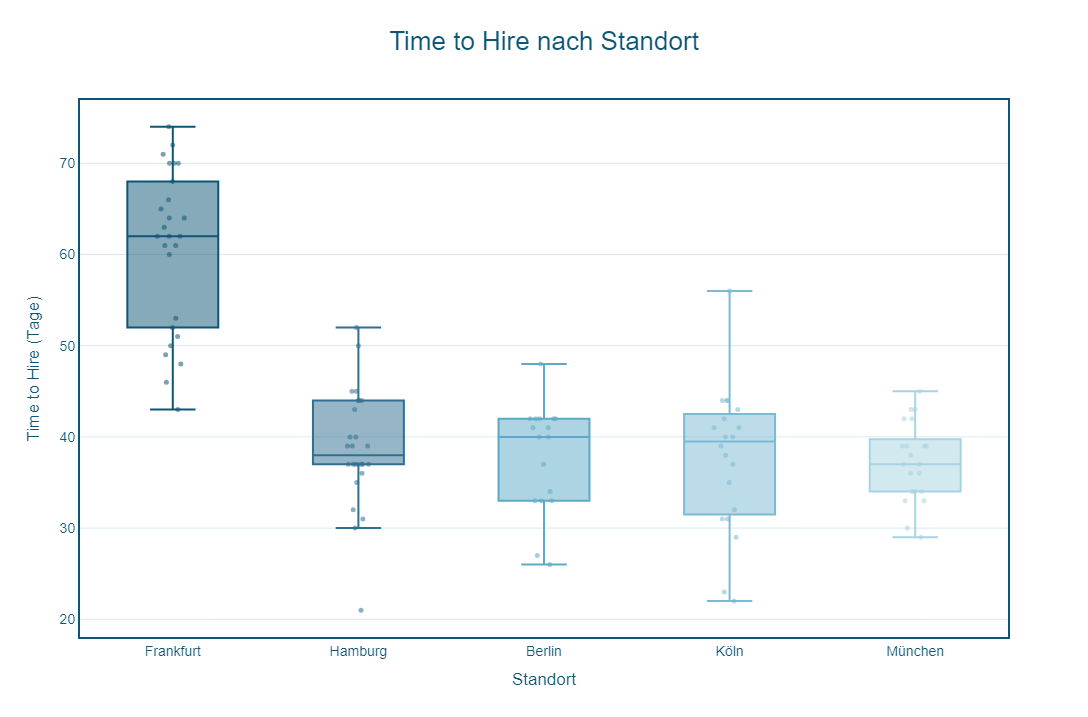

In [26]:
# Boxplot Time to Hire nach Standort
# Plotly Express
# ==========================================================
#
# Ziel:
# Vergleich der Time to Hire zwischen den Standorten.
#
# Der Plotly-Boxplot zeigt:
# - Median
# - Quartile
# - Ausreißer
# - einzelne Einstellungen (Punkte)


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_5 = [
    "#0E5675",
    "#2F6F91",
    "#5DA9C6",
    "#7CB9D4",
    "#A8D4E2"
]


# ----------------------------------------------------------
# 2. Reihenfolge nach durchschnittlicher Time to Hire
# ----------------------------------------------------------

order = (
    time_to_hire_location
    .groupby("city")["time_to_hire_days"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Boxplot erstellen
# ----------------------------------------------------------

fig = px.box(
    time_to_hire_location,
    x="city",
    y="time_to_hire_days",
    color="city",
    category_orders={
        "city": order
    },
    color_discrete_sequence=PALETTE_5,
    points="all",
    title="Time to Hire nach Standort"
)


# ----------------------------------------------------------
# 4. Transparenz der Einzelpunkte anpassen
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.35,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.55
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Time to Hire nach Standort",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Standort",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    showgrid=False
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

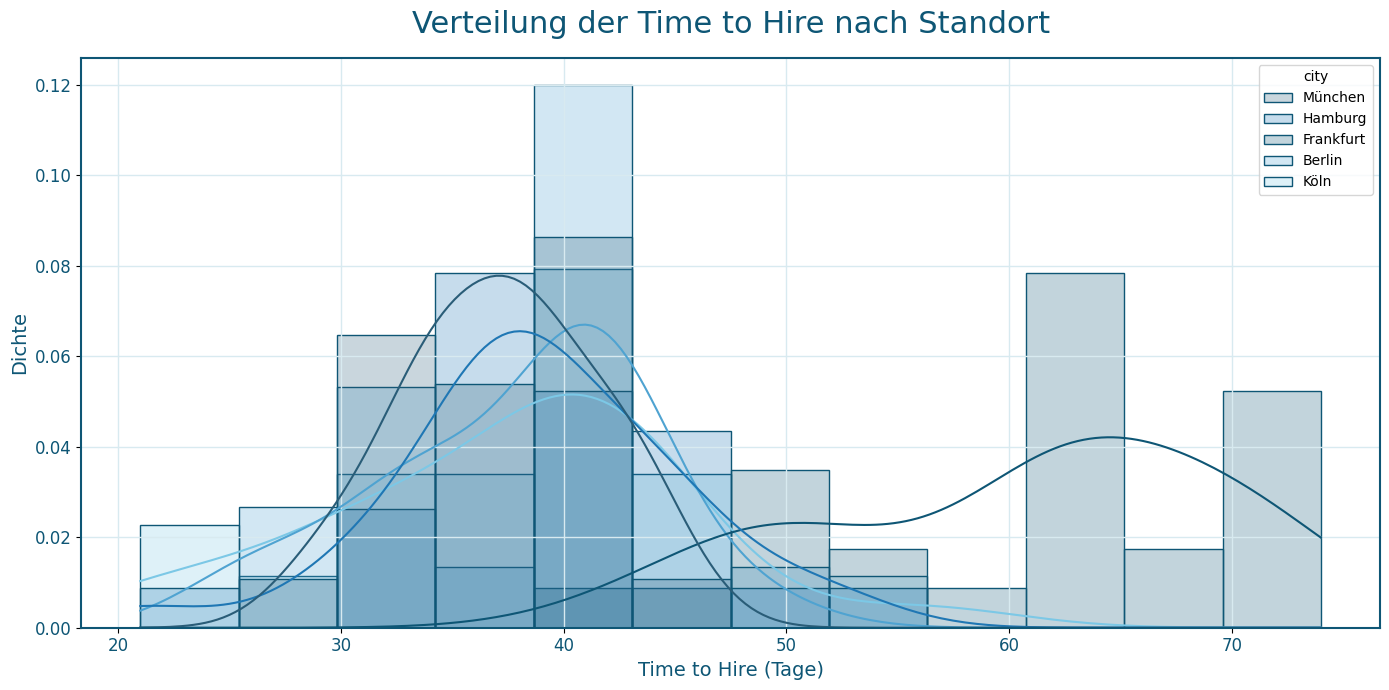

In [27]:
# Histogramm und Verteilungskurven Time to Hire nach Standort
# ==========================================================

palette = {
    "Frankfurt": "#0E5675",   # dunkelblau
    "Hamburg":   "#1F77B4",   # kräftiges blau
    "Berlin":    "#4FA3D1",   # mittelblau
    "Köln":      "#7CC8E6",   # hellblau
    "München":   "#2A5D78"    # petrol
}

plt.figure(figsize=(14, 7))

sns.histplot(
    data=time_to_hire_location,
    x="time_to_hire_days",
    hue="city",
    bins=12,
    kde=True,
    stat="density",
    common_norm=False,
    alpha=0.25,
    palette=palette,
    edgecolor="#0E5675",
    linewidth=1
)

plt.title(
    "Verteilung der Time to Hire nach Standort",
    fontsize=22,
    color="#0E5675",
    pad=18
)

plt.xlabel(
    "Time to Hire (Tage)",
    fontsize=14,
    color="#0E5675"
)

plt.ylabel(
    "Dichte",
    fontsize=14,
    color="#0E5675"
)

plt.xticks(
    fontsize=12,
    color="#0E5675"
)

plt.yticks(
    fontsize=12,
    color="#0E5675"
)

plt.grid(
    color="#D8EAF0",
    linewidth=1
)

ax = plt.gca()

# Rahmen
for spine in ax.spines.values():
    spine.set_color("#0E5675")
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()


#### 6.1.3 Violinplot Time to Hire

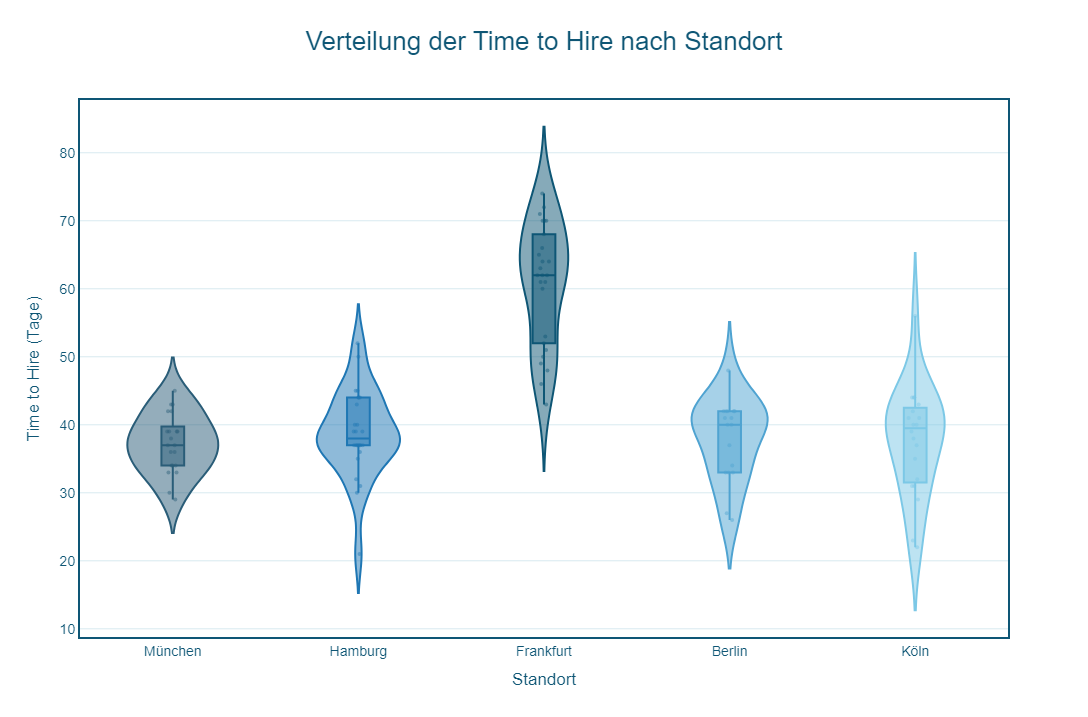

In [28]:
# Violinplot Time to Hire nach Standort
# Plotly Express
# ==========================================================
#
# Ziel:
# Visualisierung der Verteilung der Time to Hire
# nach Standort.
#
# Der Violinplot zeigt:
# - Verteilungsform
# - Median
# - Quartile
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

palette = {
    "Frankfurt": "#0E5675",
    "Hamburg": "#1F77B4",
    "Berlin": "#4FA3D1",
    "Köln": "#7CC8E6",
    "München": "#2A5D78"
}


# ----------------------------------------------------------
# 2. Violinplot erstellen
# ----------------------------------------------------------

fig = px.violin(
    time_to_hire_location,
    x="city",
    y="time_to_hire_days",
    color="city",
    box=True,
    points="all",
    color_discrete_map=palette,
    title="Verteilung der Time to Hire nach Standort"
)


# ----------------------------------------------------------
# 3. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.15,
    pointpos=0,
    marker=dict(
        size=4,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 4. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Verteilung der Time to Hire nach Standort",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Standort",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 5. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 6. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.1.4 Interpretation Time to Hire nach Standort

Die Analyse der Time-to-Hire zeigt erkennbare Unterschiede zwischen den Standorten.

Frankfurt weist mit einem Median von rund 62 Tagen die längsten Besetzungszeiten auf. Gleichzeitig liegen die Werte dort insgesamt auf einem höheren Niveau als an den übrigen Standorten. Dies deutet darauf hin, dass Stellen in Frankfurt im Durchschnitt mehr Zeit bis zur erfolgreichen Besetzung benötigen.

Hamburg, München, Berlin und Köln bewegen sich dagegen in einem ähnlichen Bereich zwischen etwa 37 und 42 Tagen. Die Unterschiede zwischen diesen vier Standorten fallen deutlich geringer aus als der Abstand zu Frankfurt.

Die Boxplots zeigen zudem, dass die Streuung der Time-to-Hire in Frankfurt größer ist als an den meisten anderen Standorten. Einzelne sehr lange Besetzungszeiten weisen auf mögliche Ausreißer oder besonders schwer zu besetzende Positionen hin.

Die Violinplots bestätigen die Ergebnisse der deskriptiven Statistik und der Boxplots. In Frankfurt konzentrieren sich die Werte auf einem höheren Niveau als an den übrigen Standorten. Die längeren Besetzungszeiten sind daher nicht nur auf einzelne Ausreißer zurückzuführen, sondern zeigen sich über einen größeren Teil der Verteilung.

Insgesamt deutet die Analyse darauf hin, dass der Standort einen Einfluss auf die Dauer des Recruiting-Prozesses haben könnte. Besonders Frankfurt unterscheidet sich hinsichtlich der Time-to-Hire deutlich von den übrigen Standorten.

#### 6.1.5 KPI-Tabelle

In [29]:
# KPI-Tabelle nach Standort
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Recruiting-KPIs
# zwischen den Standorten unterscheiden.
#
# Betrachtete Kennzahlen:
# - Applications
# - Interview Invitation Rate
# - Interview Completion Rate
# - Offer Rate
# - Offer Acceptance Rate
# - Employment Start Rate


# ----------------------------------------------------------
# 1. Standort pro Bewerbung ermitteln
# ----------------------------------------------------------

application_locations = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
)

application_locations = (
    application_locations
    .merge(
        dim_job[
            ["job_id", "location_id"]
        ],
        on="job_id",
        how="left"
    )
)

application_locations = (
    application_locations
    .merge(
        dim_location[
            ["location_id", "city"]
        ],
        on="location_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 2. Event-Daten um Standort ergänzen
# ----------------------------------------------------------

location_events = (
    fact_candidate_events
    .merge(
        application_locations[
            ["application_id", "city"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. KPI-Tabelle erstellen
# ----------------------------------------------------------

location_summary = []

for city in sorted(location_events["city"].dropna().unique()):

    subset = location_events[
        location_events["city"] == city
    ]

    applications = subset["application_id"].nunique()

    invited = subset[
        subset["event_type"] == "Interview Invited"
    ]["application_id"].nunique()

    completed = subset[
        subset["event_type"] == "Interview Completed"
    ]["application_id"].nunique()

    offer_made = subset[
        subset["event_type"] == "Offer Made"
    ]["application_id"].nunique()

    offer_accepted = subset[
        subset["event_type"] == "Offer Accepted"
    ]["application_id"].nunique()

    started = subset[
        subset["event_type"] == "Employment Started"
    ]["application_id"].nunique()

    location_summary.append({

        "Standort": city,

        "Applications": applications,

        "Interview Invited": invited,

        "Interview Completed": completed,

        "Offer Made": offer_made,

        "Offer Accepted": offer_accepted,

        "Employment Started": started,

        "Interview Invitation Rate":
            round(invited / applications * 100, 2)
            if applications else 0,

        "Interview Completion Rate":
            round(completed / invited * 100, 2)
            if invited else 0,

        "Offer Rate":
            round(offer_made / completed * 100, 2)
            if completed else 0,

        "Offer Acceptance Rate":
            round(offer_accepted / offer_made * 100, 2)
            if offer_made else 0,

        "Employment Start Rate":
            round(started / offer_accepted * 100, 2)
            if offer_accepted else 0
    })


# ----------------------------------------------------------
# 4. DataFrame erzeugen
# ----------------------------------------------------------

location_summary = pd.DataFrame(location_summary)


# ----------------------------------------------------------
# 5. Nach Offer Acceptance Rate sortieren
# ----------------------------------------------------------

location_summary = (
    location_summary
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
    .set_index("Standort")
)


# ----------------------------------------------------------
# 6. Tabelle anzeigen
# ----------------------------------------------------------

display(location_summary)

,Applications,Interview Invited,Interview Completed,Offer Made,Offer Accepted,Employment Started,Interview Invitation Rate,Interview Completion Rate,Offer Rate,Offer Acceptance Rate,Employment Start Rate
Standort,,,,,,,,,,,
Frankfurt,1221,226,212,34,27,26,18.51,93.81,16.04,79.41,96.30
München,1274,221,195,33,23,21,17.35,88.24,16.92,69.70,91.30
Köln,1475,274,243,33,23,20,18.58,88.69,13.58,69.70,86.96
Hamburg,1829,301,281,42,28,26,16.46,93.36,14.95,66.67,92.86
Berlin,1701,328,291,30,19,17,19.28,88.72,10.31,63.33,89.47


#### 6.1.6 Balkendiagramm Offer Acceptance Rate

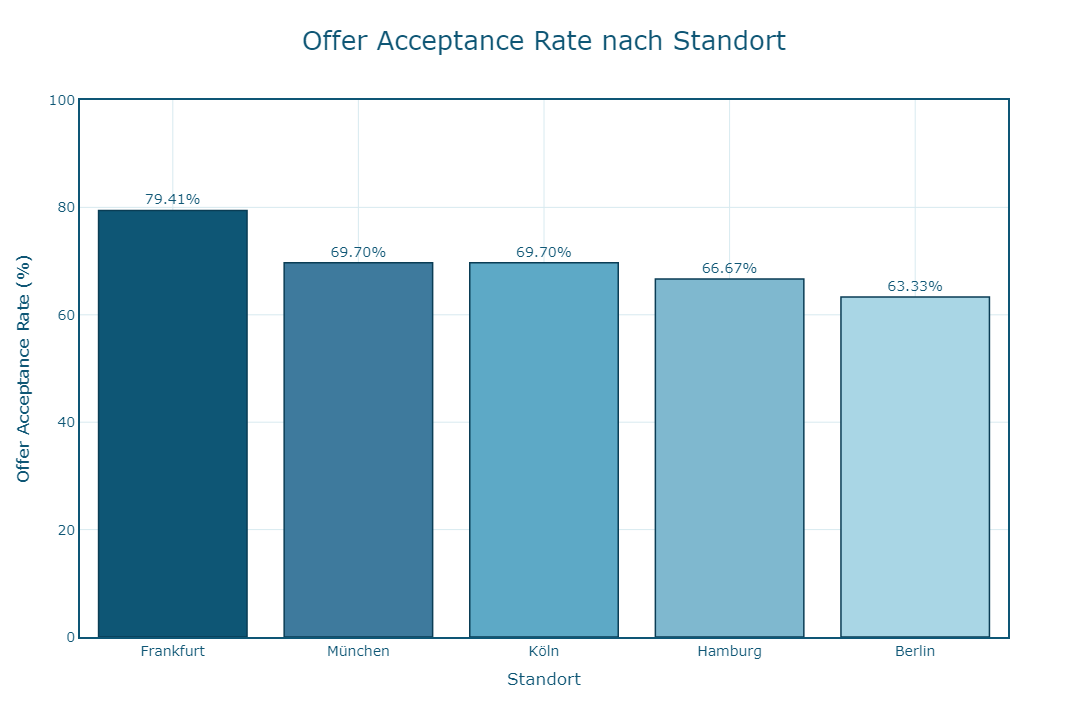

In [30]:
# Offer Acceptance Rate nach Standort
# ==========================================================
#
# Ziel:
# Vergleich der Angebotsannahmerate zwischen den Standorten.
# Die Grafik zeigt, an welchen Standorten Kandidaten
# Jobangebote häufiger annehmen.


# ----------------------------------------------------------
# 1. Daten für Plotly vorbereiten
# ----------------------------------------------------------

plot_df = (
    location_summary
    .reset_index()
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)


# ----------------------------------------------------------
# 2. Farbverlauf definieren
# ----------------------------------------------------------

colors = [
    "#0E5675",  # dunkel
    "#3E7A9D",
    "#5DA9C6",
    "#7FB8CF",
    "#A9D6E5"   # hell
]


# ----------------------------------------------------------
# 3. Balkendiagramm erstellen
# ----------------------------------------------------------

fig = px.bar(
    plot_df,
    x="Standort",
    y="Offer Acceptance Rate",
    text="Offer Acceptance Rate",
    color="Standort",
    color_discrete_sequence=colors,
    title="Offer Acceptance Rate nach Standort"
)


# ----------------------------------------------------------
# 4. Werte oberhalb der Balken anzeigen
# ----------------------------------------------------------

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside",
    marker_line_color="#0A3D55",
    marker_line_width=1.5
)


# ----------------------------------------------------------
# 5. Layout im Corporate Design
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        size=14,
        color="#0E5675"
    ),

    title=dict(
        text="Offer Acceptance Rate nach Standort",
        font=dict(
            size=26,
            color="#0E5675"
        ),
        x=0.5
    ),

    xaxis_title="Standort",
    yaxis_title="Offer Acceptance Rate (%)",

    yaxis_range=[0, 100],

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.1.7 Interpretation der KPI-Tabelle und der Offer Acceptance Rate nach Standort

**Frankfurt weist die höchste Offer Acceptance Rate auf.**
Mit einer Angebotsannahmerate von **79,41 %** liegt Frankfurt deutlich vor allen anderen Standorten. Kandidaten nehmen dort Jobangebote besonders häufig an. Zudem zeigt Frankfurt mit **96,30 %** die höchste Employment Start Rate, sodass die meisten angenommenen Angebote auch tatsächlich zu einem Arbeitsbeginn führen.

**München und Köln bilden das Mittelfeld.**
Beide Standorte erreichen eine Offer Acceptance Rate von **69,70 %**. Obwohl Köln mehr Bewerbungen und Intervieweinladungen verzeichnet als München, unterscheiden sich die Erfolgsquoten der Angebotsannahme kaum.

**Hamburg liegt leicht unter dem Durchschnitt.**
Mit einer Offer Acceptance Rate von **66,67 %** werden rund zwei Drittel aller Angebote angenommen. Gleichzeitig weist Hamburg die höchste Anzahl an Bewerbungen und abgeschlossenen Interviews auf, was auf einen größeren Recruiting-Umfang hindeutet.

**Berlin zeigt die niedrigste Offer Acceptance Rate.**
Nur **63,33 %** der ausgesprochenen Angebote werden angenommen. Zudem weist Berlin mit **10,31 %** die niedrigste Offer Rate auf. Dies könnte darauf hindeuten, dass Stellen schwieriger zu besetzen sind oder Kandidaten häufiger alternative Angebote bevorzugen.

Die Ergebnisse deuten darauf hin, dass der **Standort einen Einfluss auf die Angebotsannahme haben könnte**. Besonders Frankfurt sticht mit einer deutlich höheren Offer Acceptance Rate hervor, während Berlin die niedrigsten Werte erzielt. Die Unterschiede von rund **16 Prozentpunkten zwischen Frankfurt und Berlin** sind im Vergleich zu den zuvor betrachteten Recruiting Channels oder Fachbereichen relativ deutlich und könnten ein Hinweis auf standortspezifische Faktoren wie Arbeitsmarktbedingungen, Wettbewerb um Talente oder Attraktivität des Standorts sein.

Die explorative Analyse zeigt Unterschiede zwischen den Standorten sowohl hinsichtlich der Time to Hire als auch der Offer Acceptance Rate. Diese werden im nächsten Kapitel überprüft.

### 6.2 Recruiting Channels

#### 6.2.1 Deskreptive Statistik Time to Hire

In [31]:
# Deskriptive Statistik der Time to Hire nach Recruiting Channel
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen den Recruiting Channels unterscheidet.
#
# Berechnet werden:
# - Anzahl
# - Mittelwert
# - Median
# - Standardabweichung
# - Minimum
# - Maximum


# ----------------------------------------------------------
# 1. Recruiting Channel pro Bewerbung ermitteln
# ----------------------------------------------------------

application_channels = (
    fact_candidate_events[
        ["application_id", "channel_id"]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 2. Lesbare Channel-Namen ergänzen
# ----------------------------------------------------------

application_channels = (
    application_channels
    .merge(
        dim_recruiting_channel[
            ["channel_id", "channel_name"]
        ],
        on="channel_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Time-to-Hire-Daten mit Recruiting Channel verbinden
# ----------------------------------------------------------

time_to_hire_channel = (
    time_to_hire
    .merge(
        application_channels[
            ["application_id", "channel_name"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 4. Deskriptive Statistik berechnen
# ----------------------------------------------------------

channel_stats = (
    time_to_hire_channel
    .groupby("channel_name")["time_to_hire_days"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Minimum="min",
        Maximum="max",
        Skewness="skew",
        Kurtosis=pd.Series.kurt
    )
    .round(2)
)


# ----------------------------------------------------------
# 5. Nach Mittelwert sortieren
# ----------------------------------------------------------

channel_stats = (
    channel_stats
    .sort_values(
        by="Mittelwert",
        ascending=False
    )
)


# ----------------------------------------------------------
# 6. Tabelle anzeigen
# ----------------------------------------------------------

display(channel_stats)

,Anzahl,Mittelwert,Median,Standardabweichung,Minimum,Maximum,Skewness,Kurtosis
channel_name,,,,,,,,
Job Board,27,46.89,44.00,12.71,27,72,0.60,-0.54
Recruiting Agency,11,45.27,39.00,13.90,32,70,0.99,-0.74
LinkedIn,35,43.20,41.00,12.71,21,74,0.68,0.30
Referral,17,41.18,40.00,8.76,30,61,1.24,1.29
Career Page,20,39.30,38.50,9.73,26,71,1.81,5.31


#### 6.2.2 Boxplot Time to Hire

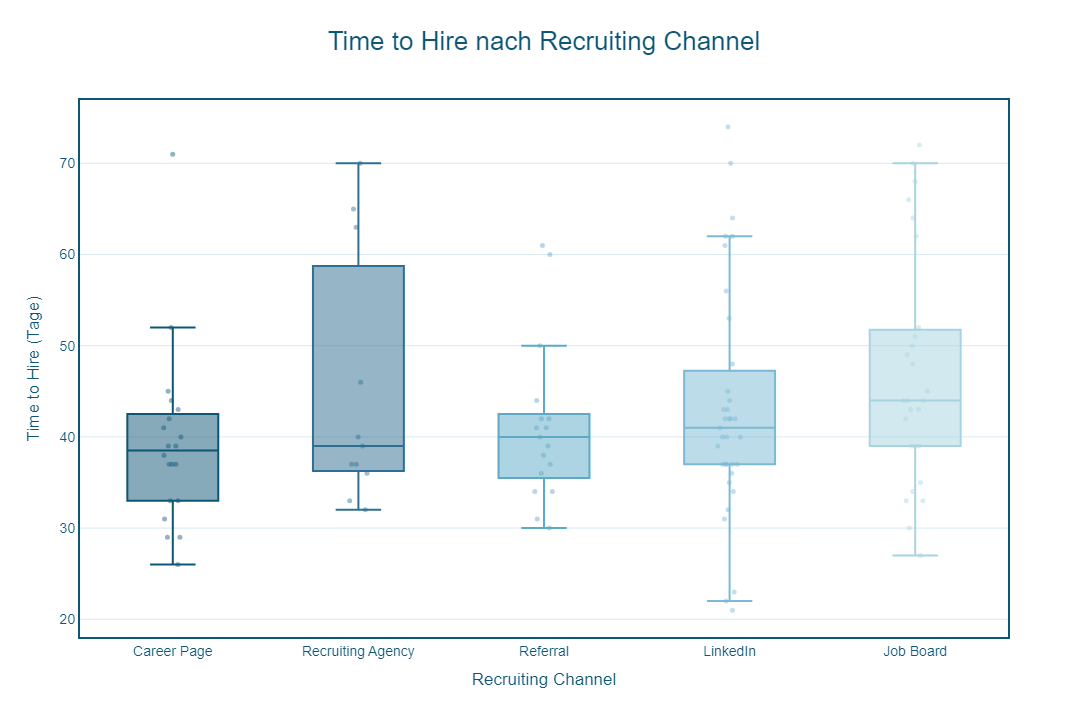

In [32]:
# Boxplot Time to Hire nach Recruiting Channel
# Plotly Express
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen den Recruiting Channels unterscheidet.
#
# Der Boxplot zeigt:
# - Median
# - Quartile
# - Streuung
# - Ausreißer
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_5 = [
    "#0E5675",
    "#2F6F91",
    "#5DA9C6",
    "#7CB9D4",
    "#A8D4E2"
]


# ----------------------------------------------------------
# 2. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

channel_order = (
    time_to_hire_channel
    .groupby("channel_name")["time_to_hire_days"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Boxplot erstellen
# ----------------------------------------------------------

fig = px.box(
    time_to_hire_channel,
    x="channel_name",
    y="time_to_hire_days",
    color="channel_name",
    points="all",
    category_orders={
        "channel_name": channel_order
    },
    color_discrete_sequence=PALETTE_5,
    title="Time to Hire nach Recruiting Channel"
)


# ----------------------------------------------------------
# 4. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.30,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Time to Hire nach Recruiting Channel",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Recruiting Channel",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.2.3 Violinplot

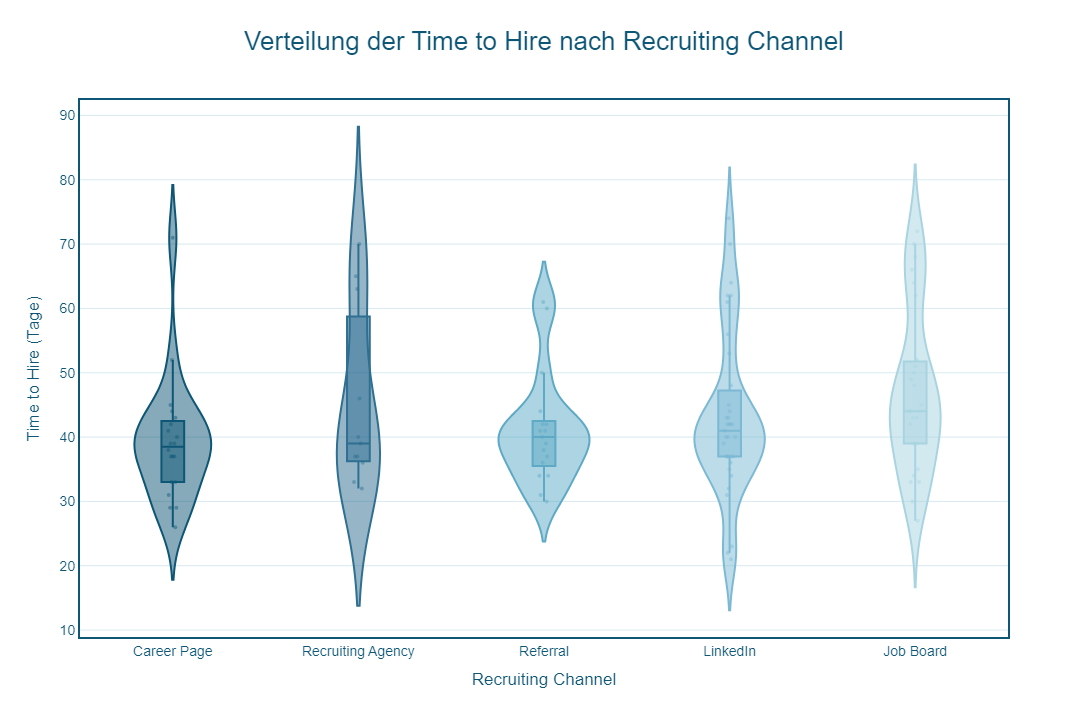

In [33]:
# Violinplot Time to Hire nach Recruiting Channel
# Plotly Express
# ==========================================================
#
# Ziel:
# Visualisierung der Verteilung der Time to Hire
# je Recruiting Channel.
#
# Der Violinplot zeigt:
# - Verteilungsform
# - Median
# - Quartile
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_5 = [
    "#0E5675",
    "#2F6F91",
    "#5DA9C6",
    "#7CB9D4",
    "#A8D4E2"
]


# ----------------------------------------------------------
# 2. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

channel_order = (
    time_to_hire_channel
    .groupby("channel_name")["time_to_hire_days"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Violinplot erstellen
# ----------------------------------------------------------

fig = px.violin(
    time_to_hire_channel,
    x="channel_name",
    y="time_to_hire_days",
    color="channel_name",
    category_orders={
        "channel_name": channel_order
    },
    color_discrete_sequence=PALETTE_5,
    box=True,
    points="all",
    title="Verteilung der Time to Hire nach Recruiting Channel"
)


# ----------------------------------------------------------
# 4. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.15,
    pointpos=0,
    marker=dict(
        size=4,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Verteilung der Time to Hire nach Recruiting Channel",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Recruiting Channel",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.2.4 Interpretation Time to Hire nach Recruiting Channel

Die deskriptive Analyse zeigt Unterschiede in der Time to Hire zwischen den Recruiting Channels.

Die kürzeste durchschnittliche Besetzungsdauer weist die **Career Page** mit 39,3 Tagen auf, gefolgt von **Referral** (41,2 Tage) und **LinkedIn** (43,2 Tage). Die höchsten durchschnittlichen Werte zeigen **Recruiting Agencies** (45,3 Tage) und **Job Boards** (46,9 Tage).

Ein Vergleich von Mittelwert und Median zeigt jedoch, dass insbesondere bei **Recruiting Agencies** eine deutliche Abweichung zwischen beiden Kennzahlen besteht. Während der Median bei 39 Tagen liegt, beträgt der Mittelwert 45,3 Tage. Dies deutet darauf hin, dass einzelne Stellen außergewöhnlich lange Besetzungszeiten aufweisen und den Durchschnitt nach oben beeinflussen.

Die Boxplots und Violinplots bestätigen dieses Bild. Während sich die meisten Recruiting Channels im Bereich von etwa 35 bis 45 Tagen konzentrieren, zeigen Recruiting Agencies und Job Boards eine größere Streuung sowie mehrere höhere Einzelwerte. Career Page und Referral weisen dagegen kompaktere Verteilungen auf.

Insgesamt deuten die deskriptiven Ergebnisse darauf hin, dass über Career Page und Referral tendenziell kürzere Besetzungszeiten erzielt werden, während Job Boards und Recruiting Agencies mit höheren durchschnittlichen Time-to-Hire-Werten verbunden sind. Ob diese beobachteten Unterschiede statistisch bedeutsam sind, wird im anschließenden Hypothesentest überprüft.

#### 6.2.5 KPI Tabelle

In [34]:
# Recruiting Channels analysieren
# ==========================================================

# Ziel:
# Ich möchte untersuchen, wie sich die Recruiting-Kanäle unterscheiden.
#
# Fragen:
# - Über welche Kanäle kommen die meisten Bewerbungen?
# - Welche Kanäle führen häufiger zu Interviews?
# - Welche Kanäle führen häufiger zu Angeboten?
# - Welche Kanäle führen häufiger zu erfolgreichen Einstellungen?

# ----------------------------------------------------------
# 1. Channel-Information je Bewerbung ermitteln
# ----------------------------------------------------------

application_channels = (
    fact_candidate_events[["application_id", "channel_id"]]
    .drop_duplicates()
)

application_channels = application_channels.merge(
    dim_recruiting_channel[["channel_id", "channel_name"]],
    on="channel_id",
    how="left"
)

# ----------------------------------------------------------
# 2. Hilfsfunktion: Anzahl Bewerbungen je Event und Channel
# ----------------------------------------------------------

def count_event_by_channel(event_type):
    """
    Zählt, wie viele eindeutige Bewerbungen je Recruiting Channel
    einen bestimmten Prozessschritt erreicht haben.
    """

    event_applications = (
        fact_candidate_events[
            fact_candidate_events["event_type"] == event_type
        ][["application_id"]]
        .drop_duplicates()
    )

    event_with_channel = event_applications.merge(
        application_channels,
        on="application_id",
        how="left"
    )

    return (
        event_with_channel
        .groupby("channel_name")["application_id"]
        .nunique()
    )

# ----------------------------------------------------------
# 3. Funnel-Stufen je Recruiting Channel zählen
# ----------------------------------------------------------

channel_summary = pd.DataFrame({
    "Applications": count_event_by_channel("Application Received"),
    "Interview Invited": count_event_by_channel("Interview Invited"),
    "Interview Completed": count_event_by_channel("Interview Completed"),
    "Offer Made": count_event_by_channel("Offer Made"),
    "Offer Accepted": count_event_by_channel("Offer Accepted"),
    "Employment Started": count_event_by_channel("Employment Started")
})

# Fehlende Werte auf 0 setzen, falls ein Channel in einer Stufe nicht vorkommt
channel_summary = channel_summary.fillna(0)

# ----------------------------------------------------------
# 4. Funnel-KPIs je Channel berechnen
# ----------------------------------------------------------

channel_summary["Interview Invitation Rate"] = (
    channel_summary["Interview Invited"]
    / channel_summary["Applications"]
    * 100
)

channel_summary["Interview Completion Rate"] = (
    channel_summary["Interview Completed"]
    / channel_summary["Interview Invited"]
    * 100
)

channel_summary["Offer Rate"] = (
    channel_summary["Offer Made"]
    / channel_summary["Interview Completed"]
    * 100
)

channel_summary["Offer Acceptance Rate"] = (
    channel_summary["Offer Accepted"]
    / channel_summary["Offer Made"]
    * 100
)

channel_summary["Employment Start Rate"] = (
    channel_summary["Employment Started"]
    / channel_summary["Offer Accepted"]
    * 100
)

# ----------------------------------------------------------
# 5. Ergebnis formatieren
# ----------------------------------------------------------

channel_summary = (
    channel_summary
    .round(2)
    .sort_values(by="Offer Acceptance Rate", ascending=False)
)

display(channel_summary)

,Applications,Interview Invited,Interview Completed,Offer Made,Offer Accepted,Employment Started,Interview Invitation Rate,Interview Completion Rate,Offer Rate,Offer Acceptance Rate,Employment Start Rate
channel_name,,,,,,,,,,,
Referral,1160,208,192,26,19,17,17.93,92.31,13.54,73.08,89.47
LinkedIn,2670,475,432,53,38,35,17.79,90.95,12.27,71.70,92.11
Job Board,1834,349,321,42,29,27,19.03,91.98,13.08,69.05,93.10
Recruiting Agency,746,125,105,16,11,11,16.76,84.00,15.24,68.75,100.00
Career Page,1090,193,172,35,23,20,17.71,89.12,20.35,65.71,86.96


#### 6.2.6 Balkendiagramm Offer Acceptance Rate

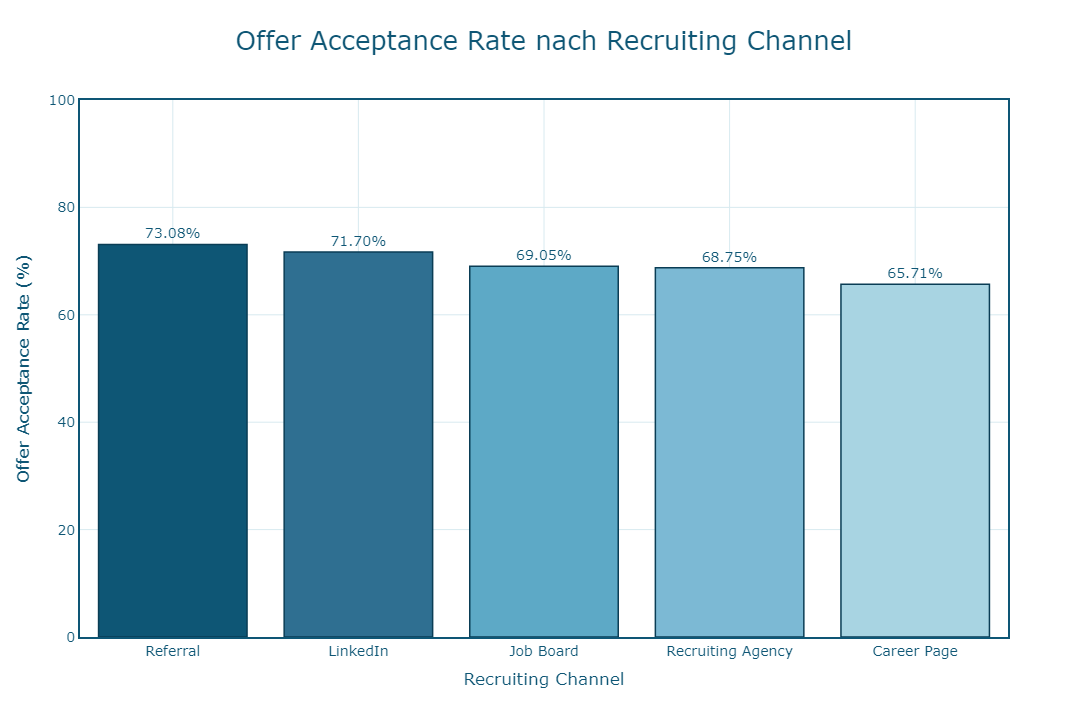

In [35]:
# Offer Acceptance Rate nach Recruiting Channel
# ==========================================================
#
# Ziel:
# Vergleich der Angebotsannahmerate zwischen den Recruiting-Kanälen.
# Die Grafik zeigt, aus welchen Kanälen Kandidaten Angebote häufiger annehmen.

# Daten für das Diagramm vorbereiten
plot_df = (
    channel_summary
    .reset_index()
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)

# Balkendiagramm erstellen
fig = px.bar(
    plot_df,
    x="channel_name",
    y="Offer Acceptance Rate",
    text="Offer Acceptance Rate",
    hover_data=[
        "Offer Made",
        "Offer Accepted",
        "Employment Started"
    ],
    color="channel_name",
    color_discrete_sequence=[
        "#0E5675",
        "#2F6F91",
        "#5DA9C6",
        "#7CB9D4",
        "#A8D4E2"
    ],
    title="Offer Acceptance Rate nach Recruiting Channel"
)



# Prozentwerte oberhalb der Balken anzeigen
fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside",
    marker_line_color="#0A3D55",
    marker_line_width=1.5
)

# Layout im einheitlichen Farbdesign gestalten
fig.update_layout(
    width=1400,
    height=700,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(
        size=14,
        color="#0E5675"
    ),
    title=dict(
        text="Offer Acceptance Rate nach Recruiting Channel",
        font=dict(
            size=26,
            color="#0E5675"
        ),
        x=0.5
    ),
    xaxis_title="Recruiting Channel",
    yaxis_title="Offer Acceptance Rate (%)",
    yaxis_range=[0, 100],
    showlegend=False
)

# Rahmen und dezente Gitternetzlinien ergänzen
fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.show()

#### 6.2.7 Interpretation Offer Acceptance Rate

**LinkedIn** liefert mit Abstand **die meisten Bewerbungen** und führt gleichzeitig zu einer überdurchschnittlichen Offer Acceptance Rate von 71,7%. Dies macht den Kanal sowohl hinsichtlich Reichweite als auch hinsichtlich der späteren Annahmewahrscheinlichkeit attraktiv.

**Die Career Page** erzielt die **höchste Offer Rate**, was darauf hindeutet, dass über diesen Kanal vergleichsweise häufig Kandidaten identifiziert werden, die die Anforderungen der Stelle erfüllen.

**Referral-Kandidaten** weisen die **höchste Offer Acceptance Rate** auf. Dies deutet darauf hin, dass Kandidaten aus Mitarbeiterempfehlungen häufiger ein Angebot annehmen als Kandidaten aus anderen Recruiting-Kanälen.

Insgesamt unterscheiden sich die Recruiting-Kanäle weniger hinsichtlich der Interviewraten als vielmehr hinsichtlich der Qualität und Abschlusswahrscheinlichkeit der Kandidaten. Die höchsten Offer Acceptance Rates werden bei Referral-Kandidaten (73,08%) und LinkedIn-Kandidaten (71,70%) beobachtet. 

Ob diese Unterschiede statistisch signifikant sind, wird im Rahmen der Hypothesenprüfung untersucht. Und anders gefragt: Ist Referral wirklich besser oder sehen wir hier nur einen kleinen Stichprobeneffekt?

### 6.3 Kandidaten-Level

Unterscheiden sich Recruiting-Erfolg und Prozesskennzahlen zwischen Junior-, Mid- und Senior-Kandidaten?

#### 6.3.1 Deskriptive Statistik

In [36]:
# Deskriptive Statistik der Time to Hire nach Kandidatenlevel
# ==========================================================
#
# Ziel:
# Vergleich der Verteilung der Time to Hire zwischen
# Junior-, Mid- und Senior-Kandidaten.
#
# Da time_to_hire keine candidate_id enthält, holen wir diese
# zuerst über die application_id aus der Faktentabelle dazu.


# ----------------------------------------------------------
# 1. Kandidaten-ID pro Bewerbung ermitteln
# ----------------------------------------------------------

application_candidates = (
    fact_candidate_events[
        ["application_id", "candidate_id"]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 2. Kandidatenlevel ergänzen
# ----------------------------------------------------------

application_levels = (
    application_candidates
    .merge(
        dim_candidate[
            ["candidate_id", "candidate_level"]
        ],
        on="candidate_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Time-to-Hire-Daten mit Kandidatenlevel verbinden
# ----------------------------------------------------------

time_to_hire_level = (
    time_to_hire
    .merge(
        application_levels[
            ["application_id", "candidate_level"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 4. Deskriptive Statistik berechnen
# ----------------------------------------------------------

level_statistics = (
    time_to_hire_level
    .groupby("candidate_level")["time_to_hire_days"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Minimum="min",
        Maximum="max",
        Skewness="skew",
        Kurtosis=pd.Series.kurt
    )
    .round(2)
    .sort_values(
        by="Mittelwert",
        ascending=False
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

level_statistics

,Anzahl,Mittelwert,Median,Standardabweichung,Minimum,Maximum,Skewness,Kurtosis
candidate_level,,,,,,,,
Senior,37,44.84,42.00,12.32,22,72,0.67,0.04
Junior,27,43.07,39.00,12.03,27,74,1.11,0.40
Mid,46,42.17,39.00,11.60,21,71,1.05,0.88


#### 6.3.2 Boxplot

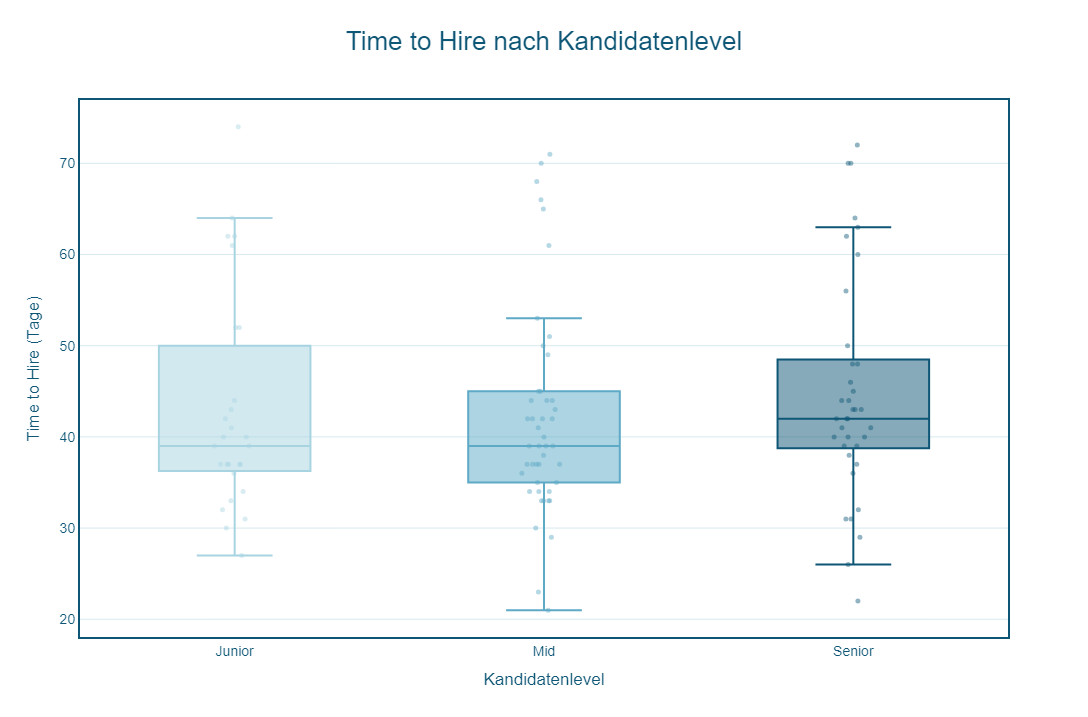

In [37]:
# Boxplot Time to Hire nach Kandidatenlevel
# Plotly Express
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen Junior-, Mid- und Senior-Kandidaten unterscheidet.
#
# Der Plotly-Boxplot zeigt:
# - Median
# - Quartile
# - Streuung
# - Ausreißer
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_3 = [
    "#A8D4E2",  # Junior
    "#5DA9C6",  # Mid
    "#0E5675"   # Senior
]


# ----------------------------------------------------------
# 2. Kandidaten-ID pro Bewerbung ermitteln
# ----------------------------------------------------------

application_candidates = (
    fact_candidate_events[
        ["application_id", "candidate_id"]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 3. Kandidatenlevel ergänzen
# ----------------------------------------------------------

application_levels = (
    application_candidates
    .merge(
        dim_candidate[
            ["candidate_id", "candidate_level"]
        ],
        on="candidate_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 4. Time-to-Hire-Daten mit Kandidatenlevel verbinden
# ----------------------------------------------------------

time_to_hire_level = (
    time_to_hire
    .merge(
        application_levels[
            ["application_id", "candidate_level"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 5. Reihenfolge der Kandidatenlevel festlegen
# ----------------------------------------------------------

level_order = ["Junior", "Mid", "Senior"]


# ----------------------------------------------------------
# 6. Boxplot erstellen
# ----------------------------------------------------------

fig = px.box(
    time_to_hire_level,
    x="candidate_level",
    y="time_to_hire_days",
    color="candidate_level",
    points="all",
    category_orders={
        "candidate_level": level_order
    },
    color_discrete_sequence=PALETTE_3,
    title="Time to Hire nach Kandidatenlevel"
)


# ----------------------------------------------------------
# 7. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.30,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 8. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Time to Hire nach Kandidatenlevel",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Kandidatenlevel",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 9. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 10. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.3.3 Violinplot

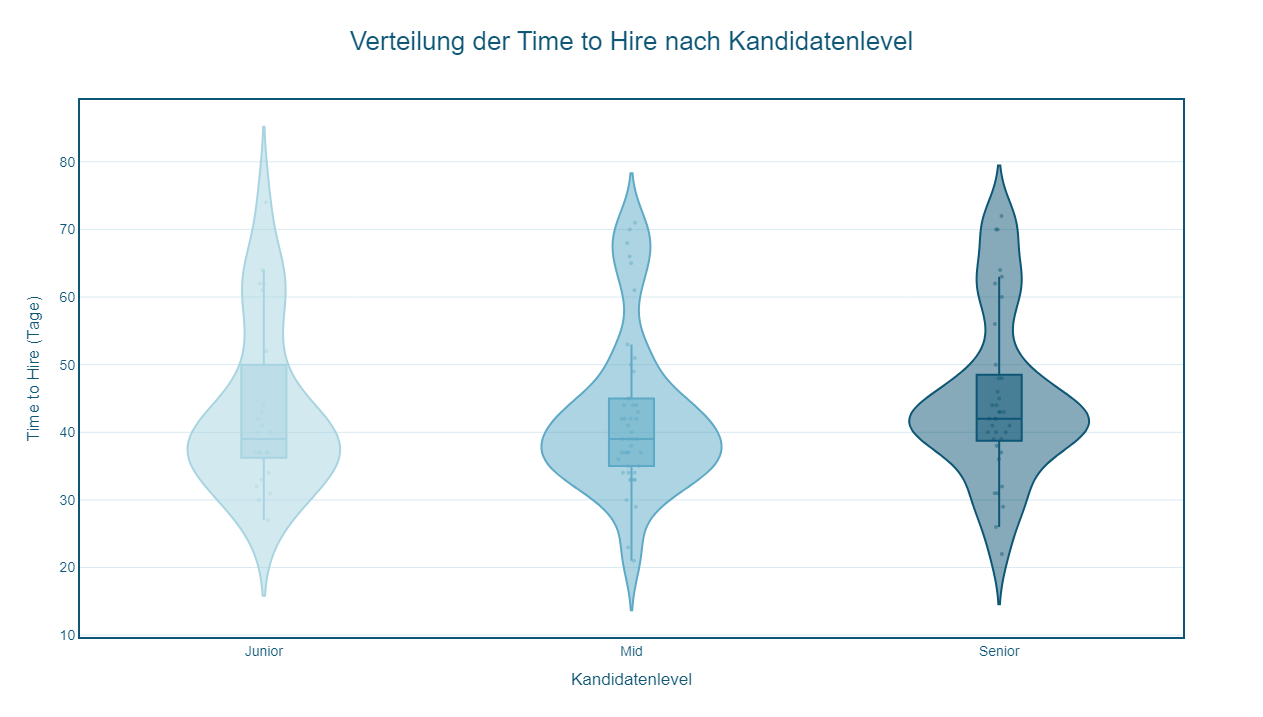

In [38]:
# Violinplot Time to Hire nach Kandidatenlevel
# Plotly Express
# ==========================================================
#
# Ziel:
# Visualisierung der Verteilung der Time to Hire
# für Junior-, Mid- und Senior-Kandidaten.
#
# Der Plotly-Violinplot zeigt:
# - Verteilungsform
# - Median
# - Quartile
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_3 = [
    "#A8D4E2",  # Junior
    "#5DA9C6",  # Mid
    "#0E5675"   # Senior
]


# ----------------------------------------------------------
# 2. Reihenfolge der Kandidatenlevel festlegen
# ----------------------------------------------------------

level_order = ["Junior", "Mid", "Senior"]


# ----------------------------------------------------------
# 3. Violinplot erstellen
# ----------------------------------------------------------

fig = px.violin(
    time_to_hire_level,
    x="candidate_level",
    y="time_to_hire_days",
    color="candidate_level",
    category_orders={
        "candidate_level": level_order
    },
    color_discrete_sequence=PALETTE_3,
    box=True,
    points="all",
    title="Verteilung der Time to Hire nach Kandidatenlevel"
)


# ----------------------------------------------------------
# 4. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.15,
    pointpos=0,
    marker=dict(
        size=4,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Verteilung der Time to Hire nach Kandidatenlevel",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Kandidatenlevel",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.3.4 Interpretation Time to Hire

Die Analyse der Time to Hire nach Kandidatenlevel zeigt insgesamt nur geringe Unterschiede zwischen Junior-, Mid- und Senior-Kandidaten. Die durchschnittliche Besetzungsdauer liegt bei Senior-Kandidaten mit 44,84 Tagen leicht über den Werten von Junior- (43,07 Tage) und Mid-Level-Kandidaten (42,17 Tage). Auch die Mediane unterscheiden sich nur geringfügig und liegen zwischen 39 und 42 Tagen.

Die Boxplots bestätigen dieses Bild. Die Verteilungen der drei Kandidatenlevel überlappen sich stark, sodass keine klaren Unterschiede zwischen den Gruppen erkennbar sind. Zwar weisen Senior-Kandidaten tendenziell etwas höhere Besetzungszeiten auf, die Abweichungen bleiben jedoch moderat. In allen Gruppen treten einzelne Ausreißer mit besonders langen Recruiting-Prozessen von über 60 Tagen auf.

Die Violinplots verdeutlichen ebenfalls, dass sich die Verteilungen sehr ähnlich sind. Der Schwerpunkt der Time-to-Hire-Werte liegt bei allen Kandidatenleveln im Bereich von etwa 35 bis 45 Tagen. Die positive Schiefe (Skewness) in allen Gruppen zeigt zudem, dass einzelne lang andauernde Besetzungsprozesse die Verteilungen nach oben ziehen.

Insgesamt deutet die explorative Analyse darauf hin, dass das Kandidatenlevel nur einen begrenzten Einfluss auf die Time to Hire besitzt. Die Unterschiede zwischen Junior-, Mid- und Senior-Kandidaten sind vergleichsweise gering und deutlich schwächer ausgeprägt als die zuvor beobachteten Unterschiede zwischen Standorten oder Fachbereichen.

#### 6.3.5 KPI Tabelle

In [39]:
# KPI-Tabelle nach Kandidatenlevel
# ==========================================================

# Ziel:
# Vergleich der Funnel-KPIs zwischen den Kandidatenleveln
# Junior, Mid und Senior.

# ----------------------------------------------------------
# 1. Kandidatenlevel pro Bewerbung ermitteln
# ----------------------------------------------------------

application_levels = (
    fact_candidate_events[
        ["application_id", "candidate_id"]
    ]
    .drop_duplicates()
    .merge(
        dim_candidate[
            ["candidate_id", "candidate_level"]
        ],
        on="candidate_id",
        how="left"
    )
)

# ----------------------------------------------------------
# 2. Hilfsfunktion:
# Anzahl Bewerbungen je Event und Kandidatenlevel
# ----------------------------------------------------------

def count_event_by_level(event_type):

    event_applications = (
        fact_candidate_events[
            fact_candidate_events["event_type"] == event_type
        ][["application_id"]]
        .drop_duplicates()
    )

    event_with_level = event_applications.merge(
        application_levels,
        on="application_id",
        how="left"
    )

    return (
        event_with_level
        .groupby("candidate_level")["application_id"]
        .nunique()
    )


# ----------------------------------------------------------
# 3. Funnel-Stufen zählen
# ----------------------------------------------------------

level_summary = pd.DataFrame({
    "Applications": count_event_by_level("Application Received"),
    "Interview Invited": count_event_by_level("Interview Invited"),
    "Interview Completed": count_event_by_level("Interview Completed"),
    "Offer Made": count_event_by_level("Offer Made"),
    "Offer Accepted": count_event_by_level("Offer Accepted"),
    "Employment Started": count_event_by_level("Employment Started")
})

level_summary = level_summary.fillna(0)

# ----------------------------------------------------------
# 4. Funnel-KPIs berechnen
# ----------------------------------------------------------

level_summary["Interview Invitation Rate"] = (
    level_summary["Interview Invited"] / level_summary["Applications"] * 100
)

level_summary["Interview Completion Rate"] = (
    level_summary["Interview Completed"] / level_summary["Interview Invited"] * 100
)

level_summary["Offer Rate"] = (
    level_summary["Offer Made"] / level_summary["Interview Completed"] * 100
)

level_summary["Offer Acceptance Rate"] = (
    level_summary["Offer Accepted"] / level_summary["Offer Made"] * 100
)

level_summary["Employment Start Rate"] = (
    level_summary["Employment Started"] / level_summary["Offer Accepted"] * 100
)

# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

level_summary = (
    level_summary
    .round(2)
    .sort_values(by="Offer Acceptance Rate", ascending=False)
)

display(level_summary)

,Applications,Interview Invited,Interview Completed,Offer Made,Offer Accepted,Employment Started,Interview Invitation Rate,Interview Completion Rate,Offer Rate,Offer Acceptance Rate,Employment Start Rate
candidate_level,,,,,,,,,,,
Senior,1869,357,322,52,38,37,19.10,90.20,16.15,73.08,97.37
Mid,3365,615,555,77,54,46,18.28,90.24,13.87,70.13,85.19
Junior,2266,378,345,43,28,27,16.68,91.27,12.46,65.12,96.43


#### 6.3.6 Balkendiagramm

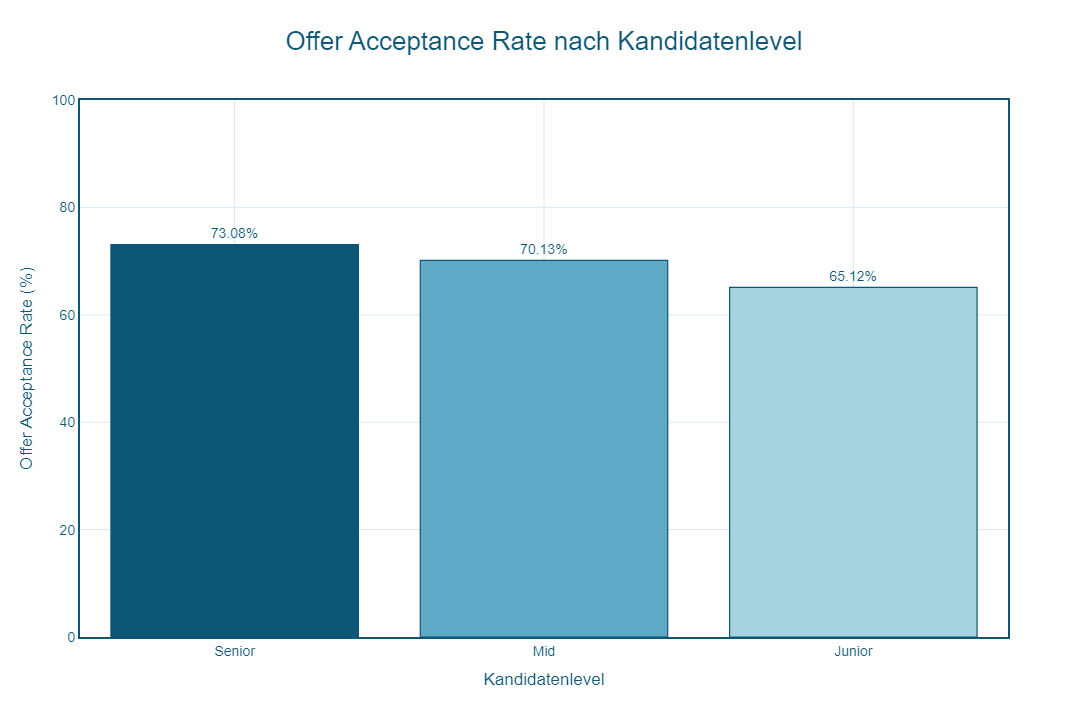

In [40]:
# Offer Acceptance Rate nach Kandidatenlevel
# Plotly Express
# ==========================================================

# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"


# ----------------------------------------------------------
# 2. DataFrame für Plotly vorbereiten
# ----------------------------------------------------------

plot_df = (
    level_summary
    .reset_index()
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)


# ----------------------------------------------------------
# 3. Balkendiagramm erstellen
# ----------------------------------------------------------
#
# Die Farben werden fest je Kandidatenlevel zugeordnet:
# Junior = hell
# Mid = mittel
# Senior = dunkel

fig = px.bar(
    plot_df,
    x="candidate_level",
    y="Offer Acceptance Rate",
    text="Offer Acceptance Rate",
    title="Offer Acceptance Rate nach Kandidatenlevel",
    labels={
        "candidate_level": "Kandidatenlevel",
        "Offer Acceptance Rate": "Offer Acceptance Rate (%)"
    },
    color="candidate_level",
    color_discrete_map={
        "Junior": "#A8D4E2",
        "Mid": "#5DA9C6",
        "Senior": "#0E5675"
    },
    category_orders={
        "candidate_level": ["Senior", "Mid", "Junior"]
    }
)


# ----------------------------------------------------------
# 4. Werte auf den Balken formatieren
# ----------------------------------------------------------

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside",
    marker_line_color=PRIMARY,
    marker_line_width=1.2
)


# ----------------------------------------------------------
# 5. Layout anpassen
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),
    title=dict(
        text="Offer Acceptance Rate nach Kandidatenlevel",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),
    xaxis_title="Kandidatenlevel",
    yaxis_title="Offer Acceptance Rate (%)",
    yaxis_range=[0, 100],
    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien ergänzen
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.3.7 Interpretation Offer Acceptance Rate

Die KPI-Tabelle zeigt Unterschiede entlang des Recruiting-Funnels für Junior-, Mid- und Senior-Kandidaten.

**Senior-Kandidaten** weisen über nahezu alle Funnel-Stufen die höchsten Erfolgsraten auf. Die Interview Invitation Rate liegt mit 19,10% am höchsten, ebenso die Offer Rate (16,15%) und die Offer Acceptance Rate (73,08%). Dies deutet darauf hin, dass Senior-Kandidaten nach einer Bewerbung häufiger zu Interviews eingeladen werden, häufiger ein Angebot erhalten und dieses auch häufiger annehmen.

**Mid-Level-Kandidaten** liegen bei den meisten Kennzahlen im Mittelfeld. Sie stellen die größte Bewerbergruppe dar und erreichen eine Offer Acceptance Rate von 70,13%. Die Funnel-Raten unterscheiden sich nur moderat von den Senior-Kandidaten.

**Junior-Kandidaten** weisen die niedrigsten Erfolgsraten im Recruiting-Prozess auf. Sowohl die Interview Invitation Rate (16,68%) als auch die Offer Rate (12,46%) und die Offer Acceptance Rate (65,12%) liegen unter den Werten der anderen Kandidatenlevel. Dies könnte darauf hindeuten, dass Junior-Kandidaten häufiger den Auswahlprozess nicht erfolgreich durchlaufen oder dass die Anforderungen der ausgeschriebenen Positionen stärker selektieren.

Die Interview Completion Rate liegt bei allen drei Gruppen auf einem sehr ähnlichen Niveau von rund 90%. Daraus lässt sich schließen, dass eingeladene Kandidaten unabhängig vom Erfahrungsniveau mit vergleichbarer Wahrscheinlichkeit am Interview teilnehmen.

Insgesamt deutet die explorative Analyse darauf hin, dass das Kandidatenlevel einen Einfluss auf den Erfolg im Recruiting-Funnel haben könnte. Insbesondere bei der Offer Rate und der Offer Acceptance Rate zeigen sich systematische Unterschiede zwischen Junior-, Mid- und Senior-Kandidaten. Ob diese Unterschiede statistisch signifikant sind, wird in den anschließenden Hypothesentests untersucht.

### 6.4 Arbeitsmodell

Hat das angebotene Arbeitsmodell (hybrid, onsite, remote) einen Einfluss auf den Recruiting-Erfolg und die Prozessgeschwindigkeit?

#### 6.4.1 Deskriptive Statistik Time to Hire

In [41]:
# Deskriptive Statistik der Time to Hire nach Arbeitsmodell
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen den Arbeitsmodellen unterscheidet.
#
# Berechnet werden:
# - Anzahl
# - Mittelwert
# - Median
# - Standardabweichung
# - Minimum
# - Maximum
# - Skewness
# - Kurtosis


# ----------------------------------------------------------
# 1. Arbeitsmodell pro Bewerbung ermitteln
# ----------------------------------------------------------

application_work_model = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 2. Arbeitsmodell aus der Job-Dimension ergänzen
# ----------------------------------------------------------

application_work_model = (
    application_work_model
    .merge(
        dim_job[
            ["job_id", "remote_option"]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Time-to-Hire-Daten mit Arbeitsmodell verbinden
# ----------------------------------------------------------

time_to_hire_work_model = (
    time_to_hire
    .merge(
        application_work_model[
            ["application_id", "remote_option"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 4. Deskriptive Statistik berechnen
# ----------------------------------------------------------

work_model_statistics = (
    time_to_hire_work_model
    .groupby("remote_option")["time_to_hire_days"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Minimum="min",
        Maximum="max",
        Skewness="skew",
        Kurtosis=pd.Series.kurt
    )
    .round(2)
    .sort_values(
        by="Mittelwert",
        ascending=False
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

display(work_model_statistics)

,Anzahl,Mittelwert,Median,Standardabweichung,Minimum,Maximum,Skewness,Kurtosis
remote_option,,,,,,,,
Remote,32,45.00,42.00,13.19,21,74,0.69,0.14
Hybrid,43,43.40,42.00,11.40,26,70,0.90,0.28
Onsite,35,41.60,39.00,11.37,23,72,1.18,0.84


#### 6.4.2 Boxplot Time to Hire

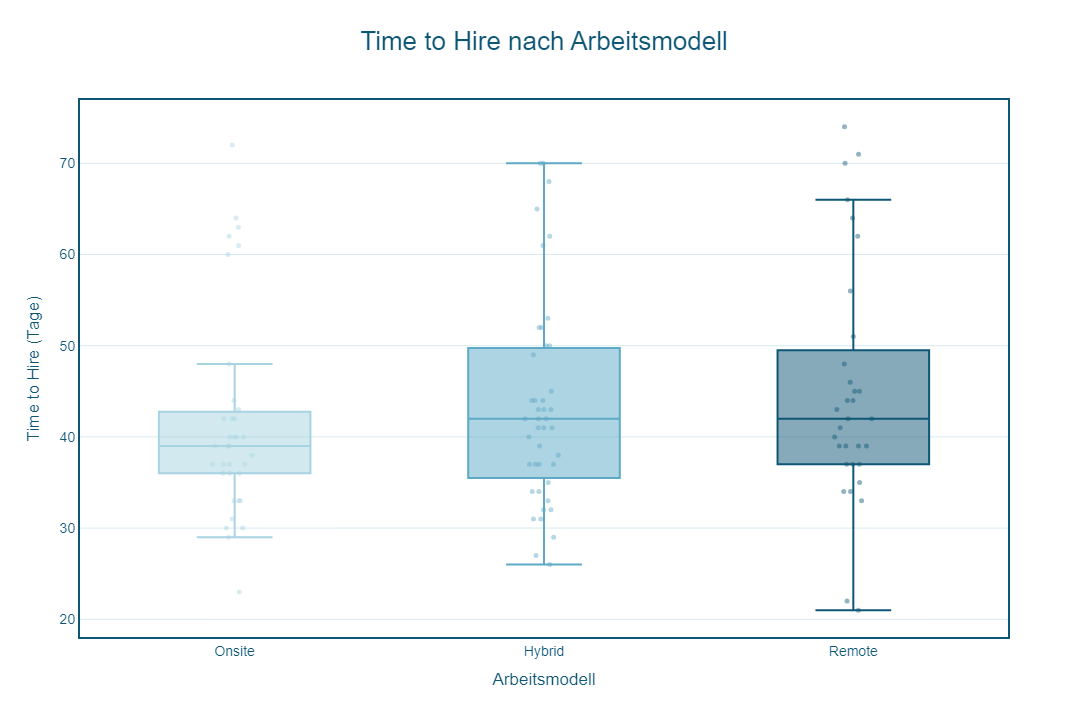

In [42]:
# Boxplot Time to Hire nach Arbeitsmodell
# Plotly Express
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen den Arbeitsmodellen unterscheidet.
#
# Der Plotly-Boxplot zeigt:
# - Median
# - Quartile
# - Streuung
# - Ausreißer
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

WORK_MODEL_COLORS = {
    "Onsite": "#A8D4E2",
    "Hybrid": "#5DA9C6",
    "Remote": "#0E5675"
}


# ----------------------------------------------------------
# 2. Job-ID je Bewerbung ermitteln
# ----------------------------------------------------------

application_jobs = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 3. Arbeitsmodell aus der Job-Dimension ergänzen
# ----------------------------------------------------------

application_work_model = (
    application_jobs
    .merge(
        dim_job[
            ["job_id", "remote_option"]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 4. Time-to-Hire-Daten mit Arbeitsmodell verbinden
# ----------------------------------------------------------

time_to_hire_work_model = (
    time_to_hire
    .merge(
        application_work_model[
            ["application_id", "remote_option"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 5. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

work_model_order = (
    time_to_hire_work_model
    .groupby("remote_option")["time_to_hire_days"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 6. Boxplot erstellen
# ----------------------------------------------------------

fig = px.box(
    time_to_hire_work_model,
    x="remote_option",
    y="time_to_hire_days",
    color="remote_option",
    points="all",
    category_orders={
        "remote_option": work_model_order
    },
    color_discrete_map=WORK_MODEL_COLORS,
    title="Time to Hire nach Arbeitsmodell"
)


# ----------------------------------------------------------
# 7. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.30,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 8. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Time to Hire nach Arbeitsmodell",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Arbeitsmodell",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 9. Rahmen und Gitternetzlinien ergänzen
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 10. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.4.3 Violinplot

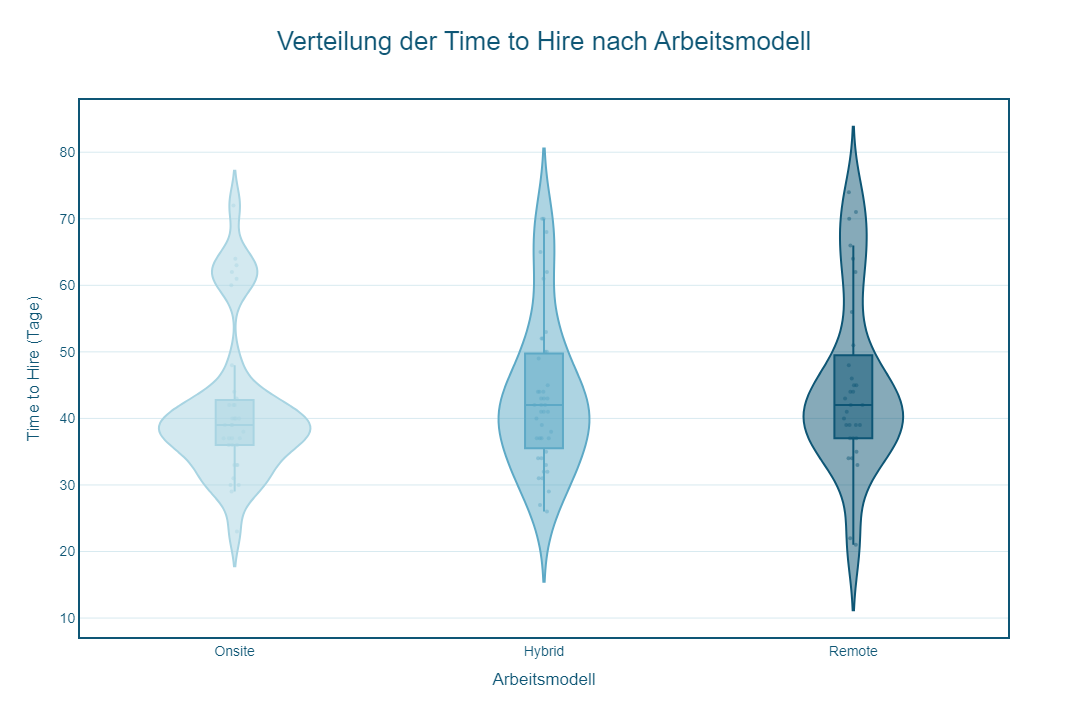

In [43]:
# Violinplot Time to Hire nach Arbeitsmodell
# Plotly Express
# ==========================================================
#
# Ziel:
# Darstellung der Verteilung der Time to Hire
# für die verschiedenen Arbeitsmodelle.
#
# Der Plotly-Violinplot zeigt:
# - Verteilungsform
# - Median
# - Quartile
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

WORK_MODEL_COLORS = {
    "Onsite": "#A8D4E2",
    "Hybrid": "#5DA9C6",
    "Remote": "#0E5675"
}


# ----------------------------------------------------------
# 2. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

work_model_order = (
    time_to_hire_work_model
    .groupby("remote_option")["time_to_hire_days"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Violinplot erstellen
# ----------------------------------------------------------

fig = px.violin(
    time_to_hire_work_model,
    x="remote_option",
    y="time_to_hire_days",
    color="remote_option",
    category_orders={
        "remote_option": work_model_order
    },
    color_discrete_map=WORK_MODEL_COLORS,
    box=True,
    points="all",
    title="Verteilung der Time to Hire nach Arbeitsmodell"
)


# ----------------------------------------------------------
# 4. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.15,
    pointpos=0,
    marker=dict(
        size=4,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,
    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Verteilung der Time to Hire nach Arbeitsmodell",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Arbeitsmodell",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien ergänzen
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.4.4 Interpretation Time to Hire

Die Analyse der Time to Hire nach Arbeitsmodell zeigt insgesamt nur moderate Unterschiede zwischen den drei Kategorien. Remote-Stellen weisen mit durchschnittlich 45 Tagen die längste Time to Hire auf, gefolgt von Hybrid-Stellen mit rund 43 Tagen. Onsite-Positionen werden mit durchschnittlich 42 Tagen am schnellsten besetzt.

Die Boxplots verdeutlichen, dass sich die Medianwerte nur geringfügig unterscheiden (Onsite: 39 Tage, Hybrid und Remote: jeweils 42 Tage). Gleichzeitig zeigen Remote- und Hybrid-Positionen eine größere Streuung der Prozessdauer als reine Onsite-Stellen. Dies deutet darauf hin, dass die Besetzungszeiten bei diesen Arbeitsmodellen weniger konsistent verlaufen.

Die Violinplots bestätigen dieses Bild. Bei allen drei Arbeitsmodellen konzentrieren sich die meisten Einstellungen im Bereich zwischen etwa 35 und 45 Tagen. Remote- und Hybrid-Stellen weisen jedoch breitere Verteilungen sowie mehr sehr lange Besetzungszeiten auf, während Onsite-Stellen insgesamt homogener verteilt sind.

Auch die Schiefe der Verteilungen (Skewness > 0) zeigt, dass in allen Arbeitsmodellen einzelne Bewerbungsprozesse deutlich länger dauern als der typische Fall. Dieser Effekt ist bei Onsite-Stellen am stärksten ausgeprägt. Die positiven Kurtosis-Werte deuten zusätzlich auf etwas stärkere Randbereiche und vereinzelte Extremwerte hin.

Insgesamt sprechen die Ergebnisse dafür, dass das Arbeitsmodell zwar einen gewissen Einfluss auf die Prozessdauer haben könnte, die Unterschiede jedoch deutlich geringer ausfallen als beispielsweise zwischen einzelnen Standorten oder Recruiting Channels. Ob die beobachteten Abweichungen statistisch signifikant sind, wird im Rahmen der Hypothesentests geprüft.

#### 6.4.5 KPI Tabelle

In [44]:
# KPI-Tabelle nach Arbeitsmodell
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich der Recruiting-Erfolg
# zwischen den Arbeitsmodellen Onsite, Hybrid und Remote unterscheidet.
#
# Dafür wird je Bewerbung das Arbeitsmodell ergänzt.
# Anschließend werden die Funnel-Stufen und daraus die KPI-Raten berechnet.


# ----------------------------------------------------------
# 1. Arbeitsmodell pro Bewerbung ermitteln
# ----------------------------------------------------------
#
# Die Faktentabelle enthält pro Bewerbung die job_id.
# Über die job_id können wir aus dim_job das Arbeitsmodell holen.

application_work_model = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
    .merge(
        dim_job[
            ["job_id", "remote_option"]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 2. Eventdaten mit Arbeitsmodell verbinden
# ----------------------------------------------------------
#
# Dadurch weiß jede Eventzeile, zu welchem Arbeitsmodell
# die jeweilige Bewerbung gehört.

events_work_model = (
    fact_candidate_events
    .merge(
        application_work_model[
            ["application_id", "remote_option"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Hilfsfunktion zur Zählung je Eventtyp
# ----------------------------------------------------------
#
# Die Funktion zählt, wie viele eindeutige Bewerbungen
# je Arbeitsmodell einen bestimmten Prozessschritt erreicht haben.

def count_event_by_work_model(event_type):

    return (
        events_work_model[
            events_work_model["event_type"] == event_type
        ]
        .groupby("remote_option")["application_id"]
        .nunique()
    )


# ----------------------------------------------------------
# 4. Funnel-Stufen je Arbeitsmodell zählen
# ----------------------------------------------------------

work_model_summary = pd.DataFrame({
    "Applications": count_event_by_work_model("Application Received"),
    "Interview Invited": count_event_by_work_model("Interview Invited"),
    "Interview Completed": count_event_by_work_model("Interview Completed"),
    "Offer Made": count_event_by_work_model("Offer Made"),
    "Offer Accepted": count_event_by_work_model("Offer Accepted"),
    "Employment Started": count_event_by_work_model("Employment Started")
})


# ----------------------------------------------------------
# 5. Fehlende Werte auffüllen
# ----------------------------------------------------------
#
# Falls ein Arbeitsmodell in einer Funnel-Stufe nicht vorkommt,
# entsteht zunächst ein fehlender Wert.
# Dieser wird hier auf 0 gesetzt.

work_model_summary = work_model_summary.fillna(0)


# ----------------------------------------------------------
# 6. KPI-Raten berechnen
# ----------------------------------------------------------

work_model_summary["Interview Invitation Rate"] = (
    work_model_summary["Interview Invited"]
    / work_model_summary["Applications"]
    * 100
)

work_model_summary["Interview Completion Rate"] = (
    work_model_summary["Interview Completed"]
    / work_model_summary["Interview Invited"]
    * 100
)

work_model_summary["Offer Rate"] = (
    work_model_summary["Offer Made"]
    / work_model_summary["Interview Completed"]
    * 100
)

work_model_summary["Offer Acceptance Rate"] = (
    work_model_summary["Offer Accepted"]
    / work_model_summary["Offer Made"]
    * 100
)

work_model_summary["Employment Start Rate"] = (
    work_model_summary["Employment Started"]
    / work_model_summary["Offer Accepted"]
    * 100
)


# ----------------------------------------------------------
# 7. Ergebnis formatieren und anzeigen
# ----------------------------------------------------------

work_model_summary = (
    work_model_summary
    .round(2)
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)

display(work_model_summary)

,Applications,Interview Invited,Interview Completed,Offer Made,Offer Accepted,Employment Started,Interview Invitation Rate,Interview Completion Rate,Offer Rate,Offer Acceptance Rate,Employment Start Rate
remote_option,,,,,,,,,,,
Hybrid,3103,569,515,59,46,43,18.34,90.51,11.46,77.97,93.48
Remote,2143,397,363,54,37,32,18.53,91.44,14.88,68.52,86.49
Onsite,2254,384,344,59,37,35,17.04,89.58,17.15,62.71,94.59


#### 6.4.6 Balkendiagramm

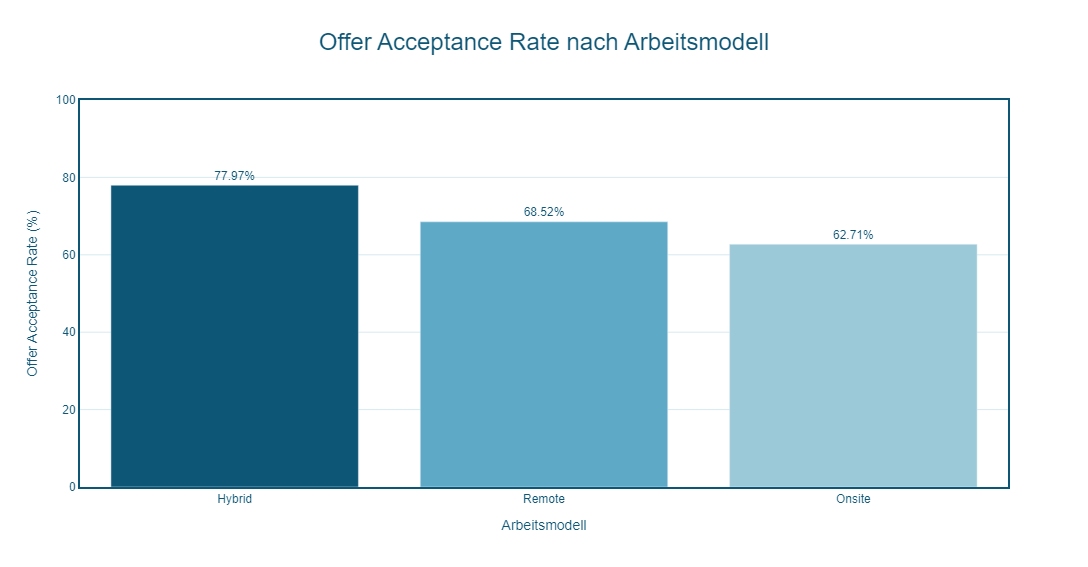

In [45]:
# Offer Acceptance Rate nach Arbeitsmodell
# Balkendiagramm
# ==========================================================

# Ziel:
# Vergleich der Offer Acceptance Rate zwischen
# Onsite-, Hybrid- und Remote-Stellen.
#
# Die Kennzahl zeigt:
# Wie viele Kandidaten ein erhaltenes Angebot
# tatsächlich angenommen haben.


# ----------------------------------------------------------
# 1. Daten für Plotly vorbereiten
# ----------------------------------------------------------

plot_df = (
    work_model_summary
    .reset_index()
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)


# ----------------------------------------------------------
# 2. Balkendiagramm erstellen
# ----------------------------------------------------------

fig = px.bar(
    plot_df,
    x="remote_option",
    y="Offer Acceptance Rate",
    text="Offer Acceptance Rate",
    color="remote_option",
    color_discrete_map={
        "Hybrid": "#0E5675",
        "Remote": "#5DA9C6",
        "Onsite": "#9CC9D8"
    },
    title="Offer Acceptance Rate nach Arbeitsmodell"
)


# ----------------------------------------------------------
# 3. Prozentwerte auf den Balken anzeigen
# ----------------------------------------------------------

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside"
)


# ----------------------------------------------------------
# 4. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1100,
    height=550,

    plot_bgcolor="white",
    paper_bgcolor="white",

    title={
        "text": "Offer Acceptance Rate nach Arbeitsmodell",
        "x": 0.5,
        "font": {
            "size": 24,
            "color": "#0E5675"
        }
    },

    xaxis_title="Arbeitsmodell",
    yaxis_title="Offer Acceptance Rate (%)",

    yaxis=dict(
        range=[0, 100],
        gridcolor="#D7E8EF"
    ),

    xaxis=dict(
        showgrid=False
    ),

    font=dict(
        family="Arial",
        size=12,
        color="#0E5675"
    ),

    showlegend=False
)

# ----------------------------------------------------------
# 5. Rahmen um das Diagramm ergänzen
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)

# ----------------------------------------------------------
# 6. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.4.7 Interpretation

Die KPI-Tabelle zeigt deutliche Unterschiede zwischen den drei Arbeitsmodellen. Besonders auffällig ist die **Offer Acceptance Rate**, die bei **Hybrid-Stellen mit 77,97%** deutlich höher ausfällt als bei **Remote-Stellen (68,52%)** und **Onsite-Stellen (62,71%)**.

Gleichzeitig unterscheiden sich die vorgelagerten Funnel-Stufen nur geringfügig. Die **Interview Invitation Rate** liegt bei allen drei Arbeitsmodellen zwischen **17,04%** und **18,53%**, ebenso die **Interview Completion Rate** mit Werten zwischen **89,58%** und **91,44%**. Die Unterschiede entstehen daher vor allem in der Phase zwischen **Angebotserstellung** und **Angebotsannahme**.

Interessant ist zudem, dass **Onsite-Stellen zwar die höchste Offer Rate (17,15%)** aufweisen und somit nach dem Interview häufiger zu einem Angebot führen, die Kandidaten diese Angebote jedoch am seltensten annehmen. **Hybrid-Stellen** zeigen dagegen die höchste Akzeptanz der ausgesprochenen Angebote.

Dies deutet darauf hin, dass das angebotene **Arbeitsmodell** einen relevanten Einfluss auf die Attraktivität einer Position haben könnte. Die Ergebnisse sprechen dafür, dass **Hybrid-Arbeit** für viele Kandidaten einen guten Kompromiss zwischen Flexibilität und persönlicher Zusammenarbeit darstellt und daher die höchste Angebotsannahme erzielt.

Die Ergebnisse liefern erste Hinweise darauf, dass **Hybrid-Arbeit** für Kandidaten besonders attraktiv sein könnte. Ob die beobachteten Unterschiede statistisch signifikant sind, sollte in einem nachfolgenden Hypothesentest überprüft werden.

### 6.5 Fachbereiche

Hat der Fachbereich Einfluss auf die Time-to-Hire und die Offer Acceptance Rate?

#### 6.5.1 Deskriptive Statistik

In [46]:
# Deskriptive Statistik der Time to Hire nach Fachbereich
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen den Fachbereichen unterscheidet.
#
# Da time_to_hire keine job_id enthält, wird der Fachbereich
# über zwei Zwischenschritte ergänzt:
#
# 1. application_id → job_id
# 2. job_id → department


# ----------------------------------------------------------
# 1. Job-ID pro Bewerbung ermitteln
# ----------------------------------------------------------
#
# Die Faktentabelle enthält je Bewerbung die zugehörige job_id.
# Da pro Bewerbung mehrere Events existieren, entfernen wir
# doppelte Kombinationen mit drop_duplicates().

application_jobs = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 2. Fachbereich zur Bewerbung ergänzen
# ----------------------------------------------------------
#
# Über dim_job wird aus der job_id der zugehörige Fachbereich.

application_departments = (
    application_jobs
    .merge(
        dim_job[
            ["job_id", "department"]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Time-to-Hire-Daten mit Fachbereich verbinden
# ----------------------------------------------------------
#
# time_to_hire enthält die berechnete Dauer je Bewerbung.
# Über application_id ergänzen wir den Fachbereich.

time_to_hire_department = (
    time_to_hire
    .merge(
        application_departments[
            ["application_id", "department"]
        ],
        on="application_id",
        how="left"
    )
)

# ----------------------------------------------------------
# 4. Deskriptive Statistik berechnen
# ----------------------------------------------------------

department_stats = (
    time_to_hire_department
    .groupby("department")["time_to_hire_days"]
    .agg(
        Anzahl="count",
        Mittelwert="mean",
        Median="median",
        Standardabweichung="std",
        Minimum="min",
        Maximum="max",
        Skewness="skew",
        Kurtosis="kurt"
    )
    .round(2)
    .sort_values(
        by="Mittelwert",
        ascending=False
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

department_stats

,Anzahl,Mittelwert,Median,Standardabweichung,Minimum,Maximum,Skewness,Kurtosis
department,,,,,,,,
Marketing,12,49.00,44.50,13.19,30,70,0.39,-1.01
Sales,18,47.22,41.50,14.01,31,71,0.74,-1.05
Finance,11,44.64,45.00,14.50,22,66,-0.16,-0.61
Data,20,43.95,41.50,12.52,27,74,1.00,0.45
IT,19,41.58,40.00,11.15,21,72,1.15,2.70
Operations,16,39.38,37.00,8.44,31,62,1.54,2.44
HR,14,38.14,39.00,5.72,26,50,-0.22,1.35


#### 6.5.2 Boxplot Time to Hire

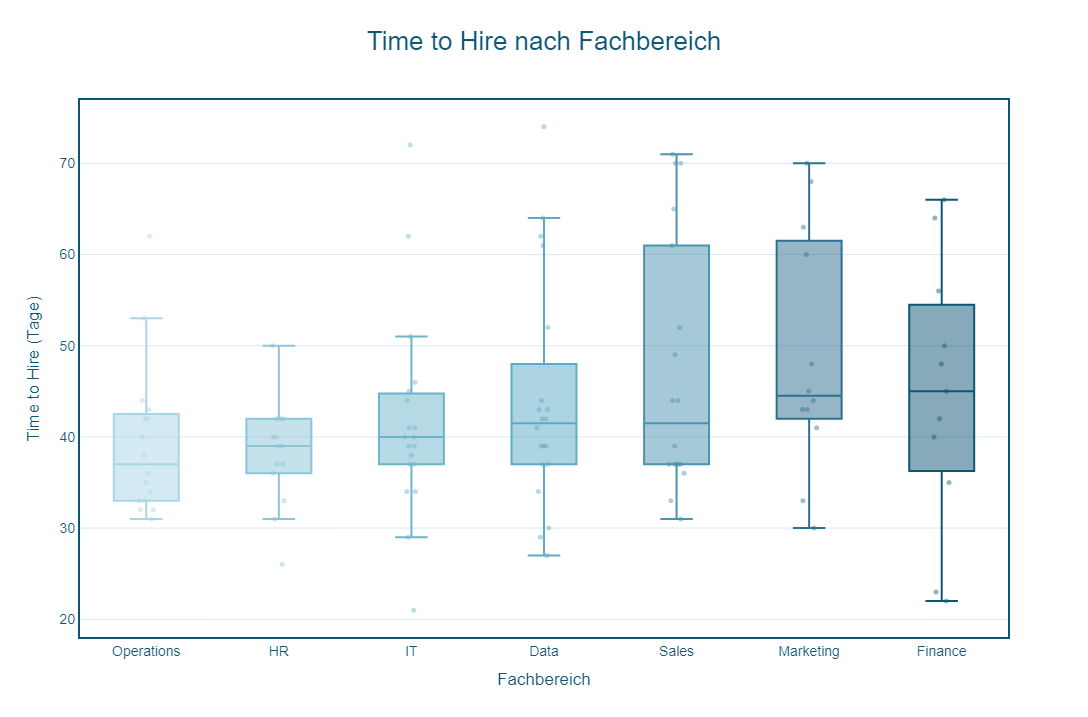

In [47]:
# Boxplot Time to Hire nach Fachbereich
# Plotly Express
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer des Recruiting-Prozesses
# zwischen den Fachbereichen unterscheidet.
#
# Der Plotly-Boxplot zeigt:
# - Median
# - Quartile
# - Streuung
# - Ausreißer
# - Einzelwerte


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_7 = [
    "#A9D6E5",
    "#8CC5D9",
    "#6FB4CD",
    "#5DA9C6",
    "#4C93B2",
    "#2F6F91",
    "#0E5675"
]


# ----------------------------------------------------------
# 2. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

department_order = (
    time_to_hire_department
    .groupby("department")["time_to_hire_days"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Boxplot erstellen
# ----------------------------------------------------------

fig = px.box(
    time_to_hire_department,
    x="department",
    y="time_to_hire_days",
    color="department",
    points="all",
    category_orders={
        "department": department_order
    },
    color_discrete_sequence=PALETTE_7,
    title="Time to Hire nach Fachbereich"
)


# ----------------------------------------------------------
# 4. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.30,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Time to Hire nach Fachbereich",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Fachbereich",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.5.3 Violinplot

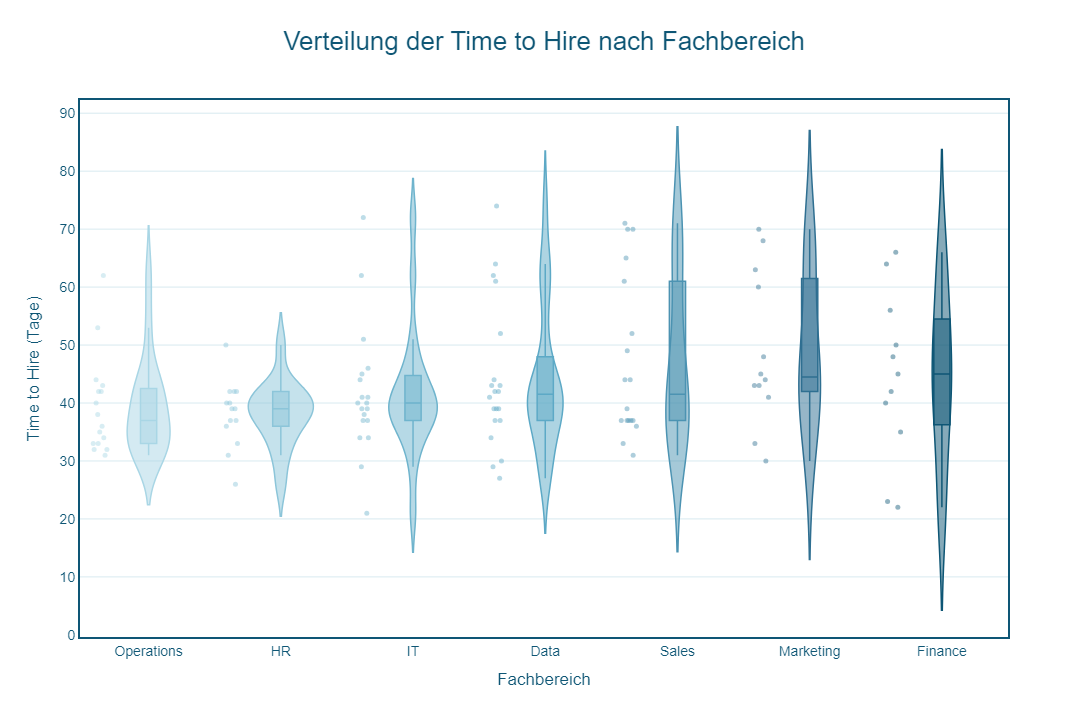

In [48]:
# Violinplot Time to Hire nach Fachbereich
# Plotly Express
# ==========================================================

import plotly.express as px


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

PALETTE_7 = [
    "#A9D6E5",
    "#8CC5D9",
    "#6FB4CD",
    "#5DA9C6",
    "#4C93B2",
    "#2F6F91",
    "#0E5675"
]


# ----------------------------------------------------------
# 2. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

department_order = (
    time_to_hire_department
    .groupby("department")["time_to_hire_days"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Violinplot erstellen
# ----------------------------------------------------------

fig = px.violin(
    time_to_hire_department,
    x="department",
    y="time_to_hire_days",
    color="department",
    category_orders={
        "department": department_order
    },
    color_discrete_sequence=PALETTE_7,
    box=True,          # Boxplot innerhalb der Violine
    points="all",      # Einzelwerte anzeigen
    title="Verteilung der Time to Hire nach Fachbereich"
)


# ----------------------------------------------------------
# 4. Transparenz der Einzelpunkte
# ----------------------------------------------------------

fig.update_traces(
    marker=dict(
        size=5,
        opacity=0.45
    ),
    line=dict(width=1.5)
)


# ----------------------------------------------------------
# 5. Layout im Projektdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Verteilung der Time to Hire nach Fachbereich",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Fachbereich",
    yaxis_title="Time to Hire (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetz
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.5.4 Interpretation Time to Hire

Die Analyse zeigt deutliche Unterschiede der Time to Hire zwischen den Fachbereichen. Die längsten durchschnittlichen Besetzungszeiten weisen Marketing (49,0 Tage) und Sales (47,2 Tage) auf, während HR (38,1 Tage) und Operations (39,4 Tage) die kürzesten Time-to-Hire-Werte erzielen.

Die Boxplots verdeutlichen, dass sich die Medianwerte zwischen den Fachbereichen zwar unterscheiden, die Verteilungen jedoch teilweise überlappen. Besonders Sales, Marketing und Finance weisen eine größere Streuung auf, was auf unterschiedlich komplexe oder schwer zu besetzende Positionen hindeuten könnte. HR zeigt dagegen die geringste Streuung und damit einen vergleichsweise stabilen Recruiting-Prozess.

Die Violinplots bestätigen dieses Bild. In HR und Operations konzentrieren sich die meisten Einstellungen auf einen relativ engen Bereich zwischen etwa 35 und 40 Tagen. In Sales, Marketing und Finance sind die Verteilungen deutlich breiter, wodurch sowohl sehr schnelle als auch deutlich längere Besetzungen auftreten. Zudem sind in mehreren Fachbereichen längere Verteilungsschwänze und einzelne hohe Werte sichtbar.

Die Skewness-Werte zeigen überwiegend rechtsschiefe Verteilungen. Besonders Operations (1,54), IT (1,15) und Data (1,00) weisen einzelne Fälle mit deutlich längeren Besetzungszeiten auf, die den Durchschnitt nach oben ziehen. Finance (-0,16) und HR (-0,22) zeigen dagegen eine nahezu symmetrische Verteilung.

Auch die Kurtosis-Werte unterscheiden sich deutlich. IT (2,70), Operations (2,44) und HR (1,35) weisen eine stärker ausgeprägte Wölbung mit auffälligeren Extremwerten auf. Marketing (-1,01) und Sales (-1,05) zeigen dagegen eher flache Verteilungen, bei denen sich die Werte breiter über den gesamten Wertebereich verteilen.

Insgesamt deuten die Ergebnisse darauf hin, dass der Fachbereich einen Einfluss auf die Dauer des Recruiting-Prozesses haben könnte. Die Unterschiede betreffen sowohl die durchschnittliche Time to Hire als auch die Streuung und Form der Verteilungen.

#### 6.5.5 KPI Tabelle

In [49]:
# KPI-Tabelle nach Fachbereich
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Funnel-Kennzahlen
# zwischen den Fachbereichen unterscheiden.
#
# Analysiert werden:
# - Bewerbungen
# - Intervieweinladungen
# - Interviews
# - Angebote
# - Angebotsannahmen
# - Einstellungen
#
# Zusätzlich werden die wichtigsten
# Recruiting-Raten berechnet.


# ----------------------------------------------------------
# 1. Fachbereich pro Bewerbung ermitteln
# ----------------------------------------------------------

application_department = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
    .merge(
        dim_job[
            ["job_id", "department"]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 2. Eventdaten mit Fachbereich verbinden
# ----------------------------------------------------------

department_events = (
    fact_candidate_events
    .merge(
        application_department,
        on=["application_id", "job_id"],
        how="left"
    )
)


# ----------------------------------------------------------
# 3. KPI-Tabelle aufbauen
# ----------------------------------------------------------

department_summary = []

for department in sorted(
    department_events["department"].dropna().unique()
):

    subset = department_events[
        department_events["department"] == department
    ]

    applications = subset["application_id"].nunique()

    interview_invited = (
        subset[
            subset["event_type"]
            == "Interview Invited"
        ]["application_id"]
        .nunique()
    )

    interview_completed = (
        subset[
            subset["event_type"]
            == "Interview Completed"
        ]["application_id"]
        .nunique()
    )

    offer_made = (
        subset[
            subset["event_type"]
            == "Offer Made"
        ]["application_id"]
        .nunique()
    )

    offer_accepted = (
        subset[
            subset["event_type"]
            == "Offer Accepted"
        ]["application_id"]
        .nunique()
    )

    employment_started = (
        subset[
            subset["event_type"]
            == "Employment Started"
        ]["application_id"]
        .nunique()
    )

    department_summary.append({
        "Department": department,
        "Applications": applications,
        "Interview Invited": interview_invited,
        "Interview Completed": interview_completed,
        "Offer Made": offer_made,
        "Offer Accepted": offer_accepted,
        "Employment Started": employment_started,

        "Interview Invitation Rate":
            round(interview_invited / applications * 100, 2)
            if applications else 0,

        "Interview Completion Rate":
            round(interview_completed / interview_invited * 100, 2)
            if interview_invited else 0,

        "Offer Rate":
            round(offer_made / interview_completed * 100, 2)
            if interview_completed else 0,

        "Offer Acceptance Rate":
            round(offer_accepted / offer_made * 100, 2)
            if offer_made else 0,

        "Employment Start Rate":
            round(employment_started / offer_accepted * 100, 2)
            if offer_accepted else 0
    })


# ----------------------------------------------------------
# 4. DataFrame erstellen
# ----------------------------------------------------------

department_summary = (
    pd.DataFrame(department_summary)
    .set_index("Department")
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)

department_summary

,Applications,Interview Invited,Interview Completed,Offer Made,Offer Accepted,Employment Started,Interview Invitation Rate,Interview Completion Rate,Offer Rate,Offer Acceptance Rate,Employment Start Rate
Department,,,,,,,,,,,
IT,1461,268,247,27,21,19,18.34,92.16,10.93,77.78,90.48
Operations,1371,259,239,25,19,16,18.89,92.28,10.46,76.00,84.21
Marketing,875,153,139,18,13,12,17.49,90.85,12.95,72.22,92.31
HR,1028,163,138,21,15,14,15.86,84.66,15.22,71.43,93.33
Finance,825,147,135,18,12,11,17.82,91.84,13.33,66.67,91.67
Data,947,180,156,31,20,20,19.01,86.67,19.87,64.52,100.00
Sales,993,180,168,32,20,18,18.13,93.33,19.05,62.50,90.00


#### 6.5.6 Balkendiagramm

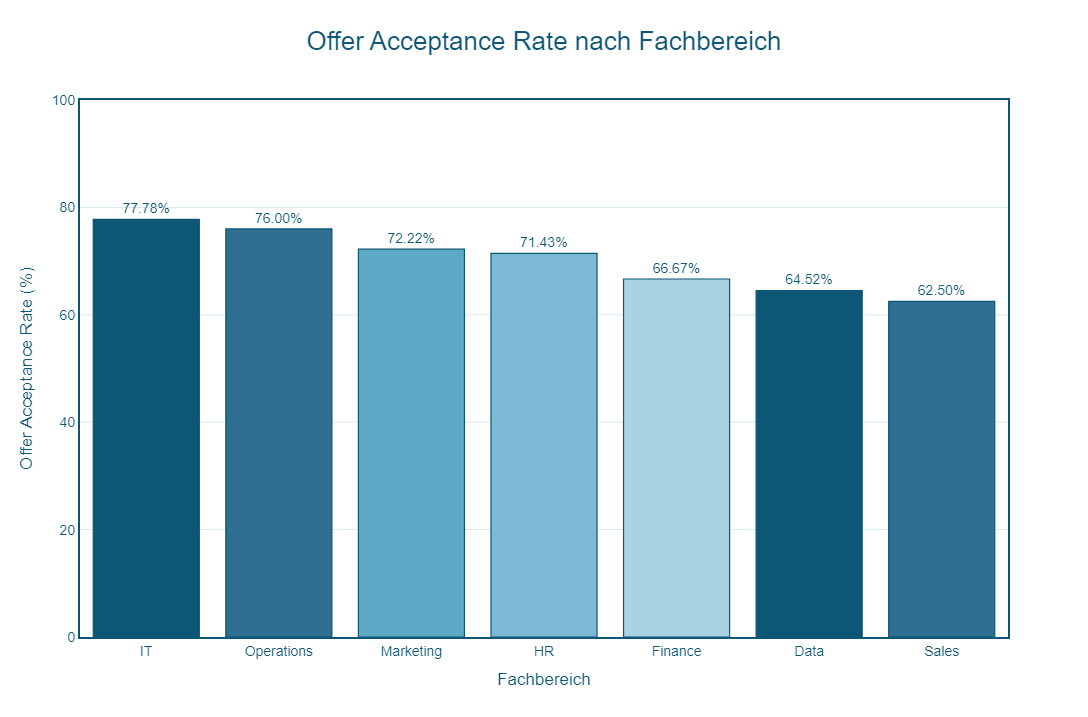

In [50]:
# Offer Acceptance Rate nach Fachbereich
# ==========================================================
#
# Ziel:
# Vergleich der Angebotsannahmerate zwischen den Fachbereichen.
#
# Die Grafik zeigt:
# In welchen Fachbereichen Kandidaten
# Jobangebote häufiger annehmen.


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"


# ----------------------------------------------------------
# 2. DataFrame für Plotly vorbereiten
# ----------------------------------------------------------

plot_df = (
    department_summary
    .reset_index()
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)


# ----------------------------------------------------------
# 3. Balkendiagramm erstellen
# ----------------------------------------------------------
#
# Jeder Fachbereich erhält eine eigene Farbe
# innerhalb des definierten Blauton-Verlaufs.

fig = px.bar(
    plot_df,
    x="Department",
    y="Offer Acceptance Rate",
    text="Offer Acceptance Rate",
    title="Offer Acceptance Rate nach Fachbereich",
    labels={
        "Department": "Fachbereich",
        "Offer Acceptance Rate": "Offer Acceptance Rate (%)"
    },
    color="Department",
    color_discrete_sequence=[
        "#0E5675",
        "#2F6F91",
        "#5DA9C6",
        "#7CB9D4",
        "#A8D4E2"
    ]
)


# ----------------------------------------------------------
# 4. Prozentwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    texttemplate="%{text:.2f}%",
    textposition="outside",
    marker_line_color=PRIMARY,
    marker_line_width=1.2
)


# ----------------------------------------------------------
# 5. Layout im einheitlichen Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Offer Acceptance Rate nach Fachbereich",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Fachbereich",
    yaxis_title="Offer Acceptance Rate (%)",

    yaxis_range=[0, 100],

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen ergänzen
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    showgrid=False
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

#### 6.5.7 Interpretation

**Die Offer Acceptance Rate unterscheidet sich zwischen den Fachbereichen.**

Die höchsten Angebotsannahmeraten zeigen die Fachbereiche **IT (77,78 %)** und **Operations (76,00 %)**. Kandidaten in diesen Bereichen nehmen Jobangebote häufiger an als in den übrigen Fachbereichen.

Die niedrigsten Werte weisen **Sales (62,50 %)** und **Data (64,52 %)** auf. Dies deutet darauf hin, dass Kandidaten in diesen Bereichen Angebote häufiger ablehnen oder alternative Optionen wahrnehmen.

**Auffällig ist, dass die Unterschiede zwischen dem besten und dem schwächsten Fachbereich mehr als 15 Prozentpunkte betragen.** Dies ist deutlich stärker als die Unterschiede, die zuvor bei Recruiting Channels beobachtet wurden.

Ein möglicher Erklärungsansatz ist, dass sich die Wettbewerbssituation je Fachbereich unterscheidet. Insbesondere in datengetriebenen oder vertriebsnahen Rollen könnten Kandidaten mehr Auswahlmöglichkeiten haben und Angebote kritischer vergleichen.

Gleichzeitig zeigen die Funnel-KPIs, dass die Interview- und Angebotsprozesse über alle Fachbereiche hinweg relativ ähnlich verlaufen. Die größten Unterschiede entstehen erst in der Phase der Angebotsannahme.

**Aus Business-Sicht sollte daher untersucht werden, warum insbesondere Kandidaten in den Bereichen Data und Sales Angebote häufiger ablehnen.** Mögliche Ursachen könnten Gehalt, Arbeitsmodell, Aufgabenprofil oder die Wettbewerbssituation am Arbeitsmarkt sein.

### 6.6 Korrelationsanalysen

Jetzt kommen wir von der Gruppenanalyse zur Zusammenhangsanalyse. Verändern sich zwei Variablen gemeinsam - also korrelieren sie miteinander? Welche Variablen scheinen miteinander zusammenzuhängen? Dafür braucht man metrische Variablen.

In [51]:
# Job-Analyse:
# Bewerbungen pro Job + Fachbereich + durchschnittliche Time to Hire
# ==========================================================

# ----------------------------------------------------------
# 1. Bewerbungen pro Job zählen
# ----------------------------------------------------------

applications_per_job = (
    fact_candidate_events[
        ["application_id", "job_id"]
    ]
    .drop_duplicates()
    .groupby("job_id")
    .size()
    .reset_index(name="applications_per_job")
)


# ----------------------------------------------------------
# 2. Fachbereich ergänzen
# ----------------------------------------------------------

applications_per_job = (
    applications_per_job
    .merge(
        dim_job[
            ["job_id", "department"]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Durchschnittliche Time to Hire pro Job berechnen
# ----------------------------------------------------------

job_time_to_hire = (
    time_to_hire
    .merge(
        fact_candidate_events[
            ["application_id", "job_id"]
        ]
        .drop_duplicates(),
        on="application_id",
        how="left"
    )
    .groupby("job_id")
    .agg(
        avg_time_to_hire=("time_to_hire_days", "mean")
    )
    .reset_index()
)


# ----------------------------------------------------------
# 4. Alles zusammenführen
# ----------------------------------------------------------

job_analysis = (
    applications_per_job
    .merge(
        job_time_to_hire,
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 5. Formatieren
# ----------------------------------------------------------

job_analysis["avg_time_to_hire"] = (
    job_analysis["avg_time_to_hire"]
    .round(2)
)


# ----------------------------------------------------------
# 6. Ergebnis anzeigen
# ----------------------------------------------------------

job_analysis.sort_values(
    by="applications_per_job",
    ascending=False
)

,job_id,applications_per_job,department,avg_time_to_hire
120,J0121,69,HR,37.00
111,J0112,67,Sales,37.50
4,J0005,66,IT,NaN
114,J0115,66,Data,43.00
86,J0087,64,Marketing,63.00
...,...,...,...,...
33,J0034,39,Sales,NaN
100,J0101,39,IT,NaN
66,J0067,38,Sales,38.00
96,J0097,38,Finance,48.00


In [52]:
len(time_to_hire)

110

In [53]:
time_to_hire["application_id"].nunique()

110

In [54]:
time_to_hire.merge(
    fact_candidate_events[
        ["application_id", "job_id"]
    ].drop_duplicates(),
    on="application_id"
)["job_id"].nunique()

77

In [55]:
# Erfolgreiche Besetzungen pro Job analysieren
# ==========================================================

# ----------------------------------------------------------
# 1. Job-ID zu den Time-to-Hire-Daten ergänzen
# ----------------------------------------------------------

job_hires = (
    time_to_hire
    .merge(
        fact_candidate_events[
            ["application_id", "job_id"]
        ].drop_duplicates(),
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 2. Anzahl erfolgreicher Besetzungen pro Job zählen
# ----------------------------------------------------------

hires_per_job = (
    job_hires
    .groupby("job_id")
    .size()
    .reset_index(name="successful_hires")
)


# ----------------------------------------------------------
# 3. Alle Jobs ergänzen
# ----------------------------------------------------------

all_jobs = dim_job[["job_id"]].copy()

hires_per_job = (
    all_jobs
    .merge(
        hires_per_job,
        on="job_id",
        how="left"
    )
)

hires_per_job["successful_hires"] = (
    hires_per_job["successful_hires"]
    .fillna(0)
    .astype(int)
)


# ----------------------------------------------------------
# 4. Verteilung erstellen
# ----------------------------------------------------------

hire_distribution = (
    hires_per_job["successful_hires"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hire_distribution.columns = [
    "successful_hires",
    "anzahl_jobs"
]


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

hire_distribution

,successful_hires,anzahl_jobs
0,0,73
1,1,50
2,2,21
3,3,6


**Interpretation**
In der Tabelle Job-Analyse gibt es NULL-Felder --> Überprüfung der Länge und der besetzten Jobs --> es gibt nur 77 besetzte Jobs, jedoch mit mehreren Stellen pro Job-ID, so dass es in Summe 110 sind.

#### 6.6.1 Applications per Job vs. Time to Hire

Führen Stellen mit vielen Bewerbungen zu längeren Besetzungszeiten?

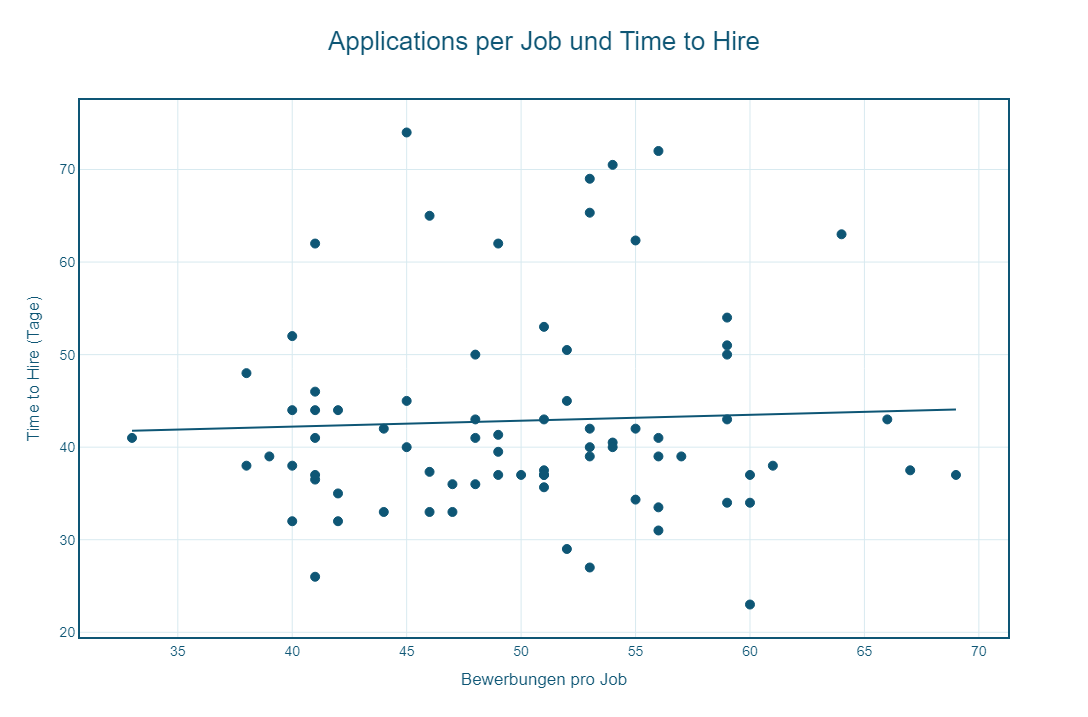

In [56]:
# Scatterplot:
# Applications per Job vs. Time to Hire
# ==========================================================
#
# Fragestellung:
# Besteht ein Zusammenhang zwischen der Anzahl
# der Bewerbungen pro Stelle und der Time to Hire?
#
# Jede Markierung repräsentiert eine Job-ID.


# ----------------------------------------------------------
# 1. Time to Hire pro Job berechnen
# ----------------------------------------------------------

job_time_to_hire = (
    time_to_hire
    .merge(
        fact_candidate_events[
            ["application_id", "job_id"]
        ].drop_duplicates(),
        on="application_id",
        how="left"
    )
    .groupby("job_id")["time_to_hire_days"]
    .mean()
    .reset_index()
)


# ----------------------------------------------------------
# 2. Applications pro Job ergänzen
# ----------------------------------------------------------

job_analysis = (
    applications_per_job
    .merge(
        job_time_to_hire,
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Scatterplot erstellen
# ----------------------------------------------------------

fig = px.scatter(
    job_analysis,
    x="applications_per_job",
    y="time_to_hire_days",
    hover_data=["job_id"],
    trendline="ols",      # Regressionslinie
    title="Applications per Job und Time to Hire",
    labels={
        "applications_per_job": "Bewerbungen pro Job",
        "time_to_hire_days": "Time to Hire (Tage)"
    }
)


# ----------------------------------------------------------
# 4. Layout im Projektdesign
# ----------------------------------------------------------

fig.update_traces(
    marker=dict(
        size=9,
        color="#0E5675",
        line=dict(
            color="#0E5675",
            width=1
        )
    )
)

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#0E5675"
    ),

    title=dict(
        text="Applications per Job und Time to Hire",
        x=0.5,
        font=dict(
            size=26,
            color="#0E5675"
        )
    )
)

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.show()

In [57]:
#len(job_analysis_clean)

In [58]:
# Korrelationskoeffizient nach Pearson

job_analysis_clean = (
    job_analysis[
        ["applications_per_job", "time_to_hire_days"]
    ]
    .dropna()
)

from scipy.stats import pearsonr

r, p = pearsonr(
    job_analysis_clean["applications_per_job"],
    job_analysis_clean["time_to_hire_days"]
)

print(f"Pearson r = {r:.3f}")
print(f"p-Wert = {p:.3f}")

Pearson r = 0.044
p-Wert = 0.701


**Interpretation**

Die Pearson-Korrelation zwischen der Anzahl der Bewerbungen pro Stelle und der Time to Hire beträgt r = 0,044.

Der Korrelationskoeffizient liegt nahe bei 0 und deutet auf keinen linearen Zusammenhang zwischen beiden Variablen hin. Der Zusammenhang ist mit einem p-Wert von 0,701 statistisch nicht signifikant (p > 0,05).

Die Anzahl der Bewerbungen pro Stelle scheint in diesem Datensatz keinen relevanten Einfluss auf die Dauer des Recruiting-Prozesses zu haben.

#### 6.6.2 Offers per Job vs. Offer Acceptance Rate

Hat die Anzahl der Job-Angebote einen Einfluss auf die Offer-Acceptance-Rate?

In [59]:
# Offer Acceptance Rate pro Job berechnen
# ==========================================================

job_offer_analysis = (
    fact_candidate_events
    .groupby("job_id")
    .agg(
        offers_made=(
            "event_type",
            lambda x: (x == "Offer Made").sum()
        ),
        offers_accepted=(
            "event_type",
            lambda x: (x == "Offer Accepted").sum()
        )
    )
    .reset_index()
)

# Offer Acceptance Rate berechnen
job_offer_analysis["offer_acceptance_rate"] = (
    job_offer_analysis["offers_accepted"]
    / job_offer_analysis["offers_made"]
    * 100
)

# Jobs ohne Angebot entfernen
job_offer_analysis = (
    job_offer_analysis[
        job_offer_analysis["offers_made"] > 0
    ]
)

job_offer_analysis.head()

,job_id,offers_made,offers_accepted,offer_acceptance_rate
2,J0003,4,3,75.00
3,J0004,1,1,100.00
4,J0005,2,1,50.00
5,J0006,2,0,0.00
7,J0008,4,2,50.00


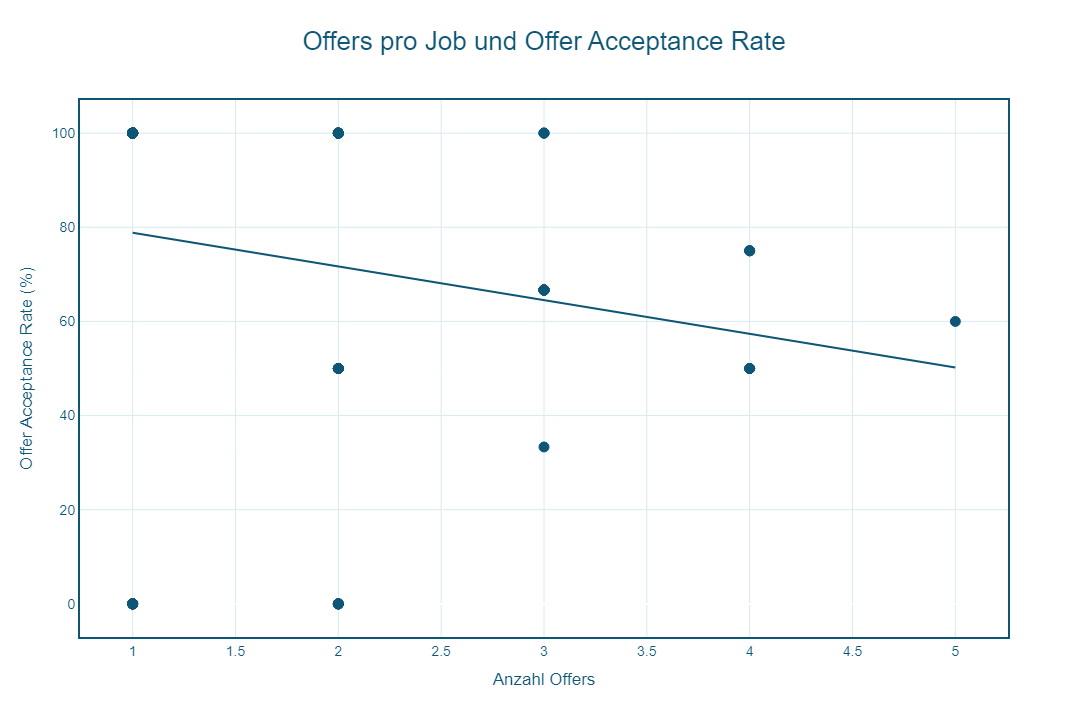

Pearson r = -0.188
p-Wert = 0.061


In [60]:
# Scatterplot Applications per Job vs. Offer Acceptance Rate
# ==========================================================
#
# Ziel:
# Untersuchung, ob Jobs mit mehr Angeboten
# eine höhere oder niedrigere Offer Acceptance Rate aufweisen.
#
# Der Scatterplot zeigt:
# - jede Job-ID als Punkt
# - die Offer Acceptance Rate pro Job
# - eine lineare Regressionslinie
#
# Zusätzlich wird der Pearson-Korrelationskoeffizient berechnet.


# ----------------------------------------------------------
# 1. Offer Acceptance Rate pro Job berechnen
# ----------------------------------------------------------

job_offer_analysis = (
    fact_candidate_events
    .groupby("job_id")
    .agg(
        offers_made=(
            "event_type",
            lambda x: (x == "Offer Made").sum()
        ),
        offers_accepted=(
            "event_type",
            lambda x: (x == "Offer Accepted").sum()
        )
    )
    .reset_index()
)

job_offer_analysis["offer_acceptance_rate"] = (
    job_offer_analysis["offers_accepted"]
    / job_offer_analysis["offers_made"]
    * 100
)

job_offer_analysis = (
    job_offer_analysis[
        job_offer_analysis["offers_made"] > 0
    ]
)


# ----------------------------------------------------------
# 2. Scatterplot mit Regressionslinie erstellen
# ----------------------------------------------------------

import plotly.express as px

fig = px.scatter(
    job_offer_analysis,
    x="offers_made",
    y="offer_acceptance_rate",
    trendline="ols",
    hover_data=["job_id"],
    title="Offers pro Job und Offer Acceptance Rate",
    labels={
        "offers_made": "Anzahl Offers",
        "offer_acceptance_rate": "Offer Acceptance Rate (%)"
    }
)


# ----------------------------------------------------------
# 3. Marker formatieren
# ----------------------------------------------------------

fig.update_traces(
    marker=dict(
        size=10,
        color="#0E5675",
        line=dict(
            color="#0E5675",
            width=1
        )
    )
)


# ----------------------------------------------------------
# 4. Layout im Projektdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#0E5675"
    ),

    title=dict(
        text="Offers pro Job und Offer Acceptance Rate",
        x=0.5,
        font=dict(
            size=26,
            color="#0E5675"
        )
    ),

    showlegend=False
)


# ----------------------------------------------------------
# 5. Rahmen und Gitternetz
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)


# ----------------------------------------------------------
# 6. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()


# ----------------------------------------------------------
# 7. Pearson-Korrelation berechnen
# ----------------------------------------------------------

from scipy.stats import pearsonr

r, p = pearsonr(
    job_offer_analysis["offers_made"],
    job_offer_analysis["offer_acceptance_rate"]
)

print(f"Pearson r = {r:.3f}")
print(f"p-Wert = {p:.3f}")

**Interpretation**

Die Korrelationsanalyse zwischen der Anzahl der ausgesprochenen Angebote pro Stelle und der Offer Acceptance Rate zeigt einen schwachen negativen Zusammenhang (Pearson r = -0,188). Tendenziell sinkt die Annahmequote leicht, wenn für eine Stelle mehr Angebote ausgesprochen werden.

Der Zusammenhang ist jedoch sehr schwach und statistisch nicht signifikant (p = 0,061). Da der p-Wert knapp oberhalb des üblichen Signifikanzniveaus von 5 % liegt, kann die Nullhypothese eines fehlenden linearen Zusammenhangs nicht verworfen werden.

Auch der Scatterplot zeigt keine klare lineare Struktur. Die Beobachtungen streuen stark, sodass kein belastbarer Zusammenhang zwischen der Anzahl der ausgesprochenen Angebote und der Offer Acceptance Rate erkennbar ist.

Insgesamt deutet die Analyse darauf hin, dass die Anzahl der ausgesprochenen Angebote pro Stelle keinen statistisch nachweisbaren Einfluss auf die Wahrscheinlichkeit hat, dass ein Angebot von Kandidaten angenommen wird.

#### 6.6.3 Time to Hire vs. Successful Hires

Besteht ein Zusammenhang zwischen der Time to Hire und der Anzahl der erfolgreichen Einstellungen pro Job?

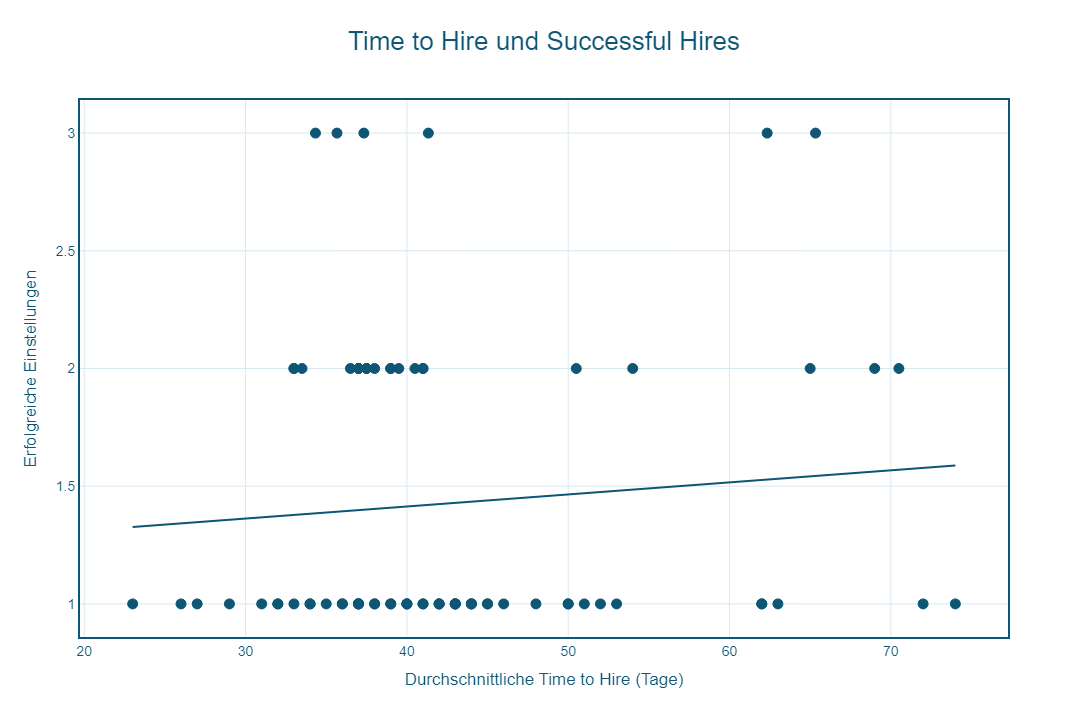

Pearson r = 0.088
p-Wert = 0.444


In [61]:
# Scatterplot Time to Hire vs. Successful Hires
# ==========================================================
#
# Ziel:
# Untersuchung, ob ein Zusammenhang zwischen der
# durchschnittlichen Time to Hire eines Jobs und der
# Anzahl erfolgreicher Einstellungen besteht.
#
# Berücksichtigt werden nur Jobs mit mindestens einer
# erfolgreichen Einstellung.


# ----------------------------------------------------------
# 1. Durchschnittliche Time to Hire pro Job berechnen
# ----------------------------------------------------------

job_time_to_hire = (
    time_to_hire
    .merge(
        fact_candidate_events[
            ["application_id", "job_id"]
        ].drop_duplicates(),
        on="application_id",
        how="left"
    )
    .groupby("job_id")
    .agg(
        mean_time_to_hire=("time_to_hire_days", "mean")
    )
    .reset_index()
)


# ----------------------------------------------------------
# 2. Erfolgreiche Einstellungen pro Job zählen
# ----------------------------------------------------------

hires_per_job = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Contract Signed"
    ]
    .groupby("job_id")
    .size()
    .reset_index(name="successful_hires")
)


# ----------------------------------------------------------
# 3. Datensatz zusammenführen
# ----------------------------------------------------------

job_hires_analysis = (
    job_time_to_hire
    .merge(
        hires_per_job,
        on="job_id",
        how="inner"
    )
)


# ----------------------------------------------------------
# 4. Nur Jobs mit mindestens einer Einstellung
# ----------------------------------------------------------

job_hires_analysis = (
    job_hires_analysis[
        job_hires_analysis["successful_hires"] >= 1
    ]
)


# ----------------------------------------------------------
# 5. Scatterplot mit Regressionslinie
# ----------------------------------------------------------

import plotly.express as px

fig = px.scatter(
    job_hires_analysis,
    x="mean_time_to_hire",
    y="successful_hires",
    hover_data=["job_id"],
    trendline="ols",
    title="Time to Hire und Successful Hires",
    labels={
        "mean_time_to_hire": "Durchschnittliche Time to Hire (Tage)",
        "successful_hires": "Erfolgreiche Einstellungen"
    }
)


# ----------------------------------------------------------
# 6. Layout im Projektdesign
# ----------------------------------------------------------

fig.update_traces(
    marker=dict(
        size=10,
        color="#0E5675",
        line=dict(
            color="#0E5675",
            width=1
        )
    )
)

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#0E5675"
    ),

    title=dict(
        text="Time to Hire und Successful Hires",
        x=0.5,
        font=dict(
            size=26,
            color="#0E5675"
        )
    ),

    showlegend=False
)

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.show()


# ----------------------------------------------------------
# 7. Pearson-Korrelation berechnen
# ----------------------------------------------------------

from scipy.stats import pearsonr

r, p = pearsonr(
    job_hires_analysis["mean_time_to_hire"],
    job_hires_analysis["successful_hires"]
)

print(f"Pearson r = {r:.3f}")
print(f"p-Wert = {p:.3f}")

**Interpretation**

Die Korrelationsanalyse zwischen der durchschnittlichen Time to Hire und der Anzahl erfolgreicher Einstellungen pro Job zeigt keinen erkennbaren Zusammenhang. Der Pearson-Korrelationskoeffizient liegt mit r = 0,088 nahe bei null und deutet auf eine sehr schwache positive lineare Beziehung hin.

Der p-Wert von 0,444 liegt deutlich oberhalb des Signifikanzniveaus von 5%. Die Nullhypothese eines fehlenden linearen Zusammenhangs kann daher nicht verworfen werden. Das Ergebnis ist statistisch nicht signifikant.

Auch der Scatterplot zeigt keine klare Struktur. Die Beobachtungen streuen über den gesamten Wertebereich, unabhängig davon, ob ein Job ein-, zwei- oder dreimal erfolgreich besetzt wurde. Die Regressionslinie verläuft nahezu horizontal, was die fehlende Beziehung zusätzlich verdeutlicht.

Insgesamt deutet die Analyse darauf hin, dass die Dauer des Recruiting-Prozesses keinen statistisch nachweisbaren Zusammenhang mit der Anzahl erfolgreicher Einstellungen pro Job aufweist.

#### 6.6.4 Applications per Job vs. Offers per Job

Führen mehr Bewerbungen pro Stelle dazu, dass mehr Angebote ausgesprochen werden?

In [62]:
# Datensatz für Korrelationsanalyse
# Applications per Job vs. Offers per Job
# ==========================================================

# ----------------------------------------------------------
# 1. Bewerbungen pro Job zählen
# ----------------------------------------------------------

applications_per_job = (
    fact_candidate_events[
        ["job_id", "application_id"]
    ]
    .drop_duplicates()
    .groupby("job_id")
    .size()
    .reset_index(name="applications_per_job")
)


# ----------------------------------------------------------
# 2. Offers pro Job zählen
# ----------------------------------------------------------

offers_per_job = (
    fact_candidate_events[
        fact_candidate_events["event_type"] == "Offer Made"
    ]
    .groupby("job_id")
    .size()
    .reset_index(name="offers_per_job")
)


# ----------------------------------------------------------
# 3. Datensätze zusammenführen
# ----------------------------------------------------------

job_offer_analysis = (
    applications_per_job
    .merge(
        offers_per_job,
        on="job_id",
        how="left"
    )
)

job_offer_analysis["offers_per_job"] = (
    job_offer_analysis["offers_per_job"]
    .fillna(0)
)
# ----------------------------------------------------------
# 4. Jobs ohne Offer entfernen
# ----------------------------------------------------------

job_offer_analysis = (
    job_offer_analysis[
        job_offer_analysis["offers_per_job"] > 0
    ]
)
job_offer_analysis.head()

,job_id,applications_per_job,offers_per_job
2,J0003,55,4.00
3,J0004,48,1.00
4,J0005,66,2.00
5,J0006,55,2.00
7,J0008,44,4.00


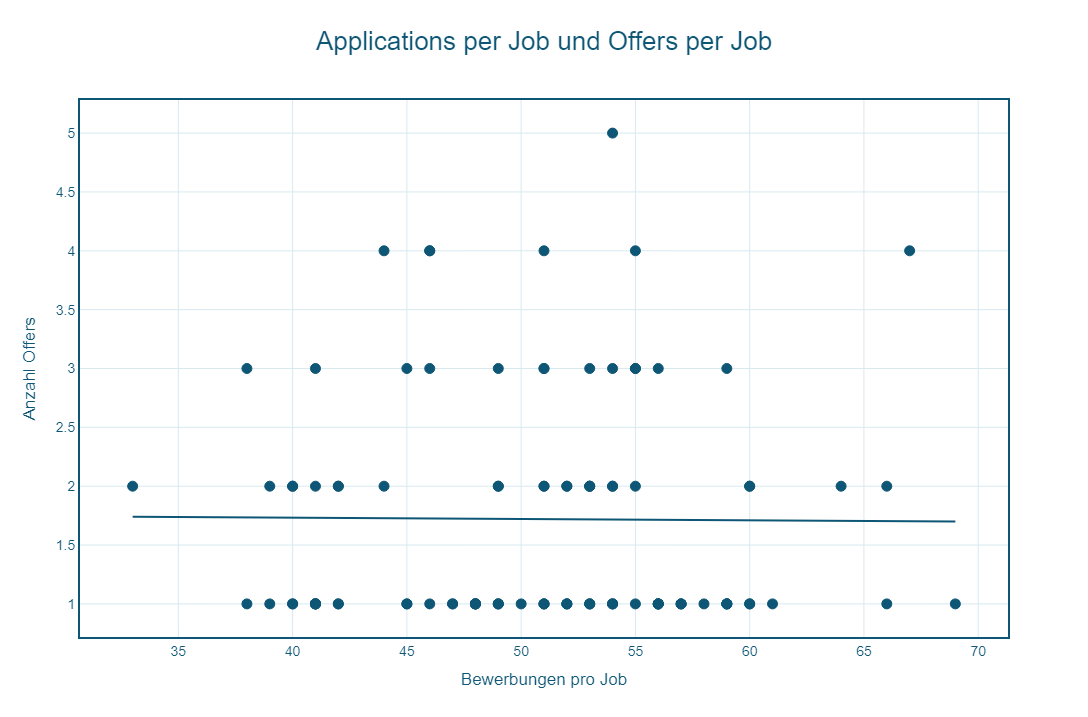

In [63]:
# Scatterplot Applications per Job vs. Offers per Job
# ==========================================================

import plotly.express as px

fig = px.scatter(
    job_offer_analysis,
    x="applications_per_job",
    y="offers_per_job",
    hover_data=["job_id"],
    trendline="ols",
    title="Applications per Job und Offers per Job",
    labels={
        "applications_per_job": "Bewerbungen pro Job",
        "offers_per_job": "Anzahl Offers"
    }
)

fig.update_traces(
    marker=dict(
        size=10,
        color="#0E5675",
        line=dict(
            color="#0E5675",
            width=1
        )
    )
)

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color="#0E5675"
    ),

    title=dict(
        text="Applications per Job und Offers per Job",
        x=0.5,
        font=dict(
            size=26,
            color="#0E5675"
        )
    ),

    showlegend=False
)

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor="#0E5675",
    mirror=True,
    gridcolor="#D8EAF0"
)

fig.show()


In [64]:
# Korrelationskoeffizient nach Pearson
# ==========================================================

from scipy.stats import pearsonr

r, p = pearsonr(
    job_offer_analysis["applications_per_job"],
    job_offer_analysis["offers_per_job"]
)

print(f"Pearson r = {r:.3f}")
print(f"p-Wert = {p:.3f}")

Pearson r = -0.008
p-Wert = 0.935


**Interpretation**

Die Korrelationsanalyse zwischen der Anzahl der Bewerbungen pro Job und der Anzahl der ausgesprochenen Angebote zeigt keinen erkennbaren Zusammenhang. Der Pearson-Korrelationskoeffizient liegt mit r = -0,008 praktisch bei null und weist damit auf keine lineare Beziehung zwischen beiden Variablen hin.

Der p-Wert von 0,935 liegt deutlich oberhalb des Signifikanzniveaus von 5 %. Die Nullhypothese eines fehlenden linearen Zusammenhangs kann daher nicht verworfen werden. Das Ergebnis ist statistisch nicht signifikant.

Auch der Scatterplot bestätigt dieses Ergebnis. Die Anzahl der ausgesprochenen Angebote verteilt sich über den gesamten Bereich der Bewerbungszahlen, ohne dass ein erkennbares Muster oder ein Trend sichtbar wird. Die Regressionslinie verläuft nahezu horizontal, was auf das Fehlen eines linearen Zusammenhangs hinweist.

Insgesamt deutet die Analyse darauf hin, dass die Anzahl der eingegangenen Bewerbungen keinen statistisch nachweisbaren Zusammenhang mit der Anzahl der ausgesprochenen Angebote pro Job aufweist.

**Zusammenfassung der Korrelationsanalysen**

Die durchgeführten Korrelationsanalysen zeigen keine statistisch signifikanten linearen Zusammenhänge zwischen den untersuchten Prozesskennzahlen. Weder die Anzahl der Bewerbungen noch die Anzahl erfolgreicher Einstellungen oder die Anzahl ausgesprochener Angebote weisen einen nachweisbaren Zusammenhang mit der Time to Hire auf.

Die Ergebnisse deuten darauf hin, dass die betrachteten Kennzahlen weitgehend unabhängig voneinander variieren. Für die weitere Analyse liegt der Fokus daher auf Gruppenvergleichen zwischen Fachbereichen, Standorten, Arbeitsmodellen und Kandidatenleveln, um mögliche Unterschiede mithilfe statistischer Testverfahren zu untersuchen.

## 7. Hypothesen und Statistische Tests

Im Rahmen der explorativen Datenanalyse wurden Unterschiede zwischen verschiedenen Gruppen identifiziert. Dabei zeigten sich insbesondere Abweichungen zwischen Standorten, Fachbereichen, Arbeitsmodellen und Kandidatenleveln hinsichtlich der Time to Hire sowie weiterer Recruiting-Kennzahlen.

Ziel der statistischen Tests ist es zu prüfen, ob die beobachteten Unterschiede zufällig entstanden sein könnten oder ob sie statistisch signifikant sind. Hierzu werden geeignete Hypothesentests durchgeführt. Zusätzlich werden Effektstärken berechnet, um die praktische Relevanz möglicher Unterschiede zu bewerten.

Die folgenden Analysen konzentrieren sich erst auf den Vergleich von Gruppen hinsichtlich ihrer durchschnittlichen Time to Hire und anschließend auf die Offer Acceptance Rate.

### 7.1 Einflussfaktoren auf die Time to Hire

#### 7.1.1 Standort

**1. Hypothesen**

$H_0$: Die durchschnittliche Time to Hire unterscheidet sich nicht zwischen den Standorten.<br>
$H_1$: Die durchschnittliche Time to Hire unterscheidet sich für mindestens einen Standort.

**2. Voraussetzungen prüfen**

Der Faktor ist der Standort, die Zielvariable ist die Time-to-Hire. Die Zielvariable ist metrisch, bei einer Normalverteilung und Varianzhomogenität kann ich mit Hilfe der einfaktoriellen ANOVA prüfen, ob hier ein Einfluss besteht. 

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegt eine **Normalverteilung** innerhalb der Gruppen vor? --> Shapiro Wilk Test ($H_0$: Die Daten sind normal verteilt.)


In [65]:
# Shapiro-Wilk-Test
# Standort vs. Time to Hire
# ==========================================================
#
# Ziel:
# Prüfung der Normalverteilung der Time to Hire
# innerhalb der einzelnen Standorte.
#
# H0:
# Die Daten sind normalverteilt.
#
# H1:
# Die Daten sind nicht normalverteilt.
#
# Interpretation:
# p > 0.05  -> Normalverteilung kann angenommen werden
# p ≤ 0.05  -> Normalverteilung wird verworfen


# ----------------------------------------------------------
# 1. Bibliotheken importieren
# ----------------------------------------------------------

from scipy.stats import shapiro
import pandas as pd


# ----------------------------------------------------------
# 2. Shapiro-Wilk-Test je Standort durchführen
# ----------------------------------------------------------

results = []

for city in sorted(time_to_hire_location["city"].unique()):

    values = (
        time_to_hire_location
        .loc[
            time_to_hire_location["city"] == city,
            "time_to_hire_days"
        ]
    )

    statistic, p_value = shapiro(values)

    results.append([
        city,
        len(values),
        round(statistic, 4),
        round(p_value, 4)
    ])


# ----------------------------------------------------------
# 3. Ergebnisse in DataFrame speichern
# ----------------------------------------------------------

shapiro_location = pd.DataFrame(
    results,
    columns=[
        "Standort",
        "Anzahl",
        "Shapiro-W",
        "p-Wert"
    ]
)


# ----------------------------------------------------------
# 4. Interpretation ergänzen
# ----------------------------------------------------------

shapiro_location["Normalverteilung"] = (
    shapiro_location["p-Wert"]
    .apply(
        lambda x:
        "Ja" if x > 0.05 else "Nein"
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

shapiro_location

,Standort,Anzahl,Shapiro-W,p-Wert,Normalverteilung
0,Berlin,17,0.90,0.07,Ja
1,Frankfurt,26,0.93,0.10,Ja
2,Hamburg,26,0.95,0.22,Ja
3,Köln,20,0.95,0.32,Ja
4,München,21,0.97,0.77,Ja


Der Shapiro-Wilk-Test ergab für alle Standorte einen W-Wert > 0,9 und p-Werte größer als 0,05. Die Annahme der Normalverteilung kann daher beibehalten werden.

Als nächstes prüfe ich, ob eine **Varianzhomogenität** vorliegt, sprich, ob die Gruppen eine ähnliche Streuung haben. Da meine Gruppen normalverteilt sind, wähle ich den Bartlett-Test ($H_0$: Die Varianzen sind gleich.)

In [66]:
# Bartlett-Test auf Varianzhomogenität
# Standort vs. Time to Hire
# ==========================================================

from scipy.stats import bartlett

# ----------------------------------------------------------
# 1. Nur gültige Time-to-Hire-Werte verwenden
# ----------------------------------------------------------

bartlett_data = (
    time_to_hire_location
    .dropna(subset=["time_to_hire_days", "city"])
)


# ----------------------------------------------------------
# 2. Gruppen je Standort erstellen
# ----------------------------------------------------------

location_groups = [
    group["time_to_hire_days"].astype(float).values
    for city, group in bartlett_data.groupby("city")
    if len(group) > 1
]


# ----------------------------------------------------------
# 3. Bartlett-Test durchführen
# ----------------------------------------------------------

bartlett_stat, p_value = bartlett(*location_groups)


# ----------------------------------------------------------
# 4. Ergebnis ausgeben
# ----------------------------------------------------------

print(f"Bartlett χ² = {bartlett_stat:.3f}")
print(f"p-Wert = {p_value:.3f}")

Bartlett χ² = 11.812
p-Wert = 0.019


Der Test ergab einen Bartlett-Wert von χ² = 11,81 bei einem p-Wert von 0,019.

Da der p-Wert kleiner als 0,05 ist, wird die Nullhypothese verworfen. Die Varianzen unterscheiden sich somit signifikant zwischen den Standorten. Die Annahme der Varianzhomogenität ist daher nicht erfüllt.

Da die Annahme homogener Varianzen verletzt wurde, wird anstelle der klassischen ANOVA eine Welch-ANOVA durchgeführt.

**3. Testverfahren**

Die einfaktorielle ANOVA (Analysis of Variance) wird verwendet, um zu untersuchen, ob sich die Mittelwerte einer metrischen Zielvariable zwischen mehreren Gruppen statistisch signifikant unterscheiden.

Im Rahmen dieser Arbeit wird geprüft, ob sich die durchschnittliche Time to Hire zwischen den verschiedenen Standorten unterscheidet.

H₀: Die Mittelwerte aller Gruppen sind gleich.<br>
H₁: Mindestens ein Gruppenmittelwert unterscheidet sich von den anderen.

Voraussetzungen der klassischen ANOVA sind die Unabhängigkeit der Beobachtungen, eine annähernde Normalverteilung innerhalb der Gruppen sowie die Homogenität der Varianzen.

Da der Bartlett-Test signifikante Unterschiede der Varianzen zwischen den Standorten zeigte, wird anstelle der klassischen ANOVA die Welch-ANOVA verwendet. Die Welch-ANOVA ist eine robuste Erweiterung der ANOVA und eignet sich insbesondere dann, wenn die Annahme gleicher Varianzen verletzt ist.


In [67]:
# Welch-ANOVA
# Standort vs. Time to Hire
# ==========================================================
#
# H0:
# Die durchschnittliche Time to Hire ist an allen Standorten gleich.
#
# H1:
# Mindestens ein Standort unterscheidet sich hinsichtlich
# der durchschnittlichen Time to Hire.


# ----------------------------------------------------------
# 1. Bibliothek importieren
# ----------------------------------------------------------

import pingouin as pg


# ----------------------------------------------------------
# 2. Welch-ANOVA durchführen
# ----------------------------------------------------------

welch_anova = pg.welch_anova(
    data=time_to_hire_location,
    dv="time_to_hire_days",
    between="city"
)


# ----------------------------------------------------------
# 3. Ergebnis anzeigen
# ----------------------------------------------------------

welch_anova.round(4)

,Source,ddof1,ddof2,F,p_unc,np2
0,city,4,50.18,36.94,0.00,0.67



Die Welch-ANOVA ergab einen statistisch signifikanten Unterschied der durchschnittlichen Time to Hire zwischen den Standorten (F(4, 50,18) = 36,94, p < 0,001).

Die Nullhypothese gleicher Mittelwerte wird somit verworfen. Die Ergebnisse zeigen, dass sich die durchschnittliche Time to Hire zwischen den Standorten signifikant unterscheidet.

Die **Effektstärke** beträgt η² = 0,67 und weist auf einen sehr starken Effekt hin. Demnach können etwa 67% der Varianz der Time to Hire durch den Standort erklärt werden.

Der Standort stellt somit einen wesentlichen Einflussfaktor auf die Dauer des Recruiting-Prozesses dar.

**4. Posthoc-Test**

Der Test (Welch-ANOVA) bestätigt, dass es einen Unterschied gibt, aber er sagt uns noch nicht, wo dieser Unterschied liegt. Dazu kommen Post-hoc Verfahren zum Einsatz, z.B. in Form eines paarweisen Vergleichs. Der Tukey-Test kann hier nicht verwendet werden, weil dieser eine Varianzhomomgenität voraussetzt. Also nehmen wir alternativ den Games-Howell-Test.

In [68]:
# Post-hoc-Test Games-Howell
# Standort vs. Time to Hire
# ==========================================================

import pingouin as pg

games_howell_location = pg.pairwise_gameshowell(
    data=time_to_hire_location,
    dv="time_to_hire_days",
    between="city"
)

games_howell_location.round(4)

,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges
0,Berlin,Frankfurt,37.82,60.65,-22.83,2.26,-10.10,40.96,0.00,-2.85
1,Berlin,Hamburg,37.82,38.77,-0.95,1.91,-0.50,36.22,0.99,-0.15
2,Berlin,Köln,37.82,37.60,0.22,2.29,0.10,34.47,1.00,0.03
3,Berlin,München,37.82,37.24,0.59,1.72,0.34,28.56,1.00,0.11
4,Frankfurt,Hamburg,60.65,38.77,21.88,2.15,10.19,45.45,0.00,2.78
5,Frankfurt,Köln,60.65,37.60,23.05,2.49,9.26,42.92,0.00,2.67
6,Frankfurt,München,60.65,37.24,23.42,1.98,11.81,37.80,0.00,3.19
7,Hamburg,Köln,38.77,37.60,1.17,2.18,0.54,35.87,0.98,0.16
8,Hamburg,München,38.77,37.24,1.53,1.57,0.97,43.80,0.87,0.27
9,Köln,München,37.60,37.24,0.36,2.02,0.18,29.05,1.00,0.06


Zur Identifikation der konkreten Gruppenunterschiede wurde nach der signifikanten Welch-ANOVA ein Games-Howell-Post-hoc-Test durchgeführt.

Die Ergebnisse zeigen, dass sich ausschließlich der Standort Frankfurt signifikant von allen anderen Standorten unterscheidet (jeweils p < 0,001). Die durchschnittliche Time to Hire beträgt in Frankfurt 60,65 Tage und liegt damit rund 22 bis 23 Tage über den übrigen Standorten.

Zwischen Berlin, Hamburg, Köln und München konnten hingegen keine statistisch signifikanten Unterschiede festgestellt werden (alle p > 0,05).

Die signifikanten Ergebnisse der Welch-ANOVA werden somit vollständig durch den Standort Frankfurt verursacht. Die übrigen Standorte weisen vergleichbare Recruiting-Durchlaufzeiten auf.

Da die Varianzhomogenität verletzt war, wurde nach der signifikanten Welch-ANOVA ein Games-Howell-Post-hoc-Test durchgeführt. Der Games-Howell-Test berücksichtigt die Problematik multipler paarweiser Vergleiche und liefert entsprechend adjustierte Signifikanzwerte.

Auf die Berechnung der **Power** (= Teststärke, Fehler 2. Art (β): Ich übersehe einen Effekt, obwohl einer existiert.) wird hier verzichtet. Wir haben ein: 
- signifikantes Ergebnis (p < 0,001), 
- sehr große Effektstärke (η² = 0,67) und 
- eine ausreichend große Stichprobe (n = 110)

Bei einer Effektstärke dieser Größenordnung ist die Power praktisch garantiert sehr hoch.

**5. Interpretation**

Die Welch-ANOVA zeigte signifikante Unterschiede der Time to Hire zwischen den Standorten (p < 0,001). Der anschließende Games-Howell-Test ergab, dass **ausschließlich Frankfurt signifikant von allen übrigen Standorten abweicht**. Die durchschnittliche Time to Hire liegt in Frankfurt rund 22 bis 23 Tage über den anderen Standorten. Die Effektstärke ist mit η² = 0,67 sehr hoch.

**6. Business-Einordnung**

Die Ergebnisse deuten darauf hin, dass der Recruiting-Prozess am Standort Frankfurt deutlich langsamer verläuft als an den übrigen Standorten. Für das Recruiting-Management könnte es sinnvoll sein, die dortigen Prozesse näher zu analysieren, um mögliche Ursachen für die längeren Durchlaufzeiten zu identifizieren.

#### 7.1.2 Recruiting Channel

**1. Hypothesen**

$H_0$: Die durchschnittliche Time to Hire unterscheidet sich nicht zwischen den Recruiting Channels.<br>
$H_1$: Die durchschnittliche Time to Hire unterscheidet sich für mindestens einen Recruiting Channel.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegt eine **Normalverteilung** innerhalb der Gruppen vor? --> Shapiro Wilk Test ($H_0$: Die Daten sind normal verteilt.)


In [69]:
# Shapiro-Wilk-Test
# Recruiting Channel vs. Time to Hire
# ==========================================================
#
# Ziel:
# Prüfung der Normalverteilung der Time to Hire
# innerhalb der einzelnen Recruiting Channels.
#
# H0:
# Die Daten sind normalverteilt.
#
# H1:
# Die Daten sind nicht normalverteilt.
#
# Interpretation:
# p > 0.05  -> Normalverteilung kann angenommen werden
# p ≤ 0.05  -> Normalverteilung wird verworfen


# ----------------------------------------------------------
# 1. Bibliotheken importieren
# ----------------------------------------------------------

from scipy.stats import shapiro
import pandas as pd


# ----------------------------------------------------------
# 2. Shapiro-Wilk-Test je Recruiting Channel
# ----------------------------------------------------------

results = []

for channel in sorted(
    time_to_hire_channel["channel_name"]
    .dropna()
    .unique()
):

    values = (
        time_to_hire_channel
        .loc[
            time_to_hire_channel["channel_name"] == channel,
            "time_to_hire_days"
        ]
        .dropna()
    )

    statistic, p_value = shapiro(values)

    results.append([
        channel,
        len(values),
        round(statistic, 4),
        round(p_value, 4)
    ])


# ----------------------------------------------------------
# 3. Ergebnisse in DataFrame speichern
# ----------------------------------------------------------

shapiro_channel = pd.DataFrame(
    results,
    columns=[
        "Recruiting Channel",
        "Anzahl",
        "W",
        "p-Wert"
    ]
)


# ----------------------------------------------------------
# 4. Interpretation ergänzen
# ----------------------------------------------------------

shapiro_channel["Normalverteilung"] = (
    shapiro_channel["p-Wert"]
    .apply(
        lambda x:
        "Ja" if x > 0.05 else "Nein"
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

shapiro_channel

,Recruiting Channel,Anzahl,W,p-Wert,Normalverteilung
0,Career Page,20,0.85,0.01,Nein
1,Job Board,27,0.93,0.07,Ja
2,LinkedIn,35,0.93,0.02,Nein
3,Recruiting Agency,11,0.81,0.01,Nein
4,Referral,17,0.87,0.02,Nein


Bis auf einen Recruiting Channel liegt keine Normalverteilung vor. Ich kann also die ANOVA nicht nutzen, sondern nehme anstatt dessen den Kruskal-Wallis-Test.

**3. Testverfahren**

In [70]:
# Offer Acceptance Rate nach Recruiting Channel
# ==========================================================

# ----------------------------------------------------------
# 1. Pro Bewerbung den Recruiting Channel ermitteln
# ----------------------------------------------------------

application_channels = (
    fact_candidate_events[
        ["application_id", "channel_id"]
    ]
    .drop_duplicates()
    .merge(
        dim_recruiting_channel[
            ["channel_id", "channel_name"]
        ],
        on="channel_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 2. Pro Bewerbung prüfen: Offer Made / Offer Accepted
# ----------------------------------------------------------

application_offers = (
    fact_candidate_events
    .groupby("application_id")
    .agg(
        offer_made=(
            "event_type",
            lambda x: (x == "Offer Made").any()
        ),
        offer_accepted=(
            "event_type",
            lambda x: (x == "Offer Accepted").any()
        )
    )
    .reset_index()
)


# ----------------------------------------------------------
# 3. Nur Bewerbungen mit Jobangebot berücksichtigen
# ----------------------------------------------------------

application_offers = (
    application_offers[
        application_offers["offer_made"] == True
    ]
)


# ----------------------------------------------------------
# 4. Recruiting Channel ergänzen
# ----------------------------------------------------------

offer_acceptance_channel = (
    application_offers
    .merge(
        application_channels[
            ["application_id", "channel_name"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 5. KPI-Tabelle je Recruiting Channel berechnen
# ----------------------------------------------------------

offer_acceptance_channel_summary = (
    offer_acceptance_channel
    .groupby("channel_name")
    .agg(
        Offers_Made=(
            "offer_made",
            "sum"
        ),
        Offers_Accepted=(
            "offer_accepted",
            "sum"
        )
    )
)

offer_acceptance_channel_summary["Offer Acceptance Rate"] = (
    offer_acceptance_channel_summary["Offers_Accepted"]
    / offer_acceptance_channel_summary["Offers_Made"]
    * 100
)

offer_acceptance_channel_summary = (
    offer_acceptance_channel_summary
    .round(2)
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)


# ----------------------------------------------------------
# 6. Ergebnis anzeigen
# ----------------------------------------------------------

display(offer_acceptance_channel_summary)

,Offers_Made,Offers_Accepted,Offer Acceptance Rate
channel_name,,,
Referral,26,19,73.08
LinkedIn,53,38,71.70
Job Board,42,29,69.05
Recruiting Agency,16,11,68.75
Career Page,35,23,65.71


In [71]:
# Kruskal-Wallis-Test
# Recruiting Channel vs. Time to Hire
# ==========================================================
#
# H0:
# Die Verteilungen der Time to Hire unterscheiden sich
# nicht zwischen den Recruiting Channels.
#
# H1:
# Mindestens ein Recruiting Channel unterscheidet sich.


# ----------------------------------------------------------
# 1. Bibliotheken importieren
# ----------------------------------------------------------

from scipy.stats import kruskal


# ----------------------------------------------------------
# 2. Gruppen erstellen
# ----------------------------------------------------------

channel_groups = [
    group["time_to_hire_days"].dropna()
    for _, group in time_to_hire_channel.groupby("channel_name")
]


# ----------------------------------------------------------
# 3. Kruskal-Wallis-Test durchführen
# ----------------------------------------------------------

h_statistic, p_value = kruskal(*channel_groups)


# ----------------------------------------------------------
# 4. Ergebnis ausgeben
# ----------------------------------------------------------

print(f"Kruskal-Wallis H = {h_statistic:.3f}")
print(f"p-Wert = {p_value:.3f}")

Kruskal-Wallis H = 5.959
p-Wert = 0.202


**4. Interpretation**

Der Kruskal-Wallis-Test ergab keine statistisch signifikanten Unterschiede der Time to Hire zwischen den Recruiting Channels (H(4) = 5,96; p = 0,202). Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass sich die Time to Hire zwischen den untersuchten Recruiting Channels unterscheidet.

**5. Business-Einordnung**

Die Ergebnisse deuten darauf hin, dass die Wahl des Recruiting Channels keinen messbaren Einfluss auf die Dauer des Recruiting-Prozesses hat. Maßnahmen zur Verkürzung der Time to Hire sollten daher eher auf andere Einflussfaktoren fokussiert werden.

#### 7.1.3 Kandidatenlevel

**1. Hypothesen**

$H_0$: Die durchschnittliche Time to Hire unterscheidet sich nicht zwischen Junior-, Mid- und Senior-Kandidaten.<br>
$H_1$: Die durchschnittliche Time to Hire unterscheidet sich für mindestens ein Kandidatenlevel.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegt eine **Normalverteilung** innerhalb der Gruppen vor? --> Shapiro Wilk Test ($H_0$: Die Daten sind normal verteilt.)


In [72]:
# Shapiro-Wilk-Test
# Kandidatenlevel vs. Time to Hire
# ==========================================================
#
# H0:
# Die Time to Hire ist innerhalb des jeweiligen
# Kandidatenlevels normalverteilt.
#
# H1:
# Die Time to Hire ist nicht normalverteilt.


# ----------------------------------------------------------
# 1. Bibliotheken importieren
# ----------------------------------------------------------

from scipy.stats import shapiro
import pandas as pd


# ----------------------------------------------------------
# 2. Shapiro-Wilk-Test je Kandidatenlevel
# ----------------------------------------------------------

results = []

for level in sorted(
    time_to_hire_level["candidate_level"]
    .dropna()
    .unique()
):

    values = (
        time_to_hire_level
        .loc[
            time_to_hire_level["candidate_level"] == level,
            "time_to_hire_days"
        ]
        .dropna()
    )

    statistic, p_value = shapiro(values)

    results.append([
        level,
        len(values),
        round(statistic, 4),
        round(p_value, 4)
    ])


# ----------------------------------------------------------
# 3. Ergebnisse in DataFrame speichern
# ----------------------------------------------------------

shapiro_level = pd.DataFrame(
    results,
    columns=[
        "Kandidatenlevel",
        "Anzahl",
        "W",
        "p-Wert"
    ]
)


# ----------------------------------------------------------
# 4. Interpretation ergänzen
# ----------------------------------------------------------

shapiro_level["Normalverteilung"] = (
    shapiro_level["p-Wert"]
    .apply(
        lambda x:
        "Ja" if x > 0.05 else "Nein"
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

shapiro_level

,Kandidatenlevel,Anzahl,W,p-Wert,Normalverteilung
0,Junior,27,0.87,0.00,Nein
1,Mid,46,0.89,0.00,Nein
2,Senior,37,0.93,0.02,Nein


Für das Kandidatenlevel liegt keine Normalverteilung vor. Ich kann also die ANOVA nicht nutzen, sondern nehme anstatt dessen den Kruskal-Wallis-Test.

**3. Testverfahren**

In [73]:
# Kruskal-Wallis-Test
# Kandidatenlevel vs. Time to Hire
# ==========================================================
#
# H0:
# Die Verteilungen der Time to Hire unterscheiden sich
# nicht zwischen den Kandidatenleveln.
#
# H1:
# Mindestens ein Kandidatenlevel unterscheidet sich.


# ----------------------------------------------------------
# 1. Bibliothek importieren
# ----------------------------------------------------------

from scipy.stats import kruskal


# ----------------------------------------------------------
# 2. Gruppen erstellen
# ----------------------------------------------------------

level_groups = [
    group["time_to_hire_days"].dropna()
    for _, group in time_to_hire_level.groupby("candidate_level")
]


# ----------------------------------------------------------
# 3. Kruskal-Wallis-Test durchführen
# ----------------------------------------------------------

h_statistic, p_value = kruskal(*level_groups)


# ----------------------------------------------------------
# 4. Ergebnis ausgeben
# ----------------------------------------------------------

print(f"Kruskal-Wallis H = {h_statistic:.3f}")
print(f"p-Wert = {p_value:.3f}")

Kruskal-Wallis H = 2.104
p-Wert = 0.349


**4. Interpretation**

Der Kruskal-Wallis-Test ergab keine statistisch signifikanten Unterschiede der Time to Hire zwischen den Kandidatenlevel (H = 2,103; p = 0,349). Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass sich die Time to Hire zwischen den untersuchten Kandidatenleveln unterscheidet.

**6. Business-Einordnung**

Die Ergebnisse deuten darauf hin, dass die Wahl des Kandidatenlevel keinen messbaren Einfluss auf die Dauer des Recruiting-Prozesses hat. Maßnahmen zur Verkürzung der Time to Hire sollten daher eher auf andere Einflussfaktoren fokussiert werden.

#### 7.1.4 Arbeitsmodell

**1. Hypothesen**

$H_0$: Die durchschnittliche Time to Hire unterscheidet sich nicht nach dem Arbeitsmodell.<br>
$H_1$: Die durchschnittliche Time to Hire unterscheidet sich für mindestens ein Arbeitsmodell.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegt eine **Normalverteilung** innerhalb der Gruppen vor? --> Shapiro Wilk Test ($H_0$: Die Daten sind normal verteilt.)


In [74]:
# Shapiro-Wilk-Test
# Arbeitsmodell vs. Time to Hire
# ==========================================================

from scipy.stats import shapiro
import pandas as pd

results = []

for model in sorted(
    time_to_hire_work_model["remote_option"]
    .dropna()
    .unique()
):

    values = (
        time_to_hire_work_model
        .loc[
            time_to_hire_work_model["remote_option"] == model,
            "time_to_hire_days"
        ]
        .dropna()
    )

    statistic, p_value = shapiro(values)

    results.append([
        model,
        len(values),
        round(statistic, 4),
        round(p_value, 4)
    ])

shapiro_work_model = pd.DataFrame(
    results,
    columns=[
        "Arbeitsmodell",
        "Anzahl",
        "W",
        "p-Wert"
    ]
)

shapiro_work_model["Normalverteilung"] = (
    shapiro_work_model["p-Wert"]
    .apply(lambda x: "Ja" if x > 0.05 else "Nein")
)

shapiro_work_model

,Arbeitsmodell,Anzahl,W,p-Wert,Normalverteilung
0,Hybrid,43,0.92,0.00,Nein
1,Onsite,35,0.86,0.00,Nein
2,Remote,32,0.91,0.01,Nein


Für das Arbeitsmodell liegt keine Normalverteilung vor. Ich kann also die ANOVA nicht nutzen, sondern nehme anstatt dessen den Kruskal-Wallis-Test.

**3. Testverfahren**

In [75]:
# Kruskal-Wallis-Test
# Arbeitsmodell vs. Time to Hire
# ==========================================================
#
# H0:
# Die Verteilungen der Time to Hire unterscheiden sich
# nicht zwischen den Arbeitsmodellen.
#
# H1:
# Mindestens ein Arbeitsmodell unterscheidet sich.


# ----------------------------------------------------------
# 1. Bibliothek importieren
# ----------------------------------------------------------

from scipy.stats import kruskal


# ----------------------------------------------------------
# 2. Gruppen erstellen
# ----------------------------------------------------------

work_model_groups = [
    group["time_to_hire_days"].dropna()
    for _, group in time_to_hire_work_model.groupby("remote_option")
]


# ----------------------------------------------------------
# 3. Kruskal-Wallis-Test durchführen
# ----------------------------------------------------------

h_statistic, p_value = kruskal(*work_model_groups)


# ----------------------------------------------------------
# 4. Ergebnis ausgeben
# ----------------------------------------------------------

print(f"Kruskal-Wallis H = {h_statistic:.3f}")
print(f"p-Wert = {p_value:.3f}")

Kruskal-Wallis H = 2.691
p-Wert = 0.260


**5. Interpretation**

Der Kruskal-Wallis-Test ergab keine statistisch signifikanten Unterschiede der Time to Hire zwischen den Arbeitsmodellen (H = 2,691; p = 0,260). Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass sich die Time to Hire zwischen den untersuchten Arbeitsmodellen unterscheidet.

**6. Business-Einordnung**

Die Ergebnisse liefern keine statistischen Hinweise darauf, dass sich die Dauer des Recruiting-Prozesses zwischen den Arbeitsmodellen unterscheidet. Das Arbeitsmodell scheint daher kein wesentlicher Einflussfaktor auf die Time to Hire zu sein. Maßnahmen zur Verkürzung der Time to Hire sollten stattdessen auf andere Einflussfaktoren fokussiert werden.

#### 7.1.5 Fachbereiche

**1. Hypothesen**

$H_0$: Die durchschnittliche Time to Hire unterscheidet sich nicht zwischen den Fachbereichen.<br>
$H_1$: Die durchschnittliche Time to Hire unterscheidet sich für mindestens einen Fachbereich.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegt eine **Normalverteilung** innerhalb der Gruppen vor? --> Shapiro Wilk Test ($H_0$: Die Daten sind normal verteilt.)


In [76]:
# Shapiro-Wilk-Test
# Fachbereich vs. Time to Hire
# ==========================================================
#
# H0:
# Die Time to Hire ist innerhalb des jeweiligen
# Fachbereichs normalverteilt.
#
# H1:
# Die Time to Hire ist nicht normalverteilt.


# ----------------------------------------------------------
# 1. Bibliotheken importieren
# ----------------------------------------------------------

from scipy.stats import shapiro
import pandas as pd


# ----------------------------------------------------------
# 2. Shapiro-Wilk-Test je Fachbereich
# ----------------------------------------------------------

results = []

for department in sorted(
    time_to_hire_department["department"]
    .dropna()
    .unique()
):

    values = (
        time_to_hire_department
        .loc[
            time_to_hire_department["department"] == department,
            "time_to_hire_days"
        ]
        .dropna()
    )

    statistic, p_value = shapiro(values)

    results.append([
        department,
        len(values),
        round(statistic, 4),
        round(p_value, 4)
    ])


# ----------------------------------------------------------
# 3. Ergebnisse in DataFrame speichern
# ----------------------------------------------------------

shapiro_department = pd.DataFrame(
    results,
    columns=[
        "Fachbereich",
        "Anzahl",
        "W",
        "p-Wert"
    ]
)


# ----------------------------------------------------------
# 4. Interpretation ergänzen
# ----------------------------------------------------------

shapiro_department["Normalverteilung"] = (
    shapiro_department["p-Wert"]
    .apply(
        lambda x:
        "Ja" if x > 0.05 else "Nein"
    )
)


# ----------------------------------------------------------
# 5. Ergebnis anzeigen
# ----------------------------------------------------------

shapiro_department

,Fachbereich,Anzahl,W,p-Wert,Normalverteilung
0,Data,20,0.89,0.03,Nein
1,Finance,11,0.96,0.72,Ja
2,HR,14,0.95,0.60,Ja
3,IT,19,0.89,0.03,Nein
4,Marketing,12,0.92,0.26,Ja
5,Operations,16,0.84,0.01,Nein
6,Sales,18,0.84,0.01,Nein


Für die Fachbereiche liegt keine durchgängige Normalverteilung vor. Da die Voraussetzung für eine ANOVA nicht erfüllt ist, wird zur Untersuchung möglicher Unterschiede der Time to Hire zwischen den Fachbereichen der nichtparametrische Kruskal-Wallis-Test verwendet.

**3. Testverfahren**

In [77]:
# Kruskal-Wallis-Test
# Fachbereich vs. Time to Hire
# ==========================================================
#
# H0:
# Die Verteilungen der Time to Hire unterscheiden sich
# nicht zwischen den Fachbereichen.
#
# H1:
# Mindestens ein Fachbereich unterscheidet sich.


# ----------------------------------------------------------
# 1. Bibliothek importieren
# ----------------------------------------------------------

from scipy.stats import kruskal


# ----------------------------------------------------------
# 2. Gruppen erstellen
# ----------------------------------------------------------

department_groups = [
    group["time_to_hire_days"].dropna()
    for _, group in time_to_hire_department.groupby("department")
]


# ----------------------------------------------------------
# 3. Kruskal-Wallis-Test durchführen
# ----------------------------------------------------------

h_statistic, p_value = kruskal(*department_groups)


# ----------------------------------------------------------
# 4. Ergebnis ausgeben
# ----------------------------------------------------------

print(f"Kruskal-Wallis H = {h_statistic:.3f}")
print(f"p-Wert = {p_value:.3f}")

Kruskal-Wallis H = 9.103
p-Wert = 0.168


**4. Interpretation**

Der Kruskal-Wallis-Test ergab keine statistisch signifikanten Unterschiede der Time to Hire zwischen den Fachbereichen (H = 9,103; p = 0,168). Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass sich die Time to Hire zwischen den Fachbereichen unterscheidet.

Die Analyse liefert zwar keine statistisch signifikanten Hinweise auf Unterschiede zwischen den Fachbereichen. Dennoch zeigen die deskriptiven Kennzahlen teilweise Unterschiede in der durchschnittlichen Time to Hire, die in zukünftigen Analysen mit größeren Stichproben weiter untersucht werden könnten.

**6. Business-Einordnung**

Von allen untersuchten Faktoren **beeinflusst vor allem der Standort die Time to Hire**. Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich zeigen dagegen keine statistisch signifikanten Unterschiede.

### 7.2 Einflussfaktoren auf die Offer Acceptance Rate

In der Explorativen Datenanalyse habe ich untersucht, wie die Daten aussehen und habe dafür die abgeleitete Kennzahl (aus Offer accepted: ja/nein) als Offer Acceptance Rate genommen. Jetzt frage ich: "Sind die beobachteten Unterschiede statistisch belastbar?"

Um das statistisch zu prüfen, gehe ich zurück auf die eigentliche Beobachtungsebene: Angebot angenommen ja/nein. Da sowohl die Zielvariable als auch die Einflussfaktoren kategorial skaliert sind, wird zur Untersuchung möglicher Zusammenhänge ein **Chi-Quadrat-Unabhängigkeitstest** verwendet. Der Test prüft, ob zwischen zwei kategorialen Variablen ein statistischer Zusammenhang besteht.

Hier wird untersucht, ob die Annahme eines Jobangebots (Ja/Nein) vom jeweiligen Standort etc. abhängt. Dazu werden die beobachteten Häufigkeiten mit den erwarteten Häufigkeiten verglichen, die unter der Annahme vollständiger Unabhängigkeit entstehen würden.

Je stärker die beobachteten von den erwarteten Häufigkeiten abweichen, desto größer wird die Chi-Quadrat-Teststatistik. Ein kleiner p-Wert deutet auf einen Zusammenhang zwischen den Variablen hin, während ein großer p-Wert für Unabhängigkeit spricht.

#### 7.2.1 Standort

**1. Hypothesen**

$H_0$: Die Annahme eines Jobangebots ist unabhängig vom Standort.<br>
$H_1$: Die Annahme eines Jobangebots hängt vom Standort ab.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegen **ausreichende erwartete Häufigkeiten** innerhalb der Gruppen vor? --> auch das kann mit den nachstehenden Tabellen bejaht werden.

In [78]:
# Offer Accepted Ja/Nein nach Standort vorbereiten
# ==========================================================

# 1. Pro Bewerbung prüfen, ob ein Offer Made / Offer Accepted vorliegt
application_offers = (
    fact_candidate_events
    .groupby("application_id")
    .agg(
        job_id=("job_id", "first"),
        offer_made=("event_type", lambda x: (x == "Offer Made").any()),
        offer_accepted=("event_type", lambda x: (x == "Offer Accepted").any())
    )
    .reset_index()
)

# 2. Nur Bewerbungen mit Jobangebot berücksichtigen
application_offers = (
    application_offers[
        application_offers["offer_made"] == True
    ]
)

# 3. Location-ID über dim_job ergänzen
application_offers_location = (
    application_offers
    .merge(
        dim_job[["job_id", "location_id"]],
        on="job_id",
        how="left"
    )
)

# 4. Standortnamen über dim_location ergänzen
application_offers_location = (
    application_offers_location
    .merge(
        dim_location[["location_id", "city"]],
        on="location_id",
        how="left"
    )
)

# 5. KPI-Tabelle nach Standort
offer_acceptance_location_summary = (
    application_offers_location
    .groupby("city")
    .agg(
        Offers_Made=("offer_made", "sum"),
        Offers_Accepted=("offer_accepted", "sum")
    )
)

offer_acceptance_location_summary["Offer Acceptance Rate"] = (
    offer_acceptance_location_summary["Offers_Accepted"]
    / offer_acceptance_location_summary["Offers_Made"]
    * 100
)

offer_acceptance_location_summary = (
    offer_acceptance_location_summary
    .round(2)
    .sort_values(by="Offer Acceptance Rate", ascending=False)
)

display(offer_acceptance_location_summary)

,Offers_Made,Offers_Accepted,Offer Acceptance Rate
city,,,
Frankfurt,34,27,79.41
München,33,23,69.70
Köln,33,23,69.70
Hamburg,42,28,66.67
Berlin,30,19,63.33


In [79]:
# Beobachtete Häufigkeiten Standort

contingency_location = pd.crosstab(
    application_offers_location["city"],
    application_offers_location["offer_accepted"]
)

display(contingency_location)

# Chi-Quadrat-Test + erwartete Häufigkeiten

from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(contingency_location)

expected_location = pd.DataFrame(
    expected,
    index=contingency_location.index,
    columns=contingency_location.columns
)

print("Kleinste erwartete Häufigkeit:", expected.min().round(2))
print(
    "Anteil erwarteter Häufigkeiten >= 5:",
    round((expected >= 5).mean() * 100, 1),
    "%"
)

display(expected_location.round(2))

offer_accepted,False,True
city,,
Berlin,11,19
Frankfurt,7,27
Hamburg,14,28
Köln,10,23
München,10,23


Kleinste erwartete Häufigkeit: 9.07
Anteil erwarteter Häufigkeiten >= 5: 100.0 %


offer_accepted,False,True
city,,
Berlin,9.07,20.93
Frankfurt,10.28,23.72
Hamburg,12.70,29.30
Köln,9.98,23.02
München,9.98,23.02


**3. Testverfahren**

In [80]:
# Chi-Quadrat-Unabhängigkeitstest
# Standort vs. Offer Accepted
# ==========================================================
#
# H0:
# Die Annahme eines Jobangebots ist unabhängig vom Standort.
#
# H1:
# Die Annahme eines Jobangebots hängt vom Standort ab.


# ----------------------------------------------------------
# 1. Bibliothek importieren
# ----------------------------------------------------------

from scipy.stats import chi2_contingency


# ----------------------------------------------------------
# 2. Chi-Quadrat-Test durchführen
# ----------------------------------------------------------

chi2, p_value, dof, expected = chi2_contingency(
    contingency_location
)


# ----------------------------------------------------------
# 3. Ergebnis ausgeben
# ----------------------------------------------------------

print(f"Chi² = {chi2:.3f}")
print(f"Freiheitsgrade = {dof}")
print(f"p-Wert = {p_value:.3f}")

Chi² = 2.280
Freiheitsgrade = 4
p-Wert = 0.684


**4. Interpretation**

Der Chi-Quadrat-Unabhängigkeitstest ergab keinen statistisch signifikanten Zusammenhang zwischen Standort und Angebotsannahme (χ² = 2,280; df = 4; p = 0,684).

Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass die Wahrscheinlichkeit der Annahme eines Jobangebots vom Standort abhängt.

Obwohl in der deskriptiven Analyse Unterschiede zwischen den Offer Acceptance Rates beobachtet wurden, können diese Unterschiede mit hoher Wahrscheinlichkeit durch zufällige Schwankungen erklärt werden.

**5. Business-Einordnung**

Die Ergebnisse liefern keine statistischen Hinweise darauf, dass sich die Offer Acceptance Rate zwischen den Standorten unterscheidet. Unterschiede in der Erfolgsquote von Angeboten scheinen daher nicht standortabhängig zu sein. Maßnahmen zur Verbesserung der Offer Acceptance Rate sollten sich stattdessen auf andere potenzielle Einflussfaktoren konzentrieren.

#### 7.2.2 Recruiting Channel

**1. Hypothesen**

H₀: Die Annahme eines Jobangebots ist unabhängig vom Recruiting Channel.<br>
H₁: Die Annahme eines Jobangebots hängt vom Recruiting Channel ab.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegen **ausreichende erwartete Häufigkeiten** innerhalb der Gruppen vor? --> auch das kann mit den nachstehenden Tabellen bejaht werden.

In [81]:
# Offer Acceptance Rate nach Recruiting Channel
# ==========================================================

# ----------------------------------------------------------
# 1. Pro Bewerbung den Recruiting Channel ermitteln
# ----------------------------------------------------------

application_channels = (
    fact_candidate_events[
        ["application_id", "channel_id"]
    ]
    .drop_duplicates()
    .merge(
        dim_recruiting_channel[
            ["channel_id", "channel_name"]
        ],
        on="channel_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 2. Pro Bewerbung prüfen: Offer Made / Offer Accepted
# ----------------------------------------------------------

application_offers = (
    fact_candidate_events
    .groupby("application_id")
    .agg(
        offer_made=(
            "event_type",
            lambda x: (x == "Offer Made").any()
        ),
        offer_accepted=(
            "event_type",
            lambda x: (x == "Offer Accepted").any()
        )
    )
    .reset_index()
)


# ----------------------------------------------------------
# 3. Nur Bewerbungen mit Jobangebot berücksichtigen
# ----------------------------------------------------------

application_offers = (
    application_offers[
        application_offers["offer_made"] == True
    ]
)


# ----------------------------------------------------------
# 4. Recruiting Channel ergänzen
# ----------------------------------------------------------

offer_acceptance_channel = (
    application_offers
    .merge(
        application_channels[
            ["application_id", "channel_name"]
        ],
        on="application_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 5. KPI-Tabelle je Recruiting Channel berechnen
# ----------------------------------------------------------

offer_acceptance_channel_summary = (
    offer_acceptance_channel
    .groupby("channel_name")
    .agg(
        Offers_Made=(
            "offer_made",
            "sum"
        ),
        Offers_Accepted=(
            "offer_accepted",
            "sum"
        )
    )
)

offer_acceptance_channel_summary["Offer Acceptance Rate"] = (
    offer_acceptance_channel_summary["Offers_Accepted"]
    / offer_acceptance_channel_summary["Offers_Made"]
    * 100
)

offer_acceptance_channel_summary = (
    offer_acceptance_channel_summary
    .round(2)
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)


# ----------------------------------------------------------
# 6. Ergebnis anzeigen
# ----------------------------------------------------------

display(offer_acceptance_channel_summary)

,Offers_Made,Offers_Accepted,Offer Acceptance Rate
channel_name,,,
Referral,26,19,73.08
LinkedIn,53,38,71.70
Job Board,42,29,69.05
Recruiting Agency,16,11,68.75
Career Page,35,23,65.71


In [82]:
# Beobachtete Häufigkeiten der Recruiting Channel
# ==========================================================
#
# Prüfung der Voraussetzungen für den
# Chi-Quadrat-Unabhängigkeitstest:
#
# - Beobachtete Häufigkeiten
# - Erwartete Häufigkeiten
# - Mindestens 80 % der erwarteten
#   Häufigkeiten sollten >= 5 sein
#


# ----------------------------------------------------------
# 1. Beobachtete Häufigkeiten
# ----------------------------------------------------------

contingency_channel = pd.crosstab(
    offer_acceptance_channel["channel_name"],
    offer_acceptance_channel["offer_accepted"]
)

display(contingency_channel)


# ----------------------------------------------------------
# 2. Erwartete Häufigkeiten berechnen
# ----------------------------------------------------------

chi2, p, dof, expected = chi2_contingency(
    contingency_channel
)

expected_channel = pd.DataFrame(
    expected,
    index=contingency_channel.index,
    columns=contingency_channel.columns
)


# ----------------------------------------------------------
# 3. Voraussetzungen prüfen
# ----------------------------------------------------------

print(
    "Kleinste erwartete Häufigkeit:",
    expected.min().round(2)
)

print(
    "Anteil erwarteter Häufigkeiten >= 5:",
    round((expected >= 5).mean() * 100, 1),
    "%"
)


# ----------------------------------------------------------
# 4. Erwartete Häufigkeiten anzeigen
# ----------------------------------------------------------

display(
    expected_channel.round(2)
)

offer_accepted,False,True
channel_name,,
Career Page,12,23
Job Board,13,29
LinkedIn,15,38
Recruiting Agency,5,11
Referral,7,19


Kleinste erwartete Häufigkeit: 4.84
Anteil erwarteter Häufigkeiten >= 5: 90.0 %


offer_accepted,False,True
channel_name,,
Career Page,10.58,24.42
Job Board,12.70,29.30
LinkedIn,16.02,36.98
Recruiting Agency,4.84,11.16
Referral,7.86,18.14


**3. Testverfahren**

In [83]:
# Chi-Quadrat-Unabhängigkeits-Test:
# Recruiting Channel vs. Offer Accepted
# ==========================================================

# ----------------------------------------------------------
# 1. Kontingenztabelle erstellen
# ----------------------------------------------------------

contingency_table = pd.crosstab(
    offer_acceptance_channel["channel_name"],
    offer_acceptance_channel["offer_accepted"]
)

# display(contingency_table)

# ----------------------------------------------------------
# 2. Chi-Quadrat-Test durchführen
# ----------------------------------------------------------


chi2, p, dof, expected = chi2_contingency(
    contingency_table
)
# Erwartete Häufigkeiten als DataFrame

expected_table = pd.DataFrame(
    expected,
    index=contingency_table.index,
    columns=contingency_table.columns
)

# display(
#     expected_table.round(2)
#)
# ----------------------------------------------------------
# 3. Ergebnisse ausgeben
# ----------------------------------------------------------

print(f"Chi² = {chi2:.3f}")
print(f"Freiheitsgrade = {dof}")
print(f"p-Wert = {p:.3f}")

Chi² = 0.519
Freiheitsgrade = 4
p-Wert = 0.972


**4. Interpretation**

Der Chi-Quadrat-Unabhängigkeitstest ergab keinen statistisch signifikanten Zusammenhang zwischen Recruiting Channel und Angebotsannahme (χ² = 0,519; df = 4; p = 0,972).

Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass die Wahrscheinlichkeit der Annahme eines Jobangebots vom Recruiting Channel abhängt.

Obwohl in der deskriptiven Analyse Unterschiede zwischen den Offer Acceptance Rates beobachtet wurden, können diese Unterschiede mit hoher Wahrscheinlichkeit durch zufällige Schwankungen erklärt werden.

**5. Business-Einordnung**

Die Ergebnisse deuten darauf hin, dass sich die Recruiting Channels zwar hinsichtlich des Bewerbungsvolumens und einzelner Prozesskennzahlen unterscheiden, jedoch keine signifikanten Unterschiede bei der Annahme von Jobangeboten aufweisen.

Die Wahl des Recruiting Channels scheint daher keinen entscheidenden Einfluss darauf zu haben, ob Kandidaten ein unterbreitetes Jobangebot annehmen. Maßnahmen zur Verbesserung der Offer Acceptance Rate sollten folglich eher auf andere Einflussfaktoren wie Vergütung, Prozessgeschwindigkeit oder Verbesserung der Stellenbeschreibung fokussieren.

#### 7.2.3 Kandidatenlevel

**1. Hypothesen**

H₀: Die Annahme eines Jobangebots ist unabhängig vom Kandidatenlevel.<br>
H₁: Die Annahme eines Jobangebots hängt vom Kandidatenlevel ab.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegen **ausreichende erwartete Häufigkeiten** innerhalb der Gruppen vor? --> auch das kann mit den nachstehenden Tabellen bejaht werden.

In [84]:
# Offer Accepted Ja/Nein nach Kandidatenlevel vorbereiten
# ======================================================

application_offers_level = (
    fact_candidate_events
    .groupby("application_id")
    .agg(
        candidate_id=("candidate_id", "first"),
        offer_made=("event_type", lambda x: (x == "Offer Made").any()),
        offer_accepted=("event_type", lambda x: (x == "Offer Accepted").any())
    )
    .reset_index()
)

# Nur Bewerbungen mit Jobangebot berücksichtigen
application_offers_level = (
    application_offers_level[
        application_offers_level["offer_made"] == True
    ]
)

# Kandidatenlevel ergänzen
application_offers_level = (
    application_offers_level
    .merge(
        dim_candidate[
            ["candidate_id", "candidate_level"]
        ],
        on="candidate_id",
        how="left"
    )
)

# KPI-Tabelle nach Kandidatenlevel
offer_acceptance_level_summary = (
    application_offers_level
    .groupby("candidate_level")
    .agg(
        Offers_Made=("offer_made", "sum"),
        Offers_Accepted=("offer_accepted", "sum")
    )
)

offer_acceptance_level_summary["Offer Acceptance Rate"] = (
    offer_acceptance_level_summary["Offers_Accepted"]
    / offer_acceptance_level_summary["Offers_Made"]
    * 100
)

offer_acceptance_level_summary = (
    offer_acceptance_level_summary
    .round(2)
    .sort_values(by="Offer Acceptance Rate", ascending=False)
)

display(offer_acceptance_level_summary)

,Offers_Made,Offers_Accepted,Offer Acceptance Rate
candidate_level,,,
Senior,52,38,73.08
Mid,77,54,70.13
Junior,43,28,65.12


In [85]:
# Häufigkeiten prüfen
# ==========================================================


# ----------------------------------------------------------
# 1. Beobachtete Häufigkeiten
# ----------------------------------------------------------

contingency_level = pd.crosstab(
    application_offers_level["candidate_level"],
    application_offers_level["offer_accepted"]
)

print("Beobachtete Häufigkeiten")
display(contingency_level)

# ----------------------------------------------------------
# 2. Erwartete Häufigkeiten berechnen
# ----------------------------------------------------------

chi2, p, dof, expected_level = chi2_contingency(
    contingency_level
)

expected_level = pd.DataFrame(
    expected_level,
    index=contingency_level.index,
    columns=contingency_level.columns
)

# ----------------------------------------------------------
# 3. Voraussetzungen prüfen
# ----------------------------------------------------------

print(
    "Kleinste erwartete Häufigkeit:",
    round(expected_level.min().min(), 2)
)

print(
    "Anteil erwarteter Häufigkeiten >= 5:",
    round(
        (expected_level >= 5).sum().sum()
        / expected_level.size
        * 100,
        1
    ),
    "%"
)

# ----------------------------------------------------------
# 4. Erwartete Häufigkeiten anzeigen
# ----------------------------------------------------------

display(
    expected_level.round(2)
)

Beobachtete Häufigkeiten


offer_accepted,False,True
candidate_level,,
Junior,15,28
Mid,23,54
Senior,14,38


Kleinste erwartete Häufigkeit: 13.0
Anteil erwarteter Häufigkeiten >= 5: 100.0 %


offer_accepted,False,True
candidate_level,,
Junior,13.00,30.00
Mid,23.28,53.72
Senior,15.72,36.28


**3. Testverfahren**

In [86]:
# Chi-Quadrat-Unabhängigkeitstest
# ==========================================================

chi2, p, dof, expected = chi2_contingency(contingency_level)

print(f"Chi² = {chi2:.3f}")
print(f"Freiheitsgrade = {dof}")
print(f"p-Wert = {p:.3f}")

# Beobachtete Häufigkeiten

#display(contingency_level)

# Erwartete Häufigkeiten

expected_level = pd.DataFrame(
    expected,
    index=contingency_level.index,
    columns=contingency_level.columns
).round(2)

#display(expected_level)

Chi² = 0.716
Freiheitsgrade = 2
p-Wert = 0.699


**4. Interpretation**

Der Chi-Quadrat-Unabhängigkeitstest ergab keinen statistisch signifikanten Zusammenhang zwischen Kandidatenlevel und Angebotsannahme (χ² = 0,716; df = 2; p = 0,699).

Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass die Wahrscheinlichkeit der Annahme eines Jobangebots vom Kandidatenlevel abhängt.

**5. Business-Einordnung**

Das Kandidatenlevel scheint daher keinen entscheidenden Einfluss darauf zu haben, ob Kandidaten ein unterbreitetes Jobangebot annehmen. Maßnahmen zur Verbesserung der Offer Acceptance Rate sollten folglich eher auf andere Einflussfaktoren wie Vergütung, Prozessgeschwindigkeit oder Verbesserung der Stellenbeschreibung fokussieren.

#### 7.2.4 Arbeitsmodell

**1. Hypothesen**

H₀: Die Annahme eines Jobangebots ist unabhängig vom Arbeitsmodell.<br>
H₁: Die Annahme eines Jobangebots hängt vom Arbeitsmodell ab.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegen **ausreichende erwartete Häufigkeiten** innerhalb der Gruppen vor? --> auch das kann mit den nachstehenden Tabellen bejaht werden.

In [87]:
# Offer Accepted Ja/Nein nach Arbeitsmodell vorbereiten
# =====================================================

application_offers_work_model = (
    fact_candidate_events
    .groupby("application_id")
    .agg(
        job_id=("job_id", "first"),
        offer_made=("event_type", lambda x: (x == "Offer Made").any()),
        offer_accepted=("event_type", lambda x: (x == "Offer Accepted").any())
    )
    .reset_index()
)

# Nur Bewerbungen mit Jobangebot berücksichtigen
application_offers_work_model = (
    application_offers_work_model[
        application_offers_work_model["offer_made"] == True
    ]
)

# Arbeitsmodell ergänzen
application_offers_work_model = (
    application_offers_work_model
    .merge(
        dim_job[
            ["job_id", "remote_option"]
        ],
        on="job_id",
        how="left"
    )
)

# KPI-Tabelle nach Arbeitsmodell
offer_acceptance_work_model_summary = (
    application_offers_work_model
    .groupby("remote_option")
    .agg(
        Offers_Made=("offer_made", "sum"),
        Offers_Accepted=("offer_accepted", "sum")
    )
)

offer_acceptance_work_model_summary["Offer Acceptance Rate"] = (
    offer_acceptance_work_model_summary["Offers_Accepted"]
    / offer_acceptance_work_model_summary["Offers_Made"]
    * 100
)

offer_acceptance_work_model_summary = (
    offer_acceptance_work_model_summary
    .round(2)
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)

display(offer_acceptance_work_model_summary)

,Offers_Made,Offers_Accepted,Offer Acceptance Rate
remote_option,,,
Hybrid,59,46,77.97
Remote,54,37,68.52
Onsite,59,37,62.71


In [88]:
# Häufigkeiten prüfen
# ==========================================================

# Beobachtete Häufigkeiten

contingency_work_model = pd.crosstab(
    application_offers_work_model["remote_option"],
    application_offers_work_model["offer_accepted"]
)

print("# Beobachtete Häufigkeiten")
display(contingency_work_model)


# Erwartete Häufigkeiten berechnen

chi2, p, dof, expected_work_model = chi2_contingency(
    contingency_work_model
)

expected_work_model = pd.DataFrame(
    expected_work_model,
    index=contingency_work_model.index,
    columns=contingency_work_model.columns
).round(2)


# Voraussetzungen prüfen

print(
    "Kleinste erwartete Häufigkeit:",
    expected_work_model.min().min().round(2)
)

print(
    "Anteil erwarteter Häufigkeiten >= 5:",
    round((expected_work_model >= 5).mean().mean() * 100, 1),
    "%"
)


# Erwartete Häufigkeiten anzeigen

display(expected_work_model)

# Beobachtete Häufigkeiten


offer_accepted,False,True
remote_option,,
Hybrid,13,46
Onsite,22,37
Remote,17,37


Kleinste erwartete Häufigkeit: 16.33
Anteil erwarteter Häufigkeiten >= 5: 100.0 %


offer_accepted,False,True
remote_option,,
Hybrid,17.84,41.16
Onsite,17.84,41.16
Remote,16.33,37.67


**3. Testverfahren**

In [89]:
# Chi-Quadrat-Unabhängigkeitstest
# ==========================================================

chi2, p, dof, expected = chi2_contingency(
    contingency_work_model
)

print(f"Chi² = {chi2:.3f}")
print(f"Freiheitsgrade = {dof}")
print(f"p-Wert = {p:.3f}")

Chi² = 3.313
Freiheitsgrade = 2
p-Wert = 0.191


**4. Interpretation**

Der Chi-Quadrat-Unabhängigkeitstest ergab keinen statistisch signifikanten Zusammenhang zwischen Arbeitsmodell und Angebotsannahme (χ² = 3,313; df = 2; p = 0,191).

Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass die Wahrscheinlichkeit der Annahme eines Jobangebots vom Arbeitsmodell abhängt.

**5. Business-Einordnung**

Im vorliegenden Datensatz konnte kein statistisch signifikanter Zusammenhang zwischen Arbeitsmodell und Angebotsannahme nachgewiesen werden. Die Ursachen für die Unterschiede in der Offer Acceptance Rate liegen möglicherweise in anderen, hier nicht untersuchten Einflussfaktoren.

#### 7.2.5 Fachbereiche

**1. Hypothesen**

H₀: Die Annahme eines Jobangebots ist unabhängig vom Fachbereich.<br>
H₁: Die Annahme eines Jobangebots hängt vom Fachbereich ab.

**2. Voraussetzungen prüfen**

Sind die Beobachtungen **unabhängig voneinander**? --> das kann hier bejaht werden, weil jede Bewerbung eine eigenständige Beobachtung ist.

Liegen **ausreichende erwartete Häufigkeiten** innerhalb der Gruppen vor? --> auch das kann mit den nachstehenden Tabellen bejaht werden.

In [90]:
# Offer Accepted Ja/Nein nach Fachbereich vorbereiten
# ==========================================================

application_offers_department = (
    fact_candidate_events
    .groupby("application_id")
    .agg(
        job_id=("job_id", "first"),
        offer_made=("event_type", lambda x: (x == "Offer Made").any()),
        offer_accepted=("event_type", lambda x: (x == "Offer Accepted").any())
    )
    .reset_index()
)

# Nur Bewerbungen mit Jobangebot berücksichtigen

application_offers_department = (
    application_offers_department[
        application_offers_department["offer_made"] == True
    ]
)

# Fachbereich ergänzen

application_offers_department = (
    application_offers_department
    .merge(
        dim_job[
            ["job_id", "department"]
        ],
        on="job_id",
        how="left"
    )
)

# KPI-Tabelle nach Fachbereich

offer_acceptance_department_summary = (
    application_offers_department
    .groupby("department")
    .agg(
        Offers_Made=("offer_made", "sum"),
        Offers_Accepted=("offer_accepted", "sum")
    )
)

offer_acceptance_department_summary["Offer Acceptance Rate"] = (
    offer_acceptance_department_summary["Offers_Accepted"]
    / offer_acceptance_department_summary["Offers_Made"]
    * 100
)

offer_acceptance_department_summary = (
    offer_acceptance_department_summary
    .round(2)
    .sort_values(
        by="Offer Acceptance Rate",
        ascending=False
    )
)

display(offer_acceptance_department_summary)

,Offers_Made,Offers_Accepted,Offer Acceptance Rate
department,,,
IT,27,21,77.78
Operations,25,19,76.00
Marketing,18,13,72.22
HR,21,15,71.43
Finance,18,12,66.67
Data,31,20,64.52
Sales,32,20,62.50


In [91]:
# Häufigkeiten prüfen
# ==========================================================

# Beobachtete Häufigkeiten

contingency_department = pd.crosstab(
    application_offers_department["department"],
    application_offers_department["offer_accepted"]
)

print("# Beobachtete Häufigkeiten")
display(contingency_department)


# Erwartete Häufigkeiten berechnen

chi2, p, dof, expected_department = chi2_contingency(
    contingency_department
)

expected_department = pd.DataFrame(
    expected_department,
    index=contingency_department.index,
    columns=contingency_department.columns
).round(2)


# Voraussetzungen prüfen

print(
    "Kleinste erwartete Häufigkeit:",
    expected_department.min().min().round(2)
)

print(
    "Anteil erwarteter Häufigkeiten >= 5:",
    round((expected_department >= 5).mean().mean() * 100, 1),
    "%"
)


# Erwartete Häufigkeiten anzeigen

display(expected_department)

# Beobachtete Häufigkeiten


offer_accepted,False,True
department,,
Data,11,20
Finance,6,12
HR,6,15
IT,6,21
Marketing,5,13
Operations,6,19
Sales,12,20


Kleinste erwartete Häufigkeit: 5.44
Anteil erwarteter Häufigkeiten >= 5: 100.0 %


offer_accepted,False,True
department,,
Data,9.37,21.63
Finance,5.44,12.56
HR,6.35,14.65
IT,8.16,18.84
Marketing,5.44,12.56
Operations,7.56,17.44
Sales,9.67,22.33


**3. Testverfahren**

In [92]:
# Chi-Quadrat-Unabhängigkeitstest
# ==========================================================

chi2, p, dof, expected = chi2_contingency(
    contingency_department
)

print(f"Chi² = {chi2:.3f}")
print(f"Freiheitsgrade = {dof}")
print(f"p-Wert = {p:.3f}")

Chi² = 2.649
Freiheitsgrade = 6
p-Wert = 0.851


**4. Interpretation**

Der Chi-Quadrat-Unabhängigkeitstest ergab keinen statistisch signifikanten Zusammenhang zwischen Fachbereich und Angebotsannahme (χ² = 2,649; df = 6; p = 0,851).

Die Nullhypothese kann daher nicht verworfen werden. Es liegen keine statistischen Hinweise darauf vor, dass die Wahrscheinlichkeit der Annahme eines Jobangebots vom Fachbereich abhängt.

**5. Business-Einordnung**

Im vorliegenden Datensatz konnte kein statistisch signifikanter Zusammenhang zwischen Arbeitsmodell und Angebotsannahme nachgewiesen werden. Die Ursachen für die Unterschiede in der Offer Acceptance Rate liegen möglicherweise in anderen, hier nicht untersuchten Einflussfaktoren.

### 7.3 Reflexion der bisherigen Ergebnisse und Limitation

Im Rahmen der untersuchten Einflussfaktoren zeigte **lediglich der Standort** einen statistisch signifikanten Zusammenhang mit der Time to Hire. Für Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich konnten keine statistisch signifikanten Unterschiede nachgewiesen werden.

Von den fünf untersuchten Einflussfaktoren (Standort, Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich) zeigte **keiner** einen statistisch signifikanten Zusammenhang mit der Annahme eines Jobangebots.

Die in der explorativen Analyse beobachteten Unterschiede in den Offer Acceptance Rates konnten durch die Hypothesentests nicht bestätigt werden. Die Unterschiede sind daher mit hoher Wahrscheinlichkeit auf zufällige Schwankungen innerhalb des Datensatzes zurückzuführen.

Da die Offer Acceptance Rate dennoch bei rund 70% liegt und somit etwa jedes dritte Angebot abgelehnt wird, bleibt diese Kennzahl aus Business-Sicht relevant. Die Ursachen für Angebotsablehnungen liegen möglicherweise in anderen, im Datensatz nicht enthaltenen Faktoren, beispielsweise Vergütung, Wettbewerbsangebote, individuelle Karriereentscheidungen oder persönliche Präferenzen der Kandidaten.

Im Verlauf der Analyse wurde mir klar, dass die ursprünglich betrachtete Kennzahl Time to Hire die Forschungsfrage **"Haben lange Prozesslaufzeiten einen negativen Einfluss auf den Recruiting-Erfolg"** nur eingeschränkt abbildet. Für die Untersuchung eines möglichen Zusammenhangs zwischen Prozessgeschwindigkeit und Angebotsannahme wäre die Kennzahl **Time to Offer** besser geeignet gewesen, da die Entscheidung zur Angebotsannahme bereits vor Vertragsunterzeichnung erfolgt.

In [93]:
# Days to Offer berechnen
# ==========================================================
#
# Ziel:
# Für jede Bewerbung wird die Zeitspanne zwischen
# Bewerbungseingang und Angebotsabgabe berechnet.
#
# Die Kennzahl "Days to Offer" beschreibt damit,
# wie viele Kalendertage das Unternehmen benötigt,
# um einem Kandidaten nach Eingang der Bewerbung
# ein Vertragsangebot zu unterbreiten.
#
# Diese Kennzahl eignet sich besser zur Untersuchung
# eines möglichen Zusammenhangs zwischen
# Prozessgeschwindigkeit und Angebotsannahme
# als die zuvor verwendete Time to Hire.
# ==========================================================


# ----------------------------------------------------------
# 1. Datum des Bewerbungseingangs ermitteln
# ----------------------------------------------------------
#
# Aus der Faktentabelle werden alle Events vom Typ
# "Application Received" ausgewählt.
#
# Für jede Bewerbung wird das Eingangsdatum gespeichert.

application_received = (
    fact_candidate_events[
        fact_candidate_events["event_type"]
        == "Application Received"
    ][["application_id", "event_date"]]
    .rename(columns={
        "event_date": "application_received_date"
    })
)


# ----------------------------------------------------------
# 2. Datum der Angebotsabgabe ermitteln
# ----------------------------------------------------------
#
# Anschließend werden alle Events vom Typ
# "Offer Made" ausgewählt.
#
# Dieses Datum markiert den Zeitpunkt, an dem
# dem Kandidaten ein Vertragsangebot unterbreitet wurde.

offer_made = (
    fact_candidate_events[
        fact_candidate_events["event_type"]
        == "Offer Made"
    ][["application_id", "event_date"]]
    .rename(columns={
        "event_date": "offer_made_date"
    })
)


# ----------------------------------------------------------
# 3. Bewerbungseingang und Angebotsdatum verbinden
# ----------------------------------------------------------
#
# Über die application_id werden beide Datensätze
# zusammengeführt.
#
# Es werden nur Bewerbungen berücksichtigt,
# für die tatsächlich ein Angebot erstellt wurde.

time_to_offer = (
    application_received
    .merge(
        offer_made,
        on="application_id",
        how="inner"
    )
)


# ----------------------------------------------------------
# 4. Days to Offer berechnen
# ----------------------------------------------------------
#
# Die Differenz zwischen Angebotsdatum und
# Bewerbungseingang ergibt die Anzahl der Tage
# bis zur Angebotsabgabe.

time_to_offer["days_to_offer"] = (
    pd.to_datetime(
        time_to_offer["offer_made_date"]
    )
    - pd.to_datetime(
        time_to_offer["application_received_date"]
    )
).dt.days


# ----------------------------------------------------------
# 5. Ergebnis prüfen
# ----------------------------------------------------------

time_to_offer.head()


# ==========================================================
# Days to Offer mit Angebotsannahme verbinden
# ==========================================================
#
# Ziel:
# Für die spätere Analyse wird die Prozessdauer
# (Days to Offer) mit der Information verknüpft,
# ob das Angebot angenommen oder abgelehnt wurde.
#
# Dadurch kann untersucht werden, ob längere
# Prozesslaufzeiten mit einer geringeren
# Angebotsannahmerate zusammenhängen.
# ==========================================================


# ----------------------------------------------------------
# 6. Angebotsstatus ergänzen
# ----------------------------------------------------------
#
# Die Information offer_accepted stammt aus der
# zuvor erstellten Tabelle application_offers_location.
#
# Über die application_id wird sie mit der
# Kennzahl Days to Offer verbunden.

offer_analysis = (
    application_offers_location[
        ["application_id", "offer_accepted"]
    ]
    .merge(
        time_to_offer[
            ["application_id", "days_to_offer"]
        ],
        on="application_id",
        how="inner"
    )
)


# ----------------------------------------------------------
# 7. Verteilung der Angebotsannahmen prüfen
# ----------------------------------------------------------
#
# Kontrolle, wie viele Angebote angenommen
# bzw. abgelehnt wurden.

offer_analysis["offer_accepted"].value_counts()

offer_accepted
True     120
False     52
Name: count, dtype: int64

In [94]:
# Angebotsanalyse
offer_analysis.groupby(
    "offer_accepted"
)["days_to_offer"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(2)

,count,mean,median,std,min,max
offer_accepted,,,,,,
False,52,23.50,23.00,6.71,13,45
True,120,25.72,25.00,7.50,10,49


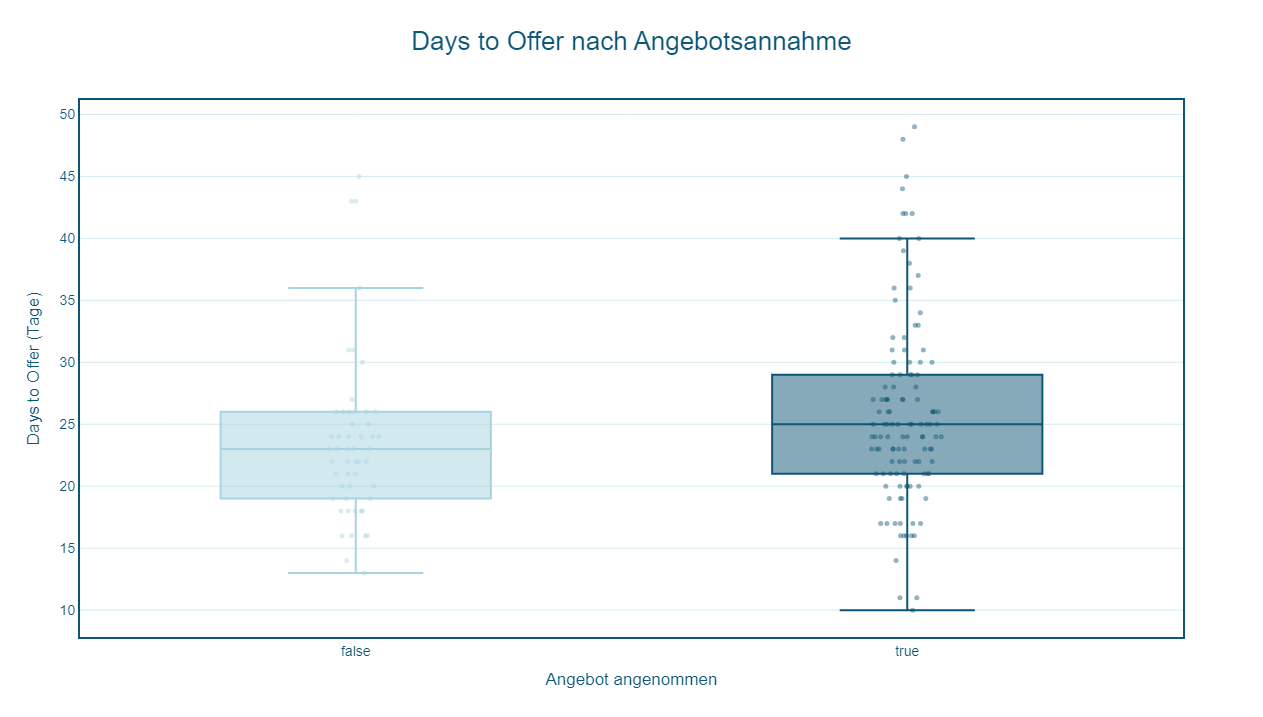

In [95]:
# Boxplot Days to Offer nach Angebotsannahme
# ==========================================================
#
# Ziel:
# Untersuchung, ob sich die Dauer bis zur
# Angebotsabgabe zwischen angenommenen und
# abgelehnten Angeboten unterscheidet.


# ----------------------------------------------------------
# 1. Farbschema
# ----------------------------------------------------------

PRIMARY = "#0E5675"
GRID = "#D8EAF0"

OFFER_COLORS = {
    False: "#A8D4E2",
    True: "#0E5675"
}


# ----------------------------------------------------------
# 2. Reihenfolge nach Median bestimmen
# ----------------------------------------------------------

offer_order = (
    offer_analysis
    .groupby("offer_accepted")["days_to_offer"]
    .median()
    .sort_values()
    .index
    .tolist()
)


# ----------------------------------------------------------
# 3. Boxplot erstellen
# ----------------------------------------------------------

fig = px.box(
    offer_analysis,
    x="offer_accepted",
    y="days_to_offer",
    color="offer_accepted",
    points="all",
    category_orders={
        "offer_accepted": offer_order
    },
    color_discrete_map=OFFER_COLORS,
    title="Days to Offer nach Angebotsannahme"
)


# ----------------------------------------------------------
# 4. Einzelwerte formatieren
# ----------------------------------------------------------

fig.update_traces(
    jitter=0.30,
    pointpos=0,
    marker=dict(
        size=5,
        opacity=0.45
    )
)


# ----------------------------------------------------------
# 5. Layout im Farbdesign
# ----------------------------------------------------------

fig.update_layout(
    width=1400,
    height=700,

    plot_bgcolor="white",
    paper_bgcolor="white",

    font=dict(
        family="Arial",
        size=14,
        color=PRIMARY
    ),

    title=dict(
        text="Days to Offer nach Angebotsannahme",
        font=dict(
            size=26,
            color=PRIMARY
        ),
        x=0.5
    ),

    xaxis_title="Angebot angenommen",
    yaxis_title="Days to Offer (Tage)",

    showlegend=False
)


# ----------------------------------------------------------
# 6. Rahmen und Gitternetzlinien ergänzen
# ----------------------------------------------------------

fig.update_xaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True
)

fig.update_yaxes(
    showline=True,
    linewidth=2,
    linecolor=PRIMARY,
    mirror=True,
    gridcolor=GRID
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

Da bei der Generierung der synthetischen Daten kein direkter Zusammenhang zwischen Prozessdauer und Angebotsannahme modelliert wurde, konnten entsprechende Effekte in der obigen kurzen Deskriptivanalyse nicht nachgewiesen werden. Auf eine weitere Hypothesenprüfung wird an dieser Stelle verzichtet.

Dies verdeutlicht die Bedeutung einer **präzisen Definition der Geschäftsfrage** sowie **einer darauf abgestimmten Datengenerierung und Kennzahlenbildung**.

Dennoch möchte ich die bisherigen Ergebnisse noch einmal im Zusammenhang modellieren. Die bisherigen Analysen haben gezeigt, dass die untersuchten Faktoren isoliert betrachtet keinen statistisch signifikanten Einfluss auf die Angebotsannahme besitzen.

Möglicherweise entstehen Zusammenhänge jedoch erst durch das gemeinsame Zusammenspiel mehrerer Variablen. Um diesen kombinierten Einfluss zu untersuchen und gleichzeitig die Erklärungskraft des Modells zu bewerten, wird im nächsten Schritt ein Regressionsmodell eingesetzt, das uns einen Hinweis darauf geben soll: **Liegt wirklich kein Zusammenhang vor – oder haben wir die relevanten Einflussfaktoren einfach nicht in den Daten?**

### 7.4 Modellierung: Multiple lineare Regression

Die bisherigen Hypothesentests untersuchen einzelne Einflussfaktoren jeweils isoliert voneinander. In der Praxis wirken jedoch häufig mehrere Faktoren gleichzeitig auf eine Zielgröße ein. Um den gemeinsamen Einfluss mehrerer Variablen auf die Time to Hire zu analysieren, wird daher zusätzlich ein multiples lineares Regressionsmodell eingesetzt.

Die multiple lineare Regression schätzt den Zusammenhang zwischen einer metrischen Zielvariable und mehreren Einflussfaktoren gleichzeitig. Dadurch kann untersucht werden, welchen Beitrag einzelne Variablen leisten, während die übrigen Faktoren konstant gehalten werden. Darüber hinaus liefert das Modell Informationen darüber, wie gut die untersuchten Einflussgrößen die Unterschiede in der Zielvariable insgesamt erklären können.

Während die vorherigen Hypothesentests lediglich prüfen, ob einzelne Zusammenhänge statistisch nachweisbar sind, ermöglicht die Regression eine ganzheitliche Betrachtung des Recruiting-Prozesses und zeigt, welche Faktoren den stärksten Einfluss auf die Time to Hire ausüben.

Die Regression versucht, einen Zusammenhang zu modellieren. Die Residuen zeigen uns, was das Modell nicht erklären konnte.

#### 7.4.1 Forschungsfrage

Wie gut erklären die verfügbaren Variablen die Prozessdauer überhaupt?

#### 7.4.2 Zielvariable festlegen

Meine Zielvariable ist die Time to Hire: time_to_hire_days

#### 7.4.3 Einflussvariablen auswählen

Meine Einflussvariablen sind:
- Standort: city
- Recruiting Channel: channel_name
- Kandidatenlevel: candidate_level
- Arbeitsmodell: remote_option
- Fachbereiche: department

#### 7.4.4 Datenaufbereitung & Datenumwandlung

In [96]:
# Regressionsdatensatz vorbereiten
# ==========================================================
#
# Ziel:
# Alle Einflussvariablen mit der Time to Hire
# in einer gemeinsamen Tabelle zusammenführen.
#
# Jede Zeile entspricht einer Bewerbung.
#


# ----------------------------------------------------------
# 1. Bewerbung mit Kandidat, Job und Channel verknüpfen
# ----------------------------------------------------------

application_base = (
    fact_candidate_events[
        [
            "application_id",
            "candidate_id",
            "job_id",
            "channel_id"
        ]
    ]
    .drop_duplicates()
)


# ----------------------------------------------------------
# 2. Kandidatenlevel ergänzen
# ----------------------------------------------------------

application_base = (
    application_base
    .merge(
        dim_candidate[
            [
                "candidate_id",
                "candidate_level"
            ]
        ],
        on="candidate_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 3. Jobinformationen ergänzen
# ----------------------------------------------------------

application_base = (
    application_base
    .merge(
        dim_job[
            [
                "job_id",
                "department",
                "remote_option",
                "location_id"
            ]
        ],
        on="job_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 4. Standort ergänzen
# ----------------------------------------------------------

application_base = (
    application_base
    .merge(
        dim_location[
            [
                "location_id",
                "city"
            ]
        ],
        on="location_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 5. Recruiting Channel ergänzen
# ----------------------------------------------------------

application_base = (
    application_base
    .merge(
        dim_recruiting_channel[
            [
                "channel_id",
                "channel_name"
            ]
        ],
        on="channel_id",
        how="left"
    )
)


# ----------------------------------------------------------
# 6. Time to Hire ergänzen
# ----------------------------------------------------------

regression_data = (
    application_base
    .merge(
        time_to_hire[
            [
                "application_id",
                "time_to_hire_days"
            ]
        ],
        on="application_id",
        how="inner"
    )
)


# ----------------------------------------------------------
# 7. Ergebnis prüfen
# ----------------------------------------------------------

regression_data.head()

,application_id,candidate_id,job_id,channel_id,candidate_level,department,remote_option,location_id,city,channel_name,time_to_hire_days
0,A00153,C03749,J0123,CH02,Mid,HR,Hybrid,LOC03,München,Job Board,39
1,A00169,C01358,J0039,CH01,Mid,Finance,Remote,LOC01,Hamburg,LinkedIn,35
2,A00183,C03914,J0124,CH03,Senior,Marketing,Onsite,LOC05,Frankfurt,Referral,60
3,A00308,C00803,J0076,CH01,Mid,Operations,Hybrid,LOC05,Frankfurt,LinkedIn,53
4,A00372,C04380,J0049,CH03,Mid,Data,Remote,LOC03,München,Referral,34


Meine Zielvariable time to Hire ist metrisch, alle anderen Variablen sind kategorial. Da lineare Regression nur mit numerischen Variablen arbeiten kann, werden die kategorialen Merkmale in sogenannte Dummy-Variablen umgewandelt.

In [97]:
# Dummy-Variablen erzeugen
# ==========================================================
#
# Ziel:
# Kategoriale Variablen für die lineare Regression
# in numerische Dummy-Variablen umwandeln.
#
# Beispiel:
# city = Hamburg, München, Frankfurt
#
# wird zu:
# city_Hamburg
# city_München
#
# Eine Kategorie wird jeweils automatisch
# als Referenzkategorie entfernt.


# ----------------------------------------------------------
# 1. Relevante Variablen auswählen
# ----------------------------------------------------------

regression_model_data = regression_data[
    [
        "time_to_hire_days",
        "city",
        "channel_name",
        "candidate_level",
        "remote_option",
        "department"
    ]
]


# ----------------------------------------------------------
# 2. Dummy-Variablen erzeugen
# ----------------------------------------------------------

regression_model_data = pd.get_dummies(
    regression_model_data,
    columns=[
        "city",
        "channel_name",
        "candidate_level",
        "remote_option",
        "department"
    ],
    drop_first=True
)


# ----------------------------------------------------------
# 3. Ergebnis prüfen
# ----------------------------------------------------------

regression_model_data.head()

,time_to_hire_days,city_Frankfurt,city_Hamburg,city_Köln,city_München,channel_name_Job Board,channel_name_LinkedIn,channel_name_Recruiting Agency,channel_name_Referral,candidate_level_Mid,candidate_level_Senior,remote_option_Onsite,remote_option_Remote,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,39,False,False,False,True,True,False,False,False,True,False,False,False,False,True,False,False,False,False
1,35,False,True,False,False,False,True,False,False,True,False,False,True,True,False,False,False,False,False
2,60,True,False,False,False,False,False,False,True,False,True,True,False,False,False,False,True,False,False
3,53,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False
4,34,False,False,False,True,False,False,False,True,True,False,False,True,False,False,False,False,False,False


In [98]:
# Regressionsmodell-Infos
regression_model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   time_to_hire_days               110 non-null    int64
 1   city_Frankfurt                  110 non-null    bool 
 2   city_Hamburg                    110 non-null    bool 
 3   city_Köln                       110 non-null    bool 
 4   city_München                    110 non-null    bool 
 5   channel_name_Job Board          110 non-null    bool 
 6   channel_name_LinkedIn           110 non-null    bool 
 7   channel_name_Recruiting Agency  110 non-null    bool 
 8   channel_name_Referral           110 non-null    bool 
 9   candidate_level_Mid             110 non-null    bool 
 10  candidate_level_Senior          110 non-null    bool 
 11  remote_option_Onsite            110 non-null    bool 
 12  remote_option_Remote            110 non-null    bool 
 13  department_Finan

Die ursprünglichen Einflussvariablen lagen als kategoriale Merkmale vor und konnten daher nicht direkt in das Regressionsmodell aufgenommen werden. Mithilfe der One-Hot-Codierung wurden diese Variablen in Dummy-Variablen umgewandelt. Dabei dient jeweils eine Kategorie als Referenzgruppe, gegen die die übrigen Kategorien im Modell verglichen werden.

#### 7.4.5 Regressionsmodell schätzen

In [99]:
# Multiple lineare Regression
# ==========================================================

import statsmodels.api as sm

# ----------------------------------------------------------
# 1. Zielvariable definieren
# ----------------------------------------------------------

y = regression_model_data["time_to_hire_days"]


# ----------------------------------------------------------
# 2. Einflussvariablen definieren
# ----------------------------------------------------------

X = regression_model_data.drop(
    columns=["time_to_hire_days"]
)


# ----------------------------------------------------------
# 3. Boolean-Dummies in 0/1 umwandeln
# ----------------------------------------------------------

X = X.astype(int)


# ----------------------------------------------------------
# 4. Konstante ergänzen
# ----------------------------------------------------------

X = sm.add_constant(X)


# ----------------------------------------------------------
# 5. Regressionsmodell schätzen
# ----------------------------------------------------------

model = sm.OLS(y, X).fit()


# ----------------------------------------------------------
# 6. Ergebnisse anzeigen
# ----------------------------------------------------------

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      time_to_hire_days   R-squared:                       0.698
Model:                            OLS   Adj. R-squared:                  0.639
Method:                 Least Squares   F-statistic:                     11.70
Date:                Thu, 02 Jul 2026   Prob (F-statistic):           1.23e-16
Time:                        09:25:24   Log-Likelihood:                -362.09
No. Observations:                 110   AIC:                             762.2
Df Residuals:                      91   BIC:                             813.5
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#### 7.4.6 Modellgüte (R²) & Koeffizienten

Zur Bewertung des Regressionsmodells werden verschiedene Kennzahlen betrachtet.

**R² (Bestimmtheitsmaß)**
Das R² beträgt 0,698. Damit können rund 69,8% der Unterschiede in der Time to Hire durch die im Modell enthaltenen Variablen erklärt werden.

**Adjustiertes R²**
Das adjustierte R² beträgt 0,639. Da es die Anzahl der verwendeten Einflussvariablen berücksichtigt, liefert es eine realistischere Einschätzung der Modellgüte. Auch hier zeigt sich eine vergleichsweise hohe Erklärungskraft.

**F-Statistik und Signifikanz des Gesamtmodells**
Die F-Statistik beträgt 11,70 bei einem p-Wert kleiner als 0,001.<br>
Damit ist das Regressionsmodell insgesamt statistisch signifikant. Die betrachteten Einflussvariablen leisten gemeinsam einen signifikanten Beitrag zur Erklärung der Time to Hire.

**Koeffizienten (coef)**
Die Regressionskoeffizienten geben an, um wie viele Tage sich die Time to Hire im Vergleich zur jeweiligen Referenzkategorie verändert. Positive Werte erhöhen die erwartete Time to Hire, negative Werte verkürzen sie.

**p-Wert (P>|t|)**
Der p-Wert zeigt, ob ein Einfluss statistisch signifikant ist.
- p < 0,05 → signifikanter Einfluss
- p ≥ 0,05 → kein statistisch signifikanter Einfluss

Im vorliegenden Modell weist ausschließlich die Variable **city_Frankfurt** einen statistisch signifikanten Einfluss auf die Time to Hire auf.

#### 7.4.7 Interpretation der Regressionsergebnisse

Die multiple lineare Regression wurde eingesetzt, um den gemeinsamen Einfluss von Standort, Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich auf die Time to Hire zu untersuchen.

Das Modell erklärt rund 70 % der beobachteten Unterschiede in der Time to Hire (R² = 0,698) und ist insgesamt statistisch signifikant (p < 0,001). 

Bei der Betrachtung der einzelnen Einflussgrößen zeigt sich jedoch, dass **lediglich der Standort Frankfurt** einen statistisch signifikanten Einfluss auf die Prozessdauer besitzt (p < 0,001).

Der geschätzte Koeffizient von 22,43 bedeutet, dass Bewerbungen am Standort Frankfurt im Durchschnitt etwa 22 Tage länger bis zur Vertragsunterzeichnung benötigen als Bewerbungen der jeweiligen Referenzkategorie.

Für Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich konnten dagegen keine statistisch signifikanten Effekte nachgewiesen werden.

Die Ergebnisse bestätigen damit die zuvor durchgeführten Hypothesentests. Der wesentliche Erklärungsbeitrag des Modells wird durch den bereits bekannten Standorteffekt verursacht.

Die untersuchten Variablen außerhalb des Standorteffekts liefern nur einen geringen zusätzlichen Erklärungsbeitrag. Dies deutet darauf hin, dass weitere relevante Einflussfaktoren auf die Time to Hire im vorliegenden Datensatz nicht enthalten sind oder bei der Datengenerierung nicht modelliert wurden.

Denn wie im Kapitel 7.3. bereits festgestellt: Nicht jede statistisch saubere Analyse beantwortet automatisch die Business-Frage. Entscheidend ist, ob die richtigen Variablen erhoben und modelliert wurden.

#### 7.4.8 Prüfung der Modellannahmen

Die Voraussetzungen der linearen Regression wurden überprüft. Der Durbin-Watson-Wert von 1,98 deutet auf eine Unabhängigkeit der Residuen hin.

Hinweise auf kritische Multikollinearität zwischen den Einflussvariablen ergaben sich nicht (Condition Number = 10,8).

Die Residuen weichen geringfügig von einer Normalverteilung ab. Aufgrund der Stichprobengröße von 110 Beobachtungen wird dies jedoch als unkritisch bewertet.

Da ausschließlich kategoriale Einflussvariablen in Form von Dummy-Variablen verwendet wurden, wurde auf eine gesonderte Prüfung der Linearität verzichtet.
   

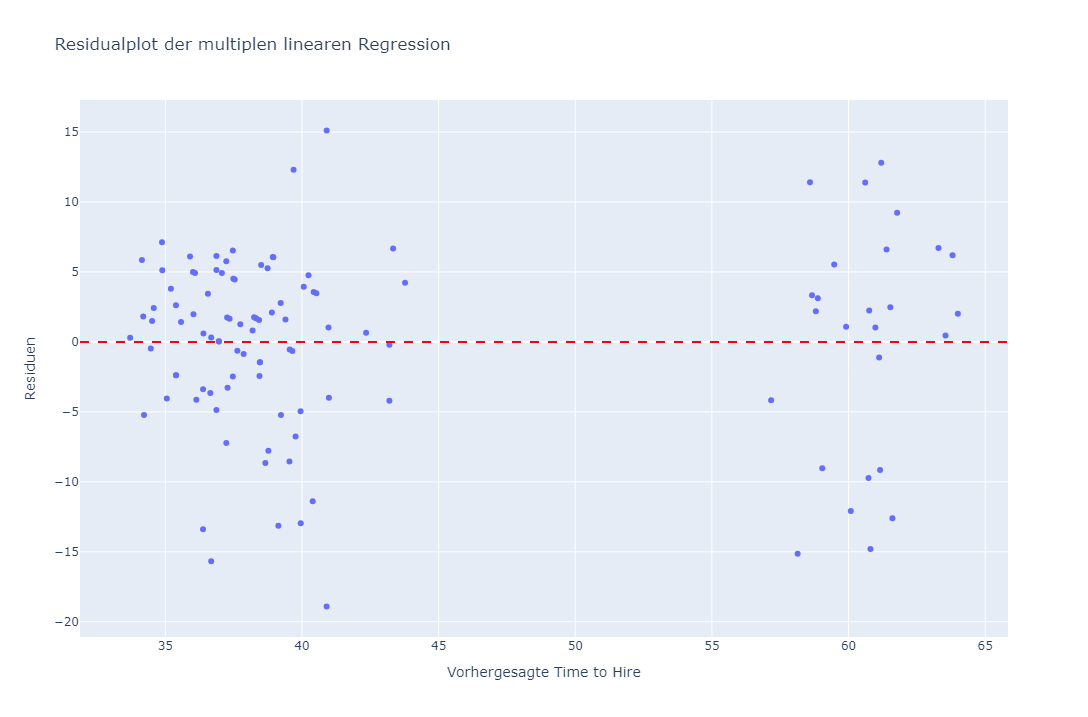

In [100]:
# Residualplot
# ==========================================================
#
# Ziel:
# Prüfung der Homoskedastizität und Identifikation
# möglicher Muster in den Residuen.
#
# Idealfall:
# - zufällige Streuung um die Nulllinie
# - keine Trichterform
# - keine erkennbaren Muster
#

import plotly.express as px

# ----------------------------------------------------------
# 1. Vorhersagewerte berechnen
# ----------------------------------------------------------

predictions = model.fittedvalues


# ----------------------------------------------------------
# 2. Residuen berechnen
# ----------------------------------------------------------

residuals = model.resid


# ----------------------------------------------------------
# 3. DataFrame für Plot erstellen
# ----------------------------------------------------------

residual_df = pd.DataFrame({
    "Predicted": predictions,
    "Residuals": residuals
})


# ----------------------------------------------------------
# 4. Residualplot erstellen
# ----------------------------------------------------------

fig = px.scatter(
    residual_df,
    x="Predicted",
    y="Residuals",
    title="Residualplot der multiplen linearen Regression"
)


# ----------------------------------------------------------
# 5. Nulllinie ergänzen
# ----------------------------------------------------------

fig.add_hline(
    y=0,
    line_dash="dash",
    line_color="red"
)


# ----------------------------------------------------------
# 6. Layout anpassen
# ----------------------------------------------------------

fig.update_layout(
    width=1200,
    height=700,
    xaxis_title="Vorhergesagte Time to Hire",
    yaxis_title="Residuen"
)


# ----------------------------------------------------------
# 7. Diagramm anzeigen
# ----------------------------------------------------------

fig.show()

**Prüfung der Homoskedastizität/ Streuung der Residuen**

Zur Beurteilung der Modellannahmen wurde ein Residualplot erstellt.

Die Residuen streuen weitgehend zufällig um die Nulllinie. Es sind keine systematischen Muster oder ausgeprägten Trichterstrukturen erkennbar. Die Streuung der Residuen erscheint über den gesamten Bereich der vorhergesagten Werte annähernd konstant.

Damit liegen keine wesentlichen Hinweise auf eine Verletzung der Homoskedastizitätsannahme vor. Die Ergebnisse der linearen Regression können daher als grundsätzlich belastbar angesehen werden.

### 7.5 Regression ohne Frankfurt

Das Regressionsmodell zeigt, dass insbesondere der Standort Frankfurt einen signifikanten Einfluss auf die Time to Hire besitzt. Eine Reduzierung der Prozessdauer an diesem Standort könnte daher zu einer Verringerung der durchschnittlichen Time to Hire im Gesamtdatensatz beitragen.

Gleichzeitig besteht die Vermutung, dass der starke Standorteffekt einen Großteil der Modellgüte erklärt. Um die Erklärungskraft der übrigen untersuchten Variablen isoliert zu betrachten, wird im nächsten Schritt ein weiteres Regressionsmodell ohne den Standort Frankfurt berechnet.

Ziel dieser Analyse ist es zu prüfen, welchen Beitrag Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich zur Erklärung der Time to Hire leisten, wenn der dominierende Standorteffekt entfernt wird. Eine deutlich sinkende Modellgüte würde darauf hindeuten, dass weitere relevante Einflussfaktoren im Datensatz nicht enthalten oder bei der Datengenerierung nicht modelliert wurden.

In [101]:
# Regressionsdatensatz ohne Standort Frankfurt vorbereiten
# ==========================================================
#
# Ziel:
# Prüfung, wie gut die übrigen Einflussfaktoren
# die Time to Hire erklären, wenn der dominante
# Standorteffekt Frankfurt entfernt wird.


# ----------------------------------------------------------
# 1. Frankfurt aus dem ursprünglichen Regressionsdatensatz entfernen
# ----------------------------------------------------------

regression_data_without_frankfurt = (
    regression_data[
        regression_data["city"] != "Frankfurt"
    ]
    .copy()
)


# ----------------------------------------------------------
# 2. Relevante Variablen auswählen
# ----------------------------------------------------------

regression_model_data_without_frankfurt = regression_data_without_frankfurt[
    [
        "time_to_hire_days",
        "city",
        "channel_name",
        "candidate_level",
        "remote_option",
        "department"
    ]
]


# ----------------------------------------------------------
# 3. Kategoriale Variablen in Dummy-Variablen umwandeln
# ----------------------------------------------------------

regression_model_data_without_frankfurt = pd.get_dummies(
    regression_model_data_without_frankfurt,
    columns=[
        "city",
        "channel_name",
        "candidate_level",
        "remote_option",
        "department"
    ],
    drop_first=True
)


# ----------------------------------------------------------
# 4. Ergebnis prüfen
# ----------------------------------------------------------

display(
    regression_model_data_without_frankfurt.head()
)

regression_model_data_without_frankfurt.info()

,time_to_hire_days,city_Hamburg,city_Köln,city_München,channel_name_Job Board,channel_name_LinkedIn,channel_name_Recruiting Agency,channel_name_Referral,candidate_level_Mid,candidate_level_Senior,remote_option_Onsite,remote_option_Remote,department_Finance,department_HR,department_IT,department_Marketing,department_Operations,department_Sales
0,39,False,False,True,True,False,False,False,True,False,False,False,False,True,False,False,False,False
1,35,True,False,False,False,True,False,False,True,False,False,True,True,False,False,False,False,False
4,34,False,False,True,False,False,False,True,True,False,False,True,False,False,False,False,False,False
6,34,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
7,40,True,False,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False


<class 'pandas.DataFrame'>
Index: 84 entries, 0 to 108
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   time_to_hire_days               84 non-null     int64
 1   city_Hamburg                    84 non-null     bool 
 2   city_Köln                       84 non-null     bool 
 3   city_München                    84 non-null     bool 
 4   channel_name_Job Board          84 non-null     bool 
 5   channel_name_LinkedIn           84 non-null     bool 
 6   channel_name_Recruiting Agency  84 non-null     bool 
 7   channel_name_Referral           84 non-null     bool 
 8   candidate_level_Mid             84 non-null     bool 
 9   candidate_level_Senior          84 non-null     bool 
 10  remote_option_Onsite            84 non-null     bool 
 11  remote_option_Remote            84 non-null     bool 
 12  department_Finance              84 non-null     bool 
 13  department_HR         

In [102]:
# Multiple lineare Regression ohne Standort Frankfurt
# ==========================================================
#
# Ziel:
# Untersuchung, wie gut die verbleibenden
# Einflussfaktoren die Time to Hire erklären,
# wenn der dominante Standorteffekt Frankfurt
# aus dem Datensatz entfernt wird.
#


import statsmodels.api as sm


# ----------------------------------------------------------
# 1. Zielvariable definieren
# ----------------------------------------------------------

y = regression_model_data_without_frankfurt[
    "time_to_hire_days"
]


# ----------------------------------------------------------
# 2. Einflussvariablen definieren
# ----------------------------------------------------------

X = regression_model_data_without_frankfurt.drop(
    columns=["time_to_hire_days"]
)


# ----------------------------------------------------------
# 3. Boolean-Dummies in numerische Werte umwandeln
# ----------------------------------------------------------

X = X.astype(int)


# ----------------------------------------------------------
# 4. Konstante ergänzen
# ----------------------------------------------------------

X = sm.add_constant(X)


# ----------------------------------------------------------
# 5. Regressionsmodell schätzen
# ----------------------------------------------------------

model_without_frankfurt = sm.OLS(
    y,
    X
).fit()


# ----------------------------------------------------------
# 6. Ergebnisse anzeigen
# ----------------------------------------------------------

print(model_without_frankfurt.summary())

                            OLS Regression Results                            
Dep. Variable:      time_to_hire_days   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                 -0.114
Method:                 Least Squares   F-statistic:                    0.5017
Date:                Thu, 02 Jul 2026   Prob (F-statistic):              0.943
Time:                        09:25:25   Log-Likelihood:                -266.92
No. Observations:                  84   AIC:                             569.8
Df Residuals:                      66   BIC:                             613.6
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

**Interpretation**

Im ersten Modell wurden **knapp 70%** der Unterschiede in der Time to Hire erklärt.

Nachdem Frankfurt entfernt wurde, können die verbleibenden Faktoren nur noch **etwa 11%** der Varianz erklären. Anders formuliert:

**- 89% der Unterschiede in der Time to Hire bleiben unerklärt.**

**- Die bisher untersuchten Faktoren besitzen praktisch keine Erklärungskraft mehr.**

**- Das Gesamtmodell ist nicht signifikant. Prob(F-statistic) = 0,943**

## 8. Gesamtfazit

Ziel dieser Arbeit war es, anhand eines synthetischen Recruiting-Datensatzes zu untersuchen, welche Faktoren die Prozessdauer (Time to Hire) und die Angebotsannahme (Offer Acceptance Rate) beeinflussen. Darüber hinaus sollte aufgezeigt werden, wie datenbasierte Analysen Unternehmen dabei unterstützen können, Recruiting-Prozesse effizienter zu gestalten, Kosten zu reduzieren und die Candidate Experience zu verbessern.

Im ersten Schritt wurde der Datensatz explorativ analysiert. Dabei wurden zentrale Kennzahlen des Recruiting-Funnels untersucht, Prozesslaufzeiten berechnet sowie Unterschiede zwischen Standorten, Recruiting Channels, Kandidatenleveln, Arbeitsmodellen und Fachbereichen betrachtet. Die deskriptiven Analysen zeigten teilweise erkennbare Unterschiede zwischen einzelnen Gruppen und lieferten erste Hypothesen über mögliche Einflussfaktoren.

Anschließend wurden diese Beobachtungen mithilfe statistischer Hypothesentests überprüft. Für die Time to Hire konnte lediglich der Standort einen statistisch signifikanten Einfluss nachweisen. Insbesondere der Standort Frankfurt wies deutlich längere Prozesslaufzeiten auf als die übrigen Standorte. Für Recruiting Channel, Kandidatenlevel, Arbeitsmodell und Fachbereich konnten keine signifikanten Unterschiede festgestellt werden.

Auch bei der Analyse der Offer Acceptance Rate zeigte sich kein statistisch signifikanter Zusammenhang zwischen den untersuchten Faktoren und der Wahrscheinlichkeit einer Angebotsannahme. Obwohl die Offer Acceptance Rate mit rund 70% grundsätzlich hoch war, konnten die Ursachen für Angebotsablehnungen mit den vorhandenen Variablen nicht erklärt werden.

Im Verlauf der Analyse wurde deutlich, dass die ursprünglich betrachtete Kennzahl Time to Hire die eigentliche Business-Frage nur eingeschränkt beantwortet. Die Entscheidung eines Kandidaten zur Annahme oder Ablehnung eines Angebots erfolgt bereits vor Vertragsunterzeichnung. Für die Untersuchung möglicher Zusammenhänge zwischen Prozessgeschwindigkeit und Angebotsannahme wäre daher die Kennzahl Time to Offer fachlich besser geeignet gewesen. Diese Erkenntnis stellte einen wichtigen methodischen Lernschritt innerhalb des Projekts dar.

Zur abschließenden Bewertung der Einflussfaktoren wurde ein multiples lineares Regressionsmodell auf die Time to Hire erstellt. Das erste Modell erreichte mit einem Bestimmtheitsmaß von R² = 0,698 zunächst eine hohe Erklärungskraft. Die Analyse der Regressionskoeffizienten zeigte jedoch, dass dieser Effekt nahezu ausschließlich auf den Standort Frankfurt zurückzuführen war.

Um diesen Einfluss genauer zu untersuchen, wurde ein zweites Regressionsmodell ohne den Standort Frankfurt berechnet. Das Bestimmtheitsmaß sank dabei auf R² = 0,114. Gleichzeitig verlor das Modell seine statistische Signifikanz. Die verbleibenden Variablen konnten somit nur noch etwa 11% der Unterschiede in der Time to Hire erklären.

Dieses Ergebnis legt nahe, dass die wesentlichen Einflussfaktoren auf die Prozessdauer im vorliegenden Datensatz nicht enthalten sind oder bei der Generierung der synthetischen Daten nicht modelliert wurden. Mögliche zusätzliche Einflussgrößen wären beispielsweise die Anzahl der Interviewrunden, die Verfügbarkeit von Hiring Managern, interne Freigabeprozesse, die Priorität einer Stelle oder die Auslastung der Recruiting-Organisation.

Insgesamt zeigt die Arbeit, dass Data Analytics nicht nur darin besteht, Zusammenhänge nachzuweisen, sondern auch darin, die Grenzen eines Datensatzes zu erkennen. Die Analyse konnte bestätigen, dass die untersuchten Variablen nur einen begrenzten Teil der Prozessdauer erklären. Gleichzeitig wurde deutlich, wie entscheidend eine präzise Definition der Business-Frage, eine darauf abgestimmte Kennzahlenbildung sowie eine geeignete Modellierung der Daten für belastbare Analysen sind.

Die Arbeit liefert damit nicht nur Erkenntnisse über den Recruiting-Prozess selbst, sondern auch wichtige methodische Erkenntnisse für zukünftige Analytics-Projekte. Sie verdeutlicht, dass aussagekräftige Analysen bereits bei der Formulierung der Fragestellung und der Gestaltung des Datenmodells beginnen. Gerade diese Erkenntnis stellt den wichtigsten Mehrwert des Projekts dar.

## 9. Persönliche Learnings aus dem Projekt

**Fachliche Learnings**
- Der Business Case und die zugrunde liegende Fragestellung sollten zu Projektbeginn so klar definiert sein, dass sie jederzeit präsent sind. Nur wenn die Geschäftsfrage vollständig verstanden ist, können die passenden Kennzahlen, Analysen und statistischen Verfahren ausgewählt werden.
- Die Definition der Kennzahlen ist entscheidend. Im Projekt wurde deutlich, dass die ursprünglich verwendete Kennzahl Time to Hire die eigentliche Fragestellung nur teilweise beantwortet. Für die Untersuchung des Zusammenhangs zwischen Prozessgeschwindigkeit und Angebotsannahme wäre die Kennzahl Days to Offer besser geeignet gewesen.
- Bei der Generierung synthetischer Daten sollten gewünschte Zusammenhänge und Effekte bereits im Vorfeld explizit definiert werden. Werden bestimmte Einflussfaktoren nicht simuliert, können diese später auch statistisch nicht nachgewiesen werden.
- Die statistische Vorgehensweise hat sich als sinnvoller roter Faden etabliert: zunächst univariate Analysen, anschließend bivariate Zusammenhänge, darauf aufbauend Hypothesentests und schließlich Modellbildung. Diese Struktur hilft dabei, Daten systematisch zu verstehen und Ergebnisse nachvollziehbar herzuleiten.
- Jedoch werde ich die Reihenfolge zukünftig tauschen: Nach der Datenaufbereitung wird ein erstes Regressionsmodell erstellt, um zu prüfen, ob meine zu untersuchenden Faktoren überhaupt einen signifikanten Einfluss auf meine Zielvariablen haben.
- Nicht signifikante Ergebnisse sind ebenfalls wertvolle Erkenntnisse. Sie zeigen entweder, dass kein Zusammenhang besteht oder dass die relevanten Einflussfaktoren im Datensatz nicht enthalten sind.
- Eine Analyse beantwortet nicht nur Fragen, sondern kann auch dazu führen, dass die ursprüngliche Fragestellung präzisiert oder neu formuliert werden muss. Dies ist kein Fehler, sondern ein natürlicher Bestandteil des Analyseprozesses.

**Technische Learnings**
- Plotly Express eignet sich besonders für interaktive Visualisierungen und explorative Analysen. Seaborn bietet dagegen häufig die ansprechendere Standardoptik für statische Berichte und wissenschaftliche Dokumentationen.
- Wiederkehrende Diagramme, Tabellen und Berechnungen sollten künftig stärker über Funktionen automatisiert werden. Dies reduziert Redundanzen, erhöht die Wiederverwendbarkeit des Codes und vereinfacht spätere Anpassungen.
- Ein einheitliches Farb- und Formschema sollte bereits zu Beginn eines Projekts definiert werden. Dadurch entsteht ein konsistentes Erscheinungsbild über alle Diagramme und Auswertungen hinweg.
- Jupyter Notebook hat sich als sehr geeignetes Werkzeug erwiesen, um Code, Analysen, Visualisierungen und Dokumentation in einer gemeinsamen Arbeitsumgebung zu verbinden.

**Projekt- und Datenmanagement**
- Die Anzahl an Tabellen, Variablen, Kennzahlen und Zwischenergebnissen wächst in einem Analyseprojekt sehr schnell. Für zukünftige Projekte sollte deshalb von Beginn an ein separates Übersichtsnotebook oder Datenlexikon geführt werden.
- Besonders hilfreich wäre eine zentrale Projektdokumentation mit:
    - Business Case und Forschungsfragen
    - Tabellenübersicht
    - Variablenbeschreibung
    - Definitionen der Kennzahlen
    - Dokumentation der simulierten Effekte und Annahmen
    - aktuellem Projektstatus
- Je komplexer ein Projekt wird, desto wichtiger wird ein strukturiertes Vorgehen zur Nachvollziehbarkeit von Entscheidungen und Berechnungen.

**Persönliche Learnings**
- Der größte Erkenntnisgewinn entsteht häufig nicht durch die Anwendung eines bestimmten statistischen Verfahrens & den Zahlen, sondern durch das Verständnis, welche Frage die Daten tatsächlich beantworten können – und welche nicht.
- Python ist für mich kein Selbstzweck, sondern ein Werkzeug zur Beantwortung von Geschäftsfragen.
- Je tiefer das Verständnis für den eigenen Datensatz wird, desto wichtiger wird kritisches Hinterfragen. Aussagen, Ergebnisse und Interpretationen sollten stets mit dem eigenen Verständnis des Datenmodells abgeglichen werden.
- Ein gutes Analyseergebnis bedeutet nicht zwangsläufig, viele signifikante Zusammenhänge zu finden. Ebenso wichtig ist es, Grenzen von Daten, Modellen und Annahmen zu erkennen und transparent zu dokumentieren.
- Dieses Projekt hat mir bestätigt, dass ich nicht Programmiererin werden möchte. Ich möchte verstehen, warum Dinge passieren, welche Auswirkungen sie haben und wie Daten dabei helfen können, bessere Entscheidungen zu treffen.
